In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Global parameters
total_years = 20 # this will be calculated based on study start and end dates
# Adoption model differential eq Parameters
dt = 1#/12  # time step in years (monthly)
time = np.arange(0, total_years, dt)
n = len(time)

In [3]:
#Competition group and building type specific Inputs
# New Construction

#######################
### feature request ###
#######################

# this code reads 30_Construction_Inputs.xlsx
new_construction_inputs_df = pd.read_excel('./030_input/30_Construction_Inputs.xlsx', sheet_name='New_Construction')
demolition_inputs_df = pd.read_excel('./030_input/30_Construction_Inputs.xlsx', sheet_name='Demolition')
renovation_inputs_df = pd.read_excel('./030_input/30_Construction_Inputs.xlsx', sheet_name='Renovation')

#the dataframes renovation_inputs_df demolition_inputs_df new_construction_inputs_df are structured the same with the column competition group and subgroup and the other columns being the building type
# this code will need to be modified to loop through competition groups and building types to get the correct values for each simulation

# Helper function to get the construction/demo/reno value from input dataframes
def get_construction_value(input_df, competition_group, building_type):
    """
    Get the construction/demolition/renovation value for a specific competition group and building type.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        The input dataframe (new_construction_inputs_df, demolition_inputs_df, or renovation_inputs_df)
    competition_group : str
        The competition group (e.g., 'refrigeration', 'whole_home')
    building_type : str
        The building type (e.g., 'multi_family', 'single_family', etc.)
    
    Returns:
    --------
    float
        The value per year for the specified competition group and building type
    """
    try:
        # Filter by competition group
        row = input_df[input_df['competition_group'] == competition_group]
        if row.empty:
            return 0.0
        # Get the value from the building_type column
        if building_type in row.columns:
            value = row[building_type].values[0]
            return float(value) if pd.notna(value) else 0.0
        else:
            return 0.0
    except Exception as e:
        print(f"Warning: Could not retrieve value for {competition_group}/{building_type}: {e}")
        return 0.0

In [4]:
df = pd.read_pickle("./030_input/df_yrs_all.pkl")

#######################
### feature request ###
#######################
# Create competition allocation based on PCT test for efficient measures


# Define a function to extract the size
def extract_eff_level(description):
    if 'baseline' in description:
        return 'baseline'
    elif 'existing' in description:
        return 'existing'
    elif 'efficient' in description:
        return 'efficient'
    elif 'top10' in description:
        return 'top10' #this change is made because top10 is considered efficient in refrigeration for now just holding to get number right
    else:
        return 'Unknown'

# Apply the function to the 'Description' column to create the new 'Size' column
df['efficiency_level'] = df['condition'].apply(extract_eff_level)
df

,condition,competition_group,subgroup,electric_utility,gas_utility,climate_zone,building_type,count,measure_life_(yrs),measure_name,...,SCT_cost,SCT_benefit,SCT_BCR,RIM_cost,RIM_benefit,RIM_BCR,PCT_cost,PCT_benefit,PCT_BCR,efficiency_level
0,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,1,single_family,5000.0,10,furnace_oil_existing_residential_to_furnace_oi...,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
1,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,1,single_family,5000.0,10,furnace_oil_baseline_residential_to_furnace_oi...,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
2,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,1,single_family,5000.0,10,furnace_oil_baseline_residential_to_furnace_oi...,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
3,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,1,single_family,5000.0,10,furnace_oil_baseline_residential_to_furnace_oi...,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
4,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_2,1,single_family,10000.0,10,furnace_oil_existing_residential_to_furnace_oi...,...,1680.0,3645.190210,2.169756,1172.716654,4138.658036,3.529120,700.0,4691.160799,6.701658,efficient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,1,multifamily_li,0.0,10,refrigerator_electricity_top10_residential_ref...,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
260,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,1,multifamily_li,0.0,10,refrigerator_electricity_top10_residential_ref...,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
261,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_1,1,multifamily_li,0.0,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing
262,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_2,1,multifamily_li,0.0,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing


In [5]:
# drop all conditions with furnace in them
df = df[~df['condition'].str.contains('furnace', na=False)]
# change name of column condition to condition_name
df.rename(columns={'condition': 'condition_name'}, inplace=True)

C:\Users\AndrewJ.Johnson\AppData\Local\Temp\ipykernel_66764\1254462694.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'condition': 'condition_name'}, inplace=True)


In [6]:
df

,condition_name,competition_group,subgroup,electric_utility,gas_utility,climate_zone,building_type,count,measure_life_(yrs),measure_name,...,SCT_cost,SCT_benefit,SCT_BCR,RIM_cost,RIM_benefit,RIM_BCR,PCT_cost,PCT_benefit,PCT_BCR,efficiency_level
36,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,1,single_family,25000.0,10,refrigerator_electricity_efficient_residential...,...,3120.0,2969.004063,0.951604,3310.055249,2984.786640,0.901733,1300.0,5126.097795,3.943152,efficient
37,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,1,single_family,25000.0,10,refrigerator_electricity_efficient_residential...,...,1080.0,1901.386864,1.760543,1510.749803,1610.219983,1.065842,450.0,2717.225692,6.038279,efficient
38,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,1,single_family,25000.0,10,refrigerator_electricity_efficient_residential...,...,1080.0,1901.386864,1.760543,1510.749803,1610.219983,1.065842,450.0,2717.225692,6.038279,efficient
39,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,1,single_family,25000.0,10,refrigerator_electricity_efficient_residential...,...,1080.0,1901.386864,1.760543,1510.749803,1610.219983,1.065842,450.0,2717.225692,6.038279,efficient
40,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_2,1,single_family,50000.0,10,refrigerator_electricity_efficient_residential...,...,3120.0,2977.534266,0.954338,3310.055249,2984.786640,0.901733,1300.0,5134.627998,3.949714,efficient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,1,multifamily_li,0.0,10,refrigerator_electricity_top10_residential_ref...,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
260,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,1,multifamily_li,0.0,10,refrigerator_electricity_top10_residential_ref...,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
261,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_1,1,multifamily_li,0.0,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing
262,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_2,1,multifamily_li,0.0,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing


In [7]:
# Parameters
ret_er_retirement_rate = 0.50
ret_add_on_retirement_rate = 0.00

In [8]:
def baseline_eq(Below_Baseline, Baseline, Efficient, Top10, m, retirement_rate, df_filtered=None, market='ROB'):
    Tech_Value = 0 # this is 0 percent as that is the definition of baseline potential
    Retirement_Flow = m * retirement_rate * dt #(m is the size of the stock)
    Top10_Flow  = Retirement_Flow * Tech_Value
    Efficient_Adoption_Flow = Retirement_Flow * (Tech_Value)
    Remaining_Flow = Retirement_Flow - Efficient_Adoption_Flow - Top10_Flow
    Baseline_Adoption_Flow = Remaining_Flow # should be zero as this is technical but left in for future
    Below_Baseline_Adoption_Flow = 0.0
    
    dEfficient_dt = Efficient_Adoption_Flow - (Efficient * retirement_rate* dt)
    dBaseline_dt = Baseline_Adoption_Flow - (Baseline * retirement_rate* dt)
    dBelow_Baseline_dt = Below_Baseline_Adoption_Flow - (Below_Baseline * retirement_rate* dt)
    dTop10_dt = Top10_Flow - (Top10 * retirement_rate* dt)
    
    return dBelow_Baseline_dt, dBaseline_dt, dEfficient_dt, dTop10_dt
    # the alternative for tech is code 
    # we care about savings that are generated so when moving to measure we already have the baseline built in
    

In [9]:
def tech_eq(Below_Baseline, Baseline, Efficient, Top10, m, retirement_rate, df_filtered=None, market='ROB'):
    Tech_Value = 1 # this is 100 percent as that is the definition of technical potential
    Retirement_Flow = m * retirement_rate * dt #(m is the size of the stock)
    Top10_Flow  = Retirement_Flow * Tech_Value
    Efficient_Adoption_Flow = Retirement_Flow * (1 - Tech_Value)
    Remaining_Flow = Retirement_Flow - Efficient_Adoption_Flow - Top10_Flow
    Baseline_Adoption_Flow = Remaining_Flow # should be zero as this is technical but left in for future
    Below_Baseline_Adoption_Flow = 0.0
    
    # section 2 here is the adopted calculated values from above minus the retirements from the data
    dEfficient_dt = Efficient_Adoption_Flow - (Efficient * retirement_rate* dt)
    dBaseline_dt = Baseline_Adoption_Flow - (Baseline * retirement_rate* dt)
    dBelow_Baseline_dt = Below_Baseline_Adoption_Flow - (Below_Baseline * retirement_rate* dt)
    dTop10_dt = Top10_Flow - (Top10 * retirement_rate* dt)
    
    return dBelow_Baseline_dt, dBaseline_dt, dEfficient_dt, dTop10_dt
    # the alternative for tech is code 
    # we care about savings that are generated so when moving to measure we already have the baseline built in

In [10]:
def competition_eq(Below_Baseline, Baseline, Efficient, Top10, m, retirement_rate, df_filtered=None, market='ROB'):
    # Calculate Tech_Value based on PCT_BCR from top10 and efficient rows
    # Filter by market type (ROB for replace-on-burnout, RET_ER for early retirement, NC for new construction, RENO for renovation)
    if df_filtered is not None and len(df_filtered) > 0:
        # Filter df_filtered by the specified market
        df_market = df_filtered[df_filtered['market'] == market] if 'market' in df_filtered.columns else df_filtered
        
        top10_bcr = df_market.loc[df_market['efficiency_level'] == 'top10', 'PCT_BCR'].sum()
        efficient_bcr = df_market.loc[df_market['efficiency_level'] == 'efficient', 'PCT_BCR'].sum()
        
        # Calculate Tech_Value: proportion of top10 BCR relative to total (top10 + efficient)
        # prepare for both being negative
        total_bcr = top10_bcr + efficient_bcr
        if total_bcr > 0:
            Tech_Value = top10_bcr / total_bcr
        else:
            Tech_Value = 0.0
    else:
        Tech_Value = 0.0
    
    Retirement_Flow = m * retirement_rate * dt #(m is the size of the stock)
    Top10_Flow  = Retirement_Flow * Tech_Value
    Efficient_Adoption_Flow = Retirement_Flow * (1 - Tech_Value)
    Remaining_Flow = Retirement_Flow - Efficient_Adoption_Flow - Top10_Flow
    Baseline_Adoption_Flow = Remaining_Flow # should be zero as this is technical but left in for future
    Below_Baseline_Adoption_Flow = 0.0
    
    dEfficient_dt = Efficient_Adoption_Flow - (Efficient * retirement_rate* dt)
    dBaseline_dt = Baseline_Adoption_Flow - (Baseline * retirement_rate* dt)
    dBelow_Baseline_dt = Below_Baseline_Adoption_Flow - (Below_Baseline * retirement_rate* dt)
    dTop10_dt = Top10_Flow - (Top10 * retirement_rate* dt)
    
    return dBelow_Baseline_dt, dBaseline_dt, dEfficient_dt, dTop10_dt

In [11]:
# def net_benefits_eq(Below_Baseline, Baseline, Efficient, Top10, m, retirement_rate, df_filtered=None, market='ROB'):
#     # Calculate Tech_Value based on PCT_BCR from top10 and efficient rows
#     # Filter by market type (ROB for replace-on-burnout, RET_ER for early retirement, NC for new construction, RENO for renovation)
#     if df_filtered is not None and len(df_filtered) > 0:
#         # Filter df_filtered by the specified market
#         df_market = df_filtered[df_filtered['market'] == market] if 'market' in df_filtered.columns else df_filtered
        
#         #net benefits greater than zero
#         top10_bcr = df_market.loc[df_market['efficiency_level'] == 'top10', 'PCT_BCR'].sum()
#         efficient_bcr = df_market.loc[df_market['efficiency_level'] == 'efficient', 'PCT_BCR'].sum()
        
#         # Calculate Tech_Value: proportion of top10 BCR relative to total (top10 + efficient)
#         # prepare for both being negative
#         total_bcr = top10_bcr + efficient_bcr
#         if total_bcr > 0:
#             Tech_Value = top10_bcr / total_bcr
#         else:
#             Tech_Value = 0.0
#     else:
#         Tech_Value = 0.0
    
#     Retirement_Flow = m * retirement_rate * dt #(m is the size of the stock)
#     Top10_Flow  = Retirement_Flow * Tech_Value
#     Efficient_Adoption_Flow = Retirement_Flow * (1 - Tech_Value)
#     Remaining_Flow = Retirement_Flow - Efficient_Adoption_Flow - Top10_Flow
#     Baseline_Adoption_Flow = Remaining_Flow # should be zero as this is technical but left in for future
#     Below_Baseline_Adoption_Flow = 0.0
    
#     dEfficient_dt = Efficient_Adoption_Flow - (Efficient * retirement_rate* dt)
#     dBaseline_dt = Baseline_Adoption_Flow - (Baseline * retirement_rate* dt)
#     dBelow_Baseline_dt = Below_Baseline_Adoption_Flow - (Below_Baseline * retirement_rate* dt)
#     dTop10_dt = Top10_Flow - (Top10 * retirement_rate* dt)
    
#     return dBelow_Baseline_dt, dBaseline_dt, dEfficient_dt, dTop10_dt

In [12]:
def run_adoption_model(adoption_function, scenario_name='baseline', store_age_distributions=False):
    """
    Run the adoption model with age-based tracking.
    
    Each equipment type is tracked by its actual age. When it reaches its EUL (measure_life_yrs),
    it goes through the adoption function to determine what replaces it.
    
    Parameters:
    -----------
    adoption_function : callable
        The function to use for adoption calculations (e.g., baseline_eq, tech_eq, competition_eq)
    scenario_name : str
        Name of the scenario for labeling results (default: 'baseline')
    store_age_distributions : bool
        If True, stores age cohort snapshots for visualization (default: False)
    
    Returns:
    --------
    pd.DataFrame
        Results dataframe with all stock calculations over time
    """

    ############## these need to be parameterized based on what is in the Provided Excel file
    competition_groups = df['competition_group'].unique().tolist()
    electric_utility = df['electric_utility'].unique().tolist()
    gas_utility = df['gas_utility'].unique().tolist()
    building_type = df['building_type'].unique().tolist()
    climate_zone = df['climate_zone'].unique().tolist()
    #subgroup = df['subgroup'].unique().tolist()  # Uncomment if subgroup is needed

    results = []
    
    # Global storage for age distributions (for visualization)
    if store_age_distributions:
        global age_distributions_storage
        age_distributions_storage = {}

    for cg in competition_groups:
        #for sg in subgroup:
            for eu in electric_utility:
                for gu in gas_utility:
                    for bt in building_type:
                        for cz in climate_zone:
                            nc_per_year = get_construction_value(new_construction_inputs_df, cg, bt)
                            demo_per_year = get_construction_value(demolition_inputs_df, cg, bt)
                            reno_per_year = get_construction_value(renovation_inputs_df, cg, bt)
                            
                            df_filtered = df[
                                (df['competition_group'] == cg) &
                                (df['climate_zone'] == cz) &
                                #df['subgroup'] == sg) &
                                (df['electric_utility'] == eu) &
                                (df['gas_utility'] == gu) &
                                (df['building_type'] == bt)
                            ]
                            # Calculate initial total stock for this filter group
                            initial_total_stock = df_filtered['count'].sum()

                            # Calculate per-timestep values as percentage of total stock
                            nc = nc_per_year * dt * initial_total_stock
                            demo = demo_per_year * dt * initial_total_stock
                            reno = reno_per_year * dt * initial_total_stock

                            if df_filtered.empty:
                                continue
                            
                            # --- AGE-BASED TRACKING INITIALIZATION ---
                            age_cohorts = []
                            
                            for idx, row in df_filtered.iterrows():
                                measure_eul = int(row['measure_life_(yrs)'])
                                initial_count = row['count']
                                efficiency_level = row['efficiency_level']
                                condition_name = row['condition_name']
                                
                                # Split initial count evenly across all age years (0 to EUL-1)
                                count_per_age_year = initial_count / measure_eul
                                
                                # Create a cohort for each age
                                for age in range(measure_eul):
                                    age_cohorts.append({
                                        'condition_name': condition_name,
                                        'efficiency_level': efficiency_level,
                                        'eul': measure_eul,
                                        'current_age': age,
                                        'count': count_per_age_year,
                                        'idx_in_df': idx
                                    })
                            
                            # Convert to DataFrame for easier manipulation
                            age_df = pd.DataFrame(age_cohorts)
                            
                            # Initialize tracking arrays for aggregated results
                            total_stock = np.zeros(n)
                            total_below_baseline_stock = np.zeros(n)
                            total_baseline_stock = np.zeros(n)
                            total_efficient_stock = np.zeros(n)
                            total_top10_stock = np.zeros(n)
                            
                            # Track flows (adoptions at EUL)
                            adoption_flow_below_baseline = np.zeros(n)
                            adoption_flow_baseline = np.zeros(n)
                            adoption_flow_efficient = np.zeros(n)
                            adoption_flow_top10 = np.zeros(n)
                            
                            # Track ROB and RET_ER flows separately
                            adoption_flow_below_baseline_rob = np.zeros(n)
                            adoption_flow_baseline_rob = np.zeros(n)
                            adoption_flow_efficient_rob = np.zeros(n)
                            adoption_flow_top10_rob = np.zeros(n)
                            
                            adoption_flow_below_baseline_ret_er = np.zeros(n)
                            adoption_flow_baseline_ret_er = np.zeros(n)
                            adoption_flow_efficient_ret_er = np.zeros(n)
                            adoption_flow_top10_ret_er = np.zeros(n)
                            
                            # Track NC, Demo, and Reno flows
                            nc_flow_below_baseline = np.zeros(n)
                            nc_flow_baseline = np.zeros(n)
                            nc_flow_efficient = np.zeros(n)
                            nc_flow_top10 = np.zeros(n)
                            
                            demo_flow_below_baseline = np.zeros(n)
                            demo_flow_baseline = np.zeros(n)
                            demo_flow_efficient = np.zeros(n)
                            demo_flow_top10 = np.zeros(n)
                            
                            reno_flow_below_baseline = np.zeros(n)
                            reno_flow_baseline = np.zeros(n)
                            reno_flow_efficient = np.zeros(n)
                            reno_flow_top10 = np.zeros(n)
                            
                            # Set initial conditions for t=0
                            total_below_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
                            total_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
                            total_efficient_stock[0] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
                            total_top10_stock[0] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
                            total_stock[0] = total_below_baseline_stock[0] + total_baseline_stock[0] + total_efficient_stock[0] + total_top10_stock[0]
                            
                            # Store age distributions if requested
                            if store_age_distributions:
                                group_key = (cg, eu, gu, bt)
                                if group_key not in age_distributions_storage:
                                    age_distributions_storage[group_key] = {}
                                age_distributions_storage[group_key][0] = age_df.copy()
                            
                            # --- TIME LOOP: AGE-BASED EVOLUTION ---
                            for t in range(1, n):
                                # Step 1: Age all existing cohorts by dt (1 year)
                                age_df['current_age'] = age_df['current_age'] + dt
                                
                                # Step 2: Identify cohorts that have reached or exceeded their EUL
                                retired_cohorts = age_df[age_df['current_age'] >= age_df['eul']].copy()
                                active_cohorts = age_df[age_df['current_age'] < age_df['eul']].copy()
                                
                                # Step 2b: Handle Early Retirement (RET_ER)
                                ret_er_early_retirement_cohorts = pd.DataFrame()
                                
                                if ret_er_retirement_rate > 0 and not active_cohorts.empty:
                                    for eul in active_cohorts['eul'].unique():
                                        oldest_third_threshold = eul - int(np.ceil(eul / 3))
                                        
                                        eligible_cohorts = active_cohorts[
                                            (active_cohorts['eul'] == eul) &
                                            (active_cohorts['current_age'] >= oldest_third_threshold) &
                                            (active_cohorts['current_age'] < eul) &
                                            ((active_cohorts['efficiency_level'] == 'existing') | 
                                            (active_cohorts['efficiency_level'] == 'baseline'))
                                        ].copy()
                                        
                                        if not eligible_cohorts.empty:
                                            total_eligible = eligible_cohorts['count'].sum()
                                            
                                            if total_eligible > 0:
                                                ret_er_retirement_count = total_eligible * ret_er_retirement_rate * dt
                                                
                                                if ret_er_retirement_count > 0:
                                                    removal_fraction = min(ret_er_retirement_count / total_eligible, 1.0)
                                                    
                                                    ret_er_removed = eligible_cohorts.copy()
                                                    ret_er_removed['count'] = ret_er_removed['count'] * removal_fraction
                                                    ret_er_early_retirement_cohorts = pd.concat([ret_er_early_retirement_cohorts, ret_er_removed], ignore_index=True)
                                                    
                                                    for idx in eligible_cohorts.index:
                                                        active_cohorts.loc[idx, 'count'] *= (1 - removal_fraction)
                                
                                # Step 3: Process ROB and RET_ER separately
                                new_below_baseline_total = 0.0
                                new_baseline_total = 0.0
                                new_efficient_total = 0.0
                                new_top10_total = 0.0
                                
                                # Process ROB retirements (equipment at EUL)
                                if not retired_cohorts.empty:
                                    rob_below_baseline = retired_cohorts[retired_cohorts['efficiency_level'] == 'existing']['count'].sum()
                                    rob_baseline = retired_cohorts[retired_cohorts['efficiency_level'] == 'baseline']['count'].sum()
                                    rob_efficient = retired_cohorts[retired_cohorts['efficiency_level'] == 'efficient']['count'].sum()
                                    rob_top10 = retired_cohorts[retired_cohorts['efficiency_level'] == 'top10']['count'].sum()
                                    total_rob = rob_below_baseline + rob_baseline + rob_efficient + rob_top10
                                    #total_rob = 0
                                    if total_rob > 0:
                                        dBB, dB, dE, dT = adoption_function(
                                            rob_below_baseline,
                                            rob_baseline,
                                            rob_efficient,
                                            rob_top10,
                                            total_rob,
                                            1.0,
                                            df_filtered,
                                            'ROB'
                                        )
                                        
                                        rob_new_below_baseline = max(rob_below_baseline + dBB * dt, 0.0)
                                        rob_new_baseline = max(rob_baseline + dB * dt, 0.0)
                                        rob_new_efficient = max(rob_efficient + dE * dt, 0.0)
                                        rob_new_top10 = max(rob_top10 + dT * dt, 0.0)
                                        
                                        new_below_baseline_total += rob_new_below_baseline
                                        new_baseline_total += rob_new_baseline
                                        new_efficient_total += rob_new_efficient
                                        new_top10_total += rob_new_top10
                                        
                                        adoption_flow_below_baseline_rob[t] = rob_new_below_baseline
                                        adoption_flow_baseline_rob[t] = rob_new_baseline
                                        adoption_flow_efficient_rob[t] = rob_new_efficient
                                        adoption_flow_top10_rob[t] = rob_new_top10
                                
                                # Process RET_ER early retirements
                                if not ret_er_early_retirement_cohorts.empty:
                                    reter_below_baseline = ret_er_early_retirement_cohorts[ret_er_early_retirement_cohorts['efficiency_level'] == 'existing']['count'].sum()
                                    reter_baseline = ret_er_early_retirement_cohorts[ret_er_early_retirement_cohorts['efficiency_level'] == 'baseline']['count'].sum()
                                    reter_efficient = ret_er_early_retirement_cohorts[ret_er_early_retirement_cohorts['efficiency_level'] == 'efficient']['count'].sum()
                                    reter_top10 = ret_er_early_retirement_cohorts[ret_er_early_retirement_cohorts['efficiency_level'] == 'top10']['count'].sum()
                                    total_reter = reter_below_baseline + reter_baseline + reter_efficient + reter_top10
                                    
                                    if total_reter > 0:
                                        dBB, dB, dE, dT = adoption_function(
                                            reter_below_baseline,
                                            reter_baseline,
                                            reter_efficient,
                                            reter_top10,
                                            total_reter,
                                            1.0,
                                            df_filtered,
                                            'RET_ER'
                                        )
                                        
                                        reter_new_below_baseline = max(reter_below_baseline + dBB * dt, 0.0)
                                        reter_new_baseline = max(reter_baseline + dB * dt, 0.0)
                                        reter_new_efficient = max(reter_efficient + dE * dt, 0.0)
                                        reter_new_top10 = max(reter_top10 + dT * dt, 0.0)
                                        
                                        new_below_baseline_total += reter_new_below_baseline
                                        new_baseline_total += reter_new_baseline
                                        new_efficient_total += reter_new_efficient
                                        new_top10_total += reter_new_top10
                                        
                                        adoption_flow_below_baseline_ret_er[t] = reter_new_below_baseline
                                        adoption_flow_baseline_ret_er[t] = reter_new_baseline
                                        adoption_flow_efficient_ret_er[t] = reter_new_efficient
                                        adoption_flow_top10_ret_er[t] = reter_new_top10
                                
                                # Apply combined results
                                if new_below_baseline_total > 0 or new_baseline_total > 0 or new_efficient_total > 0 or new_top10_total > 0:
                                    adoption_flow_below_baseline[t] = new_below_baseline_total
                                    adoption_flow_baseline[t] = new_baseline_total
                                    adoption_flow_efficient[t] = new_efficient_total
                                    adoption_flow_top10[t] = new_top10_total
                                    
                                    new_cohorts = []
                                    
                                    for eff_level, new_count in [('existing', new_below_baseline_total), 
                                                                ('baseline', new_baseline_total), 
                                                                ('efficient', new_efficient_total), 
                                                                ('top10', new_top10_total)]:
                                        if new_count > 0:
                                            eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
                                            if not eff_measures.empty:
                                                num_measures = len(eff_measures)
                                                count_per_measure = new_count / num_measures
                                                
                                                for idx, row in eff_measures.iterrows():
                                                    new_cohorts.append({
                                                        'condition_name': row['condition_name'],
                                                        'efficiency_level': eff_level,
                                                        'eul': int(row['measure_life_(yrs)']),
                                                        'current_age': 0,
                                                        'count': count_per_measure,
                                                        'idx_in_df': idx
                                                    })
                                    
                                    if new_cohorts:
                                        new_cohorts_df = pd.DataFrame(new_cohorts)
                                        active_cohorts = pd.concat([active_cohorts, new_cohorts_df], ignore_index=True)
                                
                                # Step 4: Handle new construction, demolition, and renovation
                                if nc > 0:
                                    nc_cohorts = []
                                    nc_by_eff_level = {'existing': 0.0, 'baseline': 0.0, 'efficient': 0.0, 'top10': 0.0}
                                    
                                    if scenario_name == 'baseline':
                                        nc_allocation = [('baseline', 1.0)]
                                    elif scenario_name == 'tech':
                                        nc_allocation = [('top10', 1.0)]
                                    elif scenario_name == 'competition':
                                        top10_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'top10', 'PCT_BCR'].sum()
                                        efficient_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'efficient', 'PCT_BCR'].sum()
                                        total_bcr = top10_bcr + efficient_bcr
                                        
                                        if total_bcr > 0:
                                            top10_proportion = top10_bcr / total_bcr
                                            efficient_proportion = efficient_bcr / total_bcr
                                            nc_allocation = [('top10', top10_proportion), ('efficient', efficient_proportion)]
                                        else:
                                            nc_allocation = [('top10', 0.5), ('efficient', 0.5)]
                                    else:
                                        nc_allocation = [('baseline', 1/3), ('efficient', 1/3), ('top10', 1/3)]
                                    
                                    for eff_level, proportion in nc_allocation:
                                        if proportion > 0:
                                            eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
                                            if not eff_measures.empty:
                                                num_measures = len(eff_measures)
                                                count_per_measure = (nc * proportion) / num_measures
                                                nc_by_eff_level[eff_level] += nc * proportion
                                                for idx, row in eff_measures.iterrows():
                                                    nc_cohorts.append({
                                                        'condition_name': row['condition_name'],
                                                        'efficiency_level': eff_level,
                                                        'eul': int(row['measure_life_(yrs)']),
                                                        'current_age': 0,
                                                        'count': count_per_measure,
                                                        'idx_in_df': idx
                                                    })
                                    
                                    # Track NC flows
                                    nc_flow_below_baseline[t] = nc_by_eff_level['existing']
                                    nc_flow_baseline[t] = nc_by_eff_level['baseline']
                                    nc_flow_efficient[t] = nc_by_eff_level['efficient']
                                    nc_flow_top10[t] = nc_by_eff_level['top10']
                                    
                                    if nc_cohorts:
                                        nc_df = pd.DataFrame(nc_cohorts)
                                        active_cohorts = pd.concat([active_cohorts, nc_df], ignore_index=True)
                                
                                # Handle demolition
                                if demo > 0 and not active_cohorts.empty:
                                    total_active = active_cohorts['count'].sum()
                                    if total_active > 0:
                                        demo_fraction = min(demo / total_active, 1.0)
                                        
                                        # Track demolition flows by efficiency level before removing
                                        demo_flow_below_baseline[t] = active_cohorts[active_cohorts['efficiency_level'] == 'existing']['count'].sum() * demo_fraction
                                        demo_flow_baseline[t] = active_cohorts[active_cohorts['efficiency_level'] == 'baseline']['count'].sum() * demo_fraction
                                        demo_flow_efficient[t] = active_cohorts[active_cohorts['efficiency_level'] == 'efficient']['count'].sum() * demo_fraction
                                        demo_flow_top10[t] = active_cohorts[active_cohorts['efficiency_level'] == 'top10']['count'].sum() * demo_fraction
                                        
                                        active_cohorts['count'] = active_cohorts['count'] * (1 - demo_fraction)
                                
                                # Handle renovation
                                if reno > 0 and not active_cohorts.empty:
                                    total_active = active_cohorts['count'].sum()
                                    if total_active > 0:
                                        reno_fraction = min(reno / total_active, 1.0)
                                        reno_count = active_cohorts['count'].sum() * reno_fraction
                                        
                                        # Track what efficiency levels are being renovated (removed)
                                        reno_flow_below_baseline[t] = -active_cohorts[active_cohorts['efficiency_level'] == 'existing']['count'].sum() * reno_fraction
                                        reno_flow_baseline[t] = -active_cohorts[active_cohorts['efficiency_level'] == 'baseline']['count'].sum() * reno_fraction
                                        reno_flow_efficient[t] = -active_cohorts[active_cohorts['efficiency_level'] == 'efficient']['count'].sum() * reno_fraction
                                        reno_flow_top10[t] = -active_cohorts[active_cohorts['efficiency_level'] == 'top10']['count'].sum() * reno_fraction
                                        
                                        active_cohorts['count'] = active_cohorts['count'] * (1 - reno_fraction)
                                        
                                        reno_cohorts = []
                                        reno_by_eff_level = {'existing': 0.0, 'baseline': 0.0, 'efficient': 0.0, 'top10': 0.0}
                                        
                                        if scenario_name == 'baseline':
                                            reno_allocation = [('baseline', 1.0)]
                                        elif scenario_name == 'tech':
                                            reno_allocation = [('top10', 1.0)]
                                        elif scenario_name == 'competition':
                                            top10_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'top10', 'PCT_BCR'].sum()
                                            efficient_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'efficient', 'PCT_BCR'].sum()
                                            total_bcr = top10_bcr + efficient_bcr
                                            
                                            if total_bcr > 0:
                                                top10_proportion = top10_bcr / total_bcr
                                                efficient_proportion = efficient_bcr / total_bcr
                                                reno_allocation = [('top10', top10_proportion), ('efficient', efficient_proportion)]
                                            else:
                                                reno_allocation = [('top10', 0.5), ('efficient', 0.5)]
                                        else:
                                            reno_allocation = [('top10', 1.0)]
                                        
                                        for eff_level, proportion in reno_allocation:
                                            if proportion > 0:
                                                eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
                                                if not eff_measures.empty:
                                                    num_measures = len(eff_measures)
                                                    count_per_measure = (reno_count * proportion) / num_measures
                                                    reno_by_eff_level[eff_level] += reno_count * proportion
                                                    for idx, row in eff_measures.iterrows():
                                                        reno_cohorts.append({
                                                            'condition_name': row['condition_name'],
                                                            'efficiency_level': eff_level,
                                                            'eul': int(row['measure_life_(yrs)']),
                                                            'current_age': 0,
                                                            'count': count_per_measure,
                                                            'idx_in_df': idx
                                                        })
                                        
                                        # Add the positive flow for what's being added (renovation upgrades)
                                        reno_flow_below_baseline[t] += reno_by_eff_level['existing']
                                        reno_flow_baseline[t] += reno_by_eff_level['baseline']
                                        reno_flow_efficient[t] += reno_by_eff_level['efficient']
                                        reno_flow_top10[t] += reno_by_eff_level['top10']
                                        
                                        if reno_cohorts:
                                            reno_df = pd.DataFrame(reno_cohorts)
                                            active_cohorts = pd.concat([active_cohorts, reno_df], ignore_index=True)
                                
                                # Step 5: Update age_df for next iteration
                                age_df = active_cohorts.copy()
                                
                                # Store age distribution snapshot if requested
                                if store_age_distributions:
                                    group_key = (cg, eu, gu, bt)
                                    age_distributions_storage[group_key][t] = age_df.copy()
                                
                                # Step 6: Calculate aggregate stocks for this timestep
                                total_below_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
                                total_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
                                total_efficient_stock[t] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
                                total_top10_stock[t] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
                                total_stock[t] = total_below_baseline_stock[t] + total_baseline_stock[t] + total_efficient_stock[t] + total_top10_stock[t]
                            
                            # Append results for each time step (NOTE: This is OUTSIDE the time loop!)
                            for t in range(n):
                                results.append({
                                    'competition_group': cg,
                                    'electric_utility': eu,
                                    'gas_utility': gu,
                                    'building_type': bt,
                                    'time': t * dt,
                                    'total_stock': total_stock[t],
                                    'total_below_baseline_stock': total_below_baseline_stock[t],
                                    'total_baseline_stock': total_baseline_stock[t],
                                    'total_efficient_stock': total_efficient_stock[t],
                                    'total_top10_stock': total_top10_stock[t],
                                    'adoption_flow_below_baseline_rob': adoption_flow_below_baseline_rob[t],
                                    'adoption_flow_baseline_rob': adoption_flow_baseline_rob[t],
                                    'adoption_flow_efficient_rob': adoption_flow_efficient_rob[t],
                                    'adoption_flow_top10_rob': adoption_flow_top10_rob[t],
                                    'adoption_flow_below_baseline_ret_er': adoption_flow_below_baseline_ret_er[t],
                                    'adoption_flow_baseline_ret_er': adoption_flow_baseline_ret_er[t],
                                    'adoption_flow_efficient_ret_er': adoption_flow_efficient_ret_er[t],
                                    'adoption_flow_top10_ret_er': adoption_flow_top10_ret_er[t],
                                    'adoption_flow_below_baseline_nc': nc_flow_below_baseline[t],
                                    'adoption_flow_baseline_nc': nc_flow_baseline[t],
                                    'adoption_flow_efficient_nc': nc_flow_efficient[t],
                                    'adoption_flow_top10_nc': nc_flow_top10[t],
                                    'adoption_flow_below_baseline_demo': demo_flow_below_baseline[t],
                                    'adoption_flow_baseline_demo': demo_flow_baseline[t],
                                    'adoption_flow_efficient_demo': demo_flow_efficient[t],
                                    'adoption_flow_top10_demo': demo_flow_top10[t],
                                    'adoption_flow_below_baseline_reno': reno_flow_below_baseline[t],
                                    'adoption_flow_baseline_reno': reno_flow_baseline[t],
                                    'adoption_flow_efficient_reno': reno_flow_efficient[t],
                                    'adoption_flow_top10_reno': reno_flow_top10[t]
                                })

    return pd.DataFrame(results)

In [13]:
# Run both scenarios
baseline_results_df = run_adoption_model(baseline_eq, 'baseline', store_age_distributions=False)
tech_results_df = run_adoption_model(tech_eq, 'tech', store_age_distributions=True)  # Store for plotting
competition_results_df = run_adoption_model(competition_eq, 'competition', store_age_distributions=False)



In [14]:
# Save results
tech_results_df.to_pickle("030_output/tech_adoption_results.pkl")
baseline_results_df.to_pickle("030_output/baseline_adoption_results.pkl")
competition_results_df.to_pickle("030_output/competition_adoption_results.pkl")
tech_results_df.to_pickle("040_input/tech_adoption_results.pkl")
baseline_results_df.to_pickle("040_input/baseline_adoption_results.pkl")
competition_results_df.to_pickle("040_input/competition_adoption_results.pkl")
tech_results_df.to_csv("030_output/tech_adoption_results.csv")
baseline_results_df.to_csv("030_output/baseline_adoption_results.csv")
competition_results_df.to_csv("030_output/competition_adoption_results.csv")
# Display baseline results
competition_results_df

,competition_group,electric_utility,gas_utility,building_type,time,total_stock,total_below_baseline_stock,total_baseline_stock,total_efficient_stock,total_top10_stock,...,adoption_flow_efficient_nc,adoption_flow_top10_nc,adoption_flow_below_baseline_demo,adoption_flow_baseline_demo,adoption_flow_efficient_demo,adoption_flow_top10_demo,adoption_flow_below_baseline_reno,adoption_flow_baseline_reno,adoption_flow_efficient_reno,adoption_flow_top10_reno
0,refrigeration,test_utility_1,test_utility_1,single_family,0,125000.0,0.0,2.500000e+04,100000.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,refrigeration,test_utility_1,test_utility_1,single_family,1,125000.0,0.0,1.750000e+04,98834.121678,8665.878322,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,refrigeration,test_utility_1,test_utility_1,single_family,2,125000.0,0.0,1.312500e+04,96118.503065,15756.496935,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,refrigeration,test_utility_1,test_utility_1,single_family,3,125000.0,0.0,1.000000e+04,92779.452516,22220.547484,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,refrigeration,test_utility_1,test_utility_1,single_family,4,125000.0,0.0,7.343750e+03,89204.405104,28451.844896,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,refrigeration,test_utility_1,none,multifamily_li,15,21000.0,0.0,4.547474e-13,10778.878184,10221.121816,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
236,refrigeration,test_utility_1,none,multifamily_li,16,21000.0,0.0,4.547474e-13,10791.636219,10208.363781,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
237,refrigeration,test_utility_1,none,multifamily_li,17,21000.0,0.0,4.547474e-13,10797.589969,10202.410031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
238,refrigeration,test_utility_1,none,multifamily_li,18,21000.0,0.0,5.115908e-13,10800.141576,10199.858424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


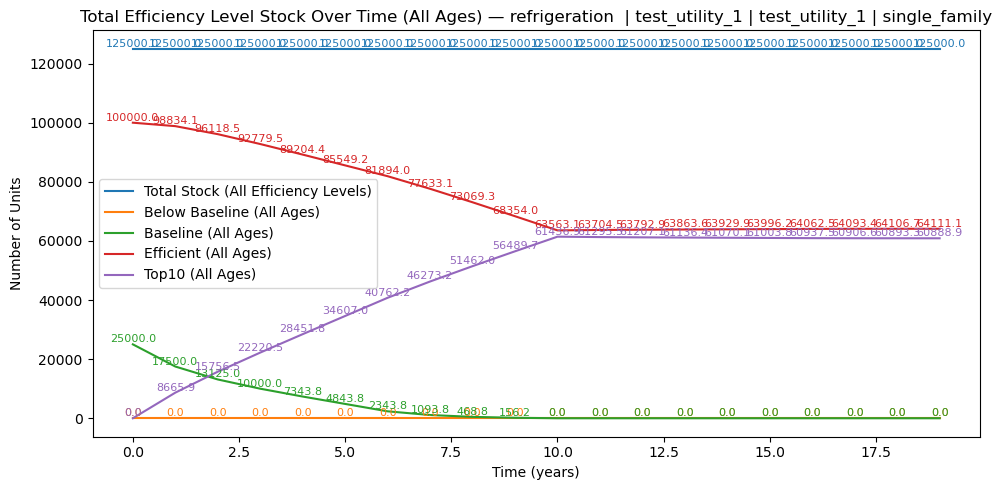

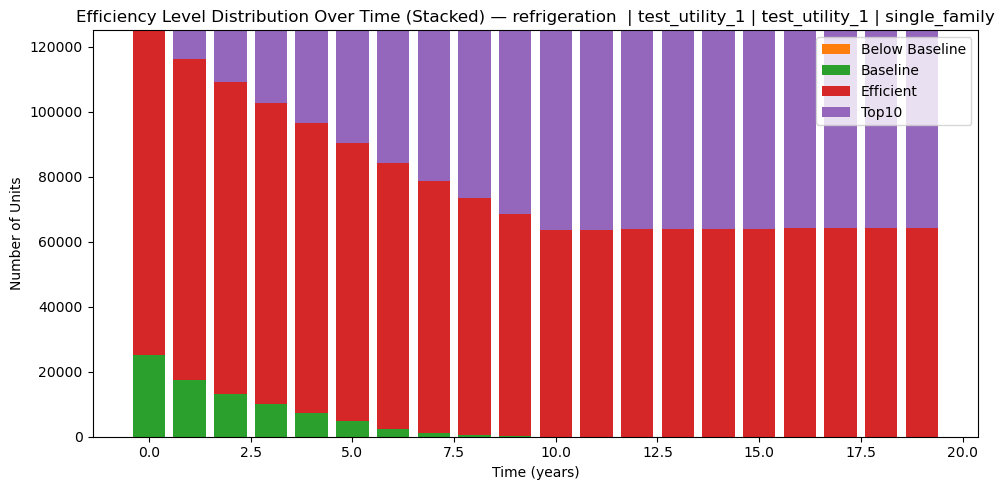

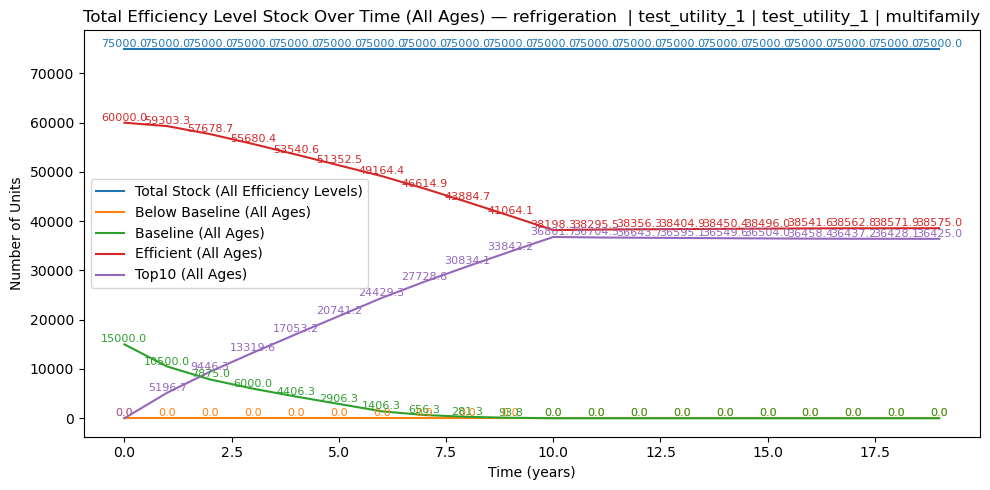

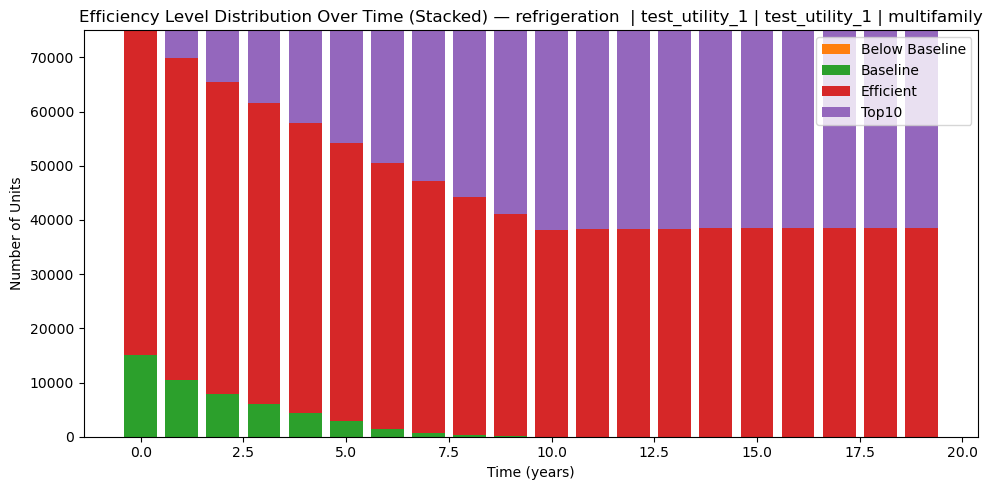

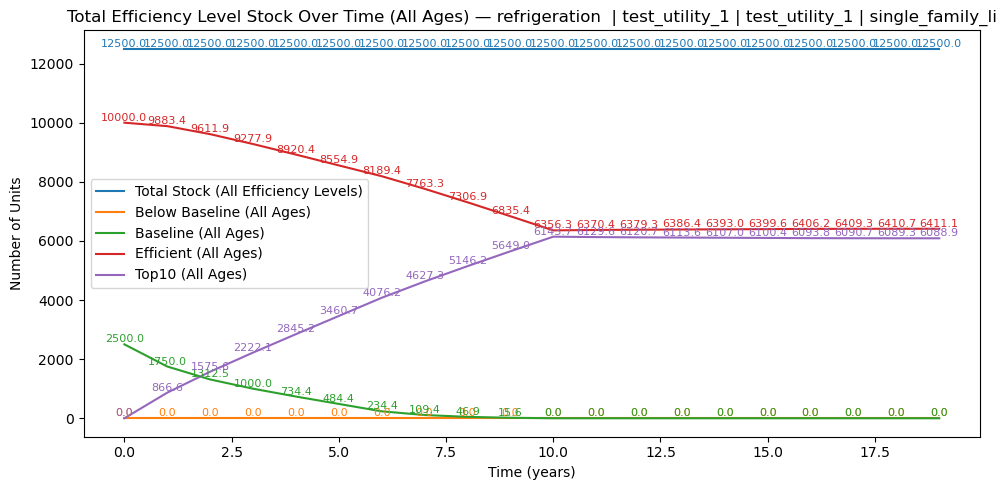

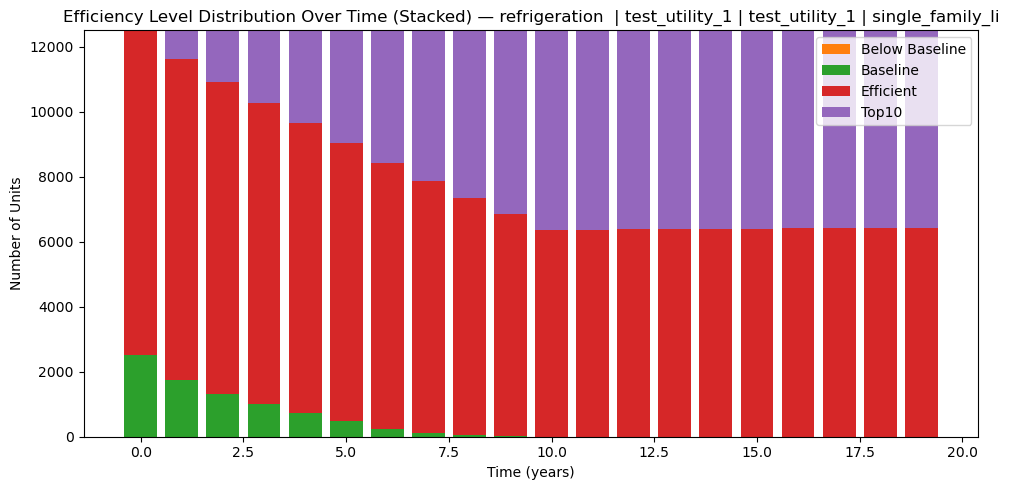

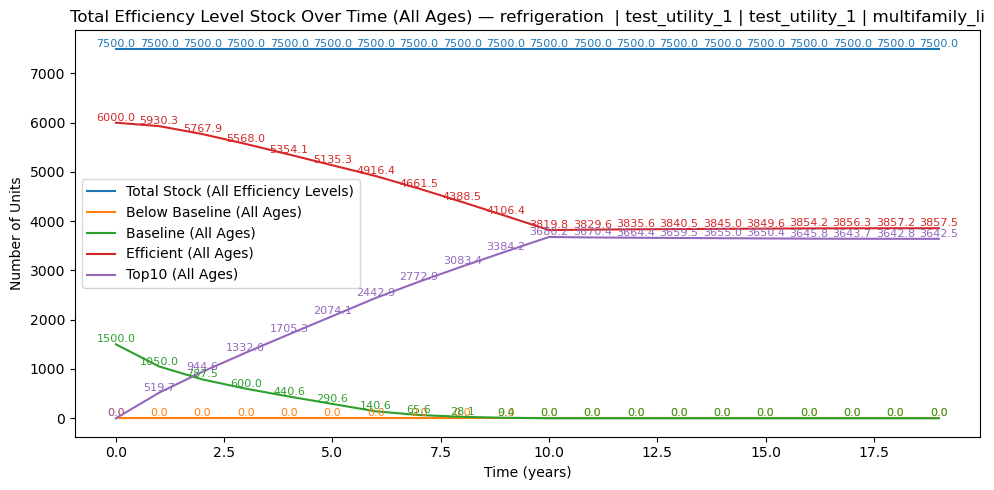

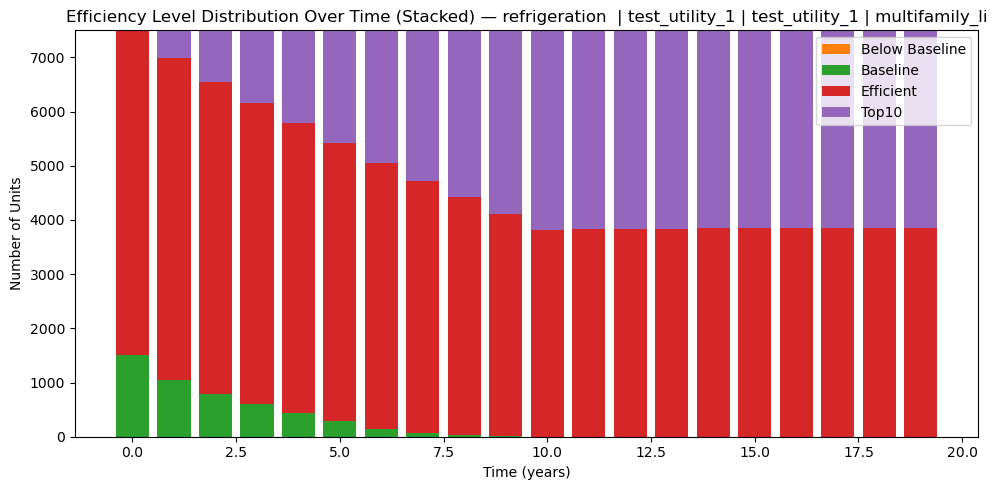

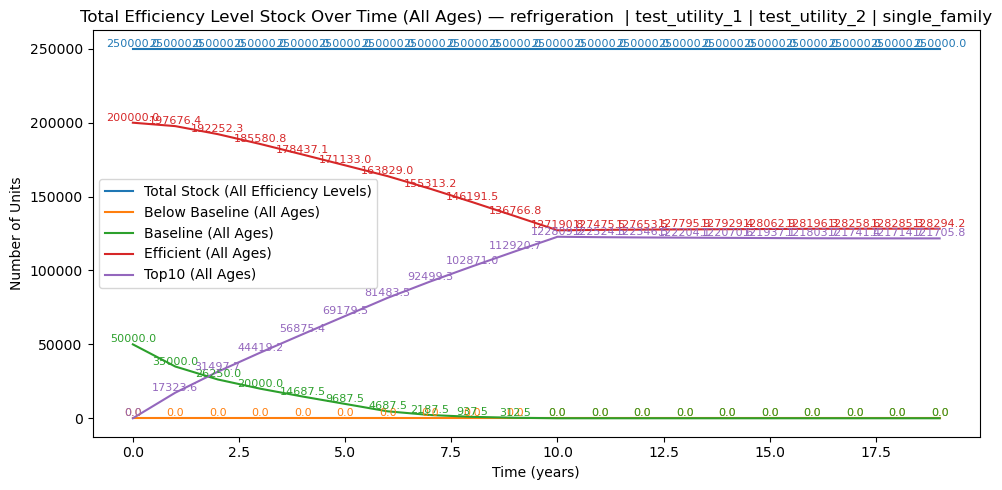

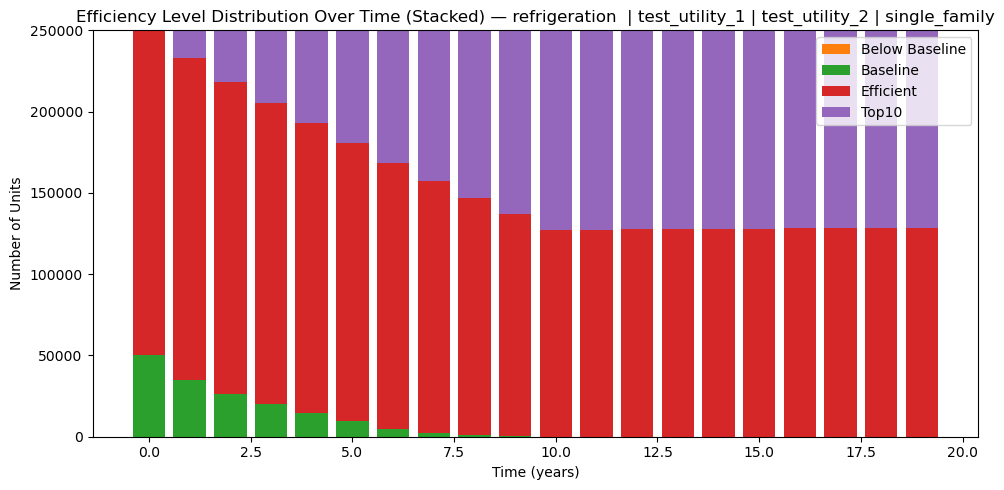

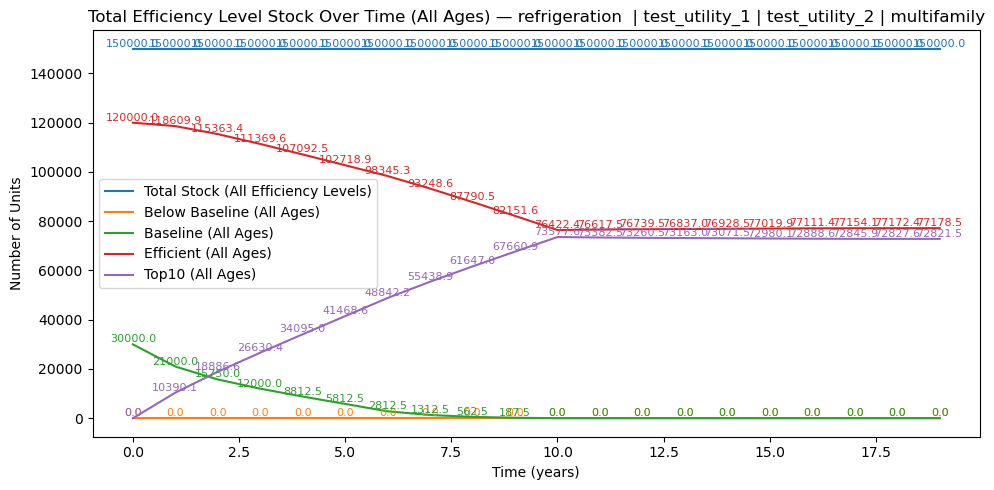

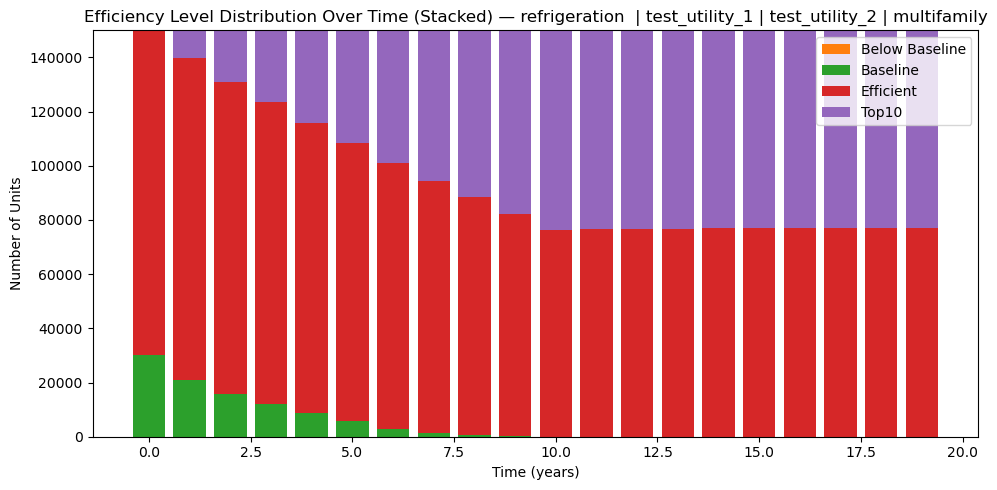

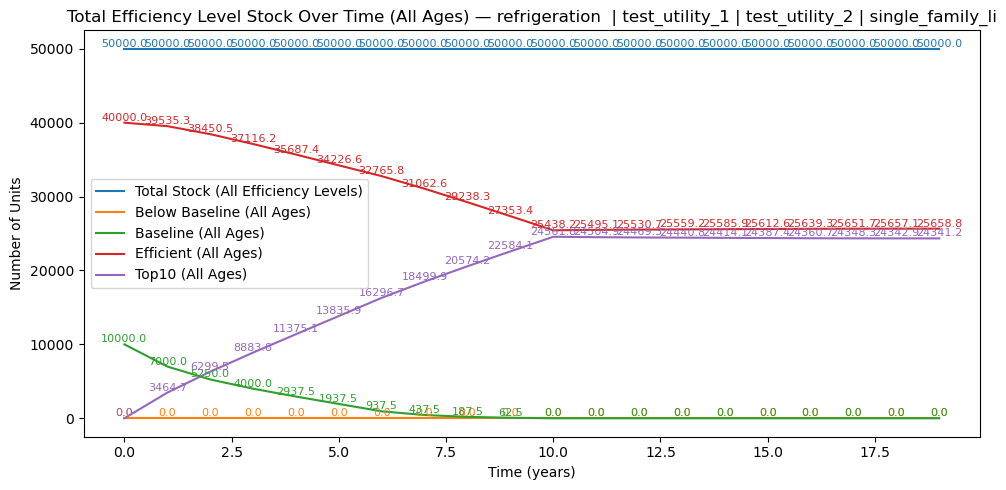

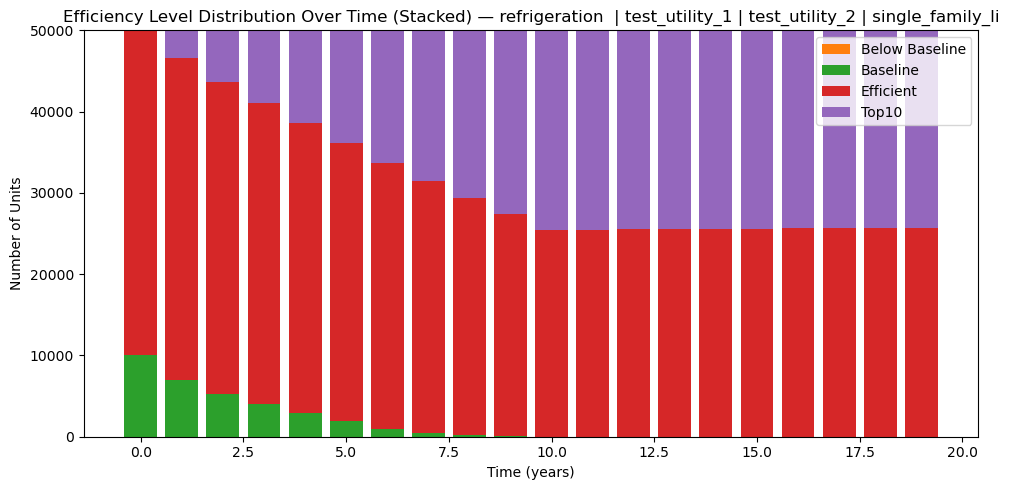

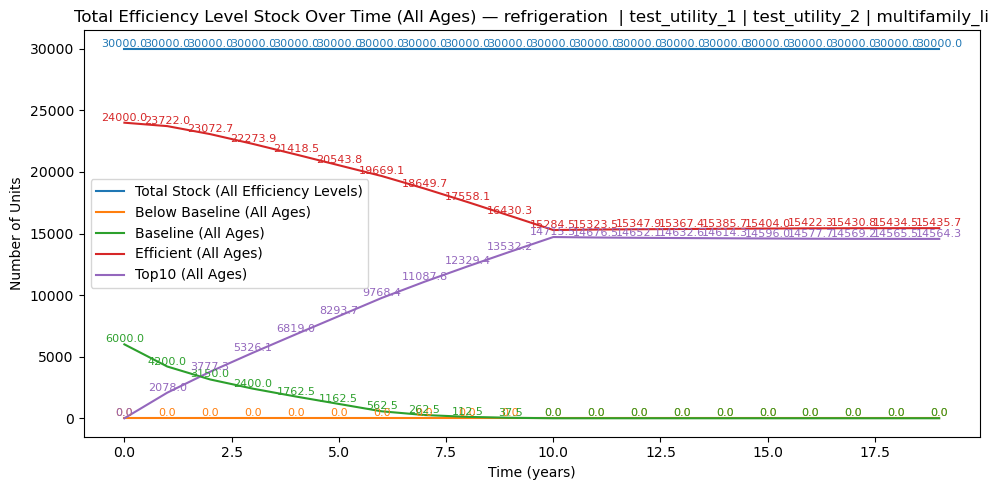

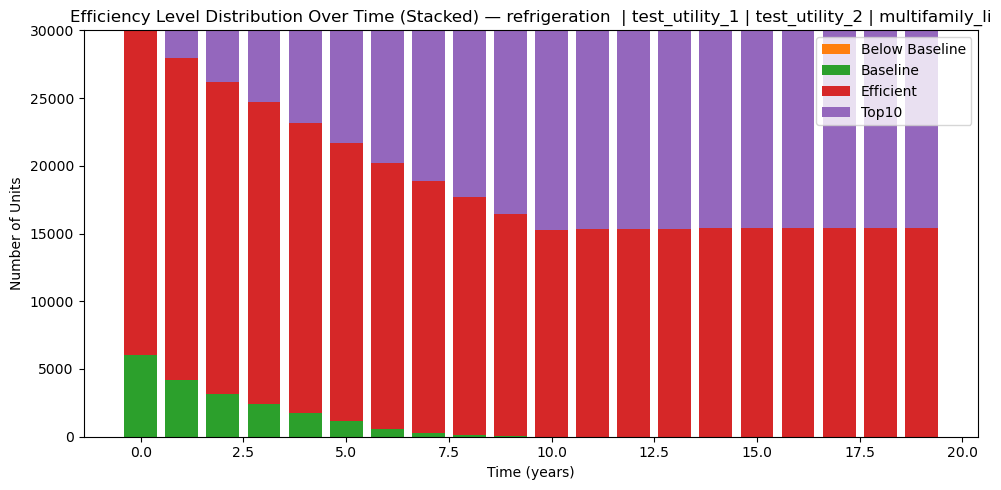

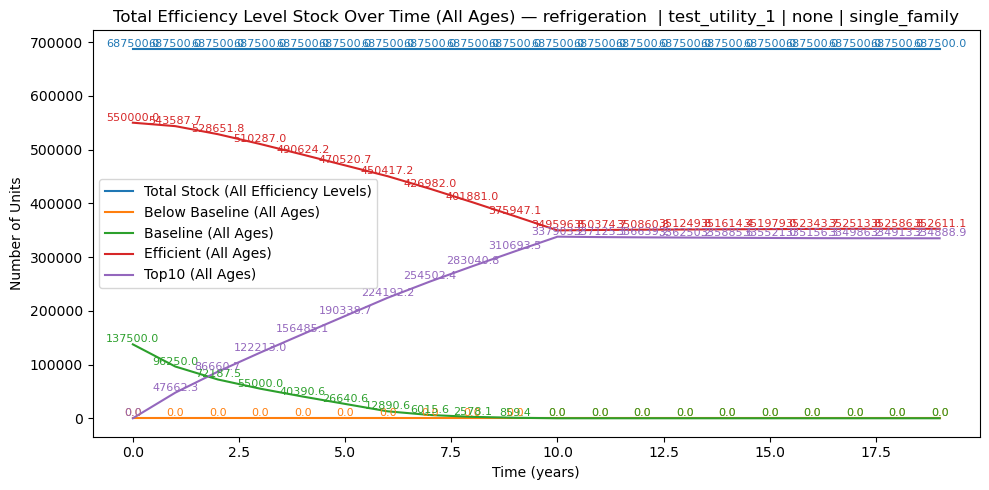

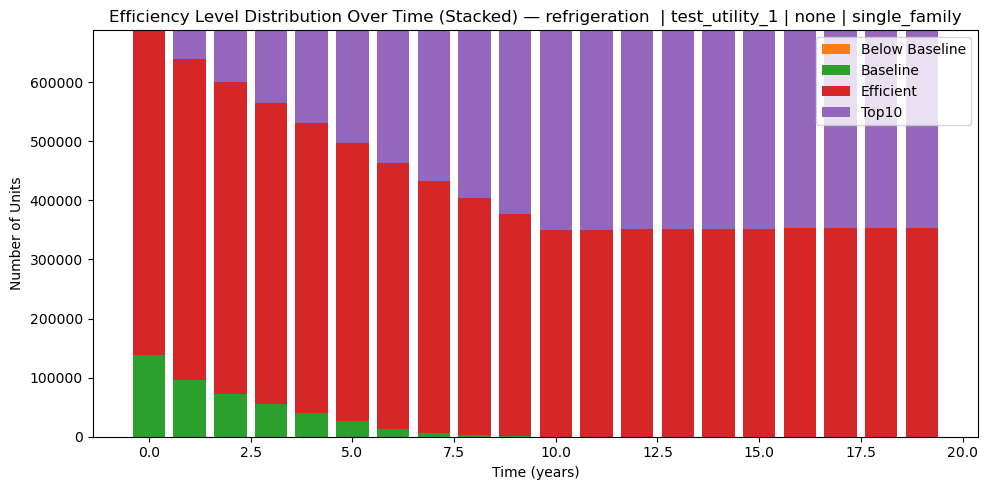

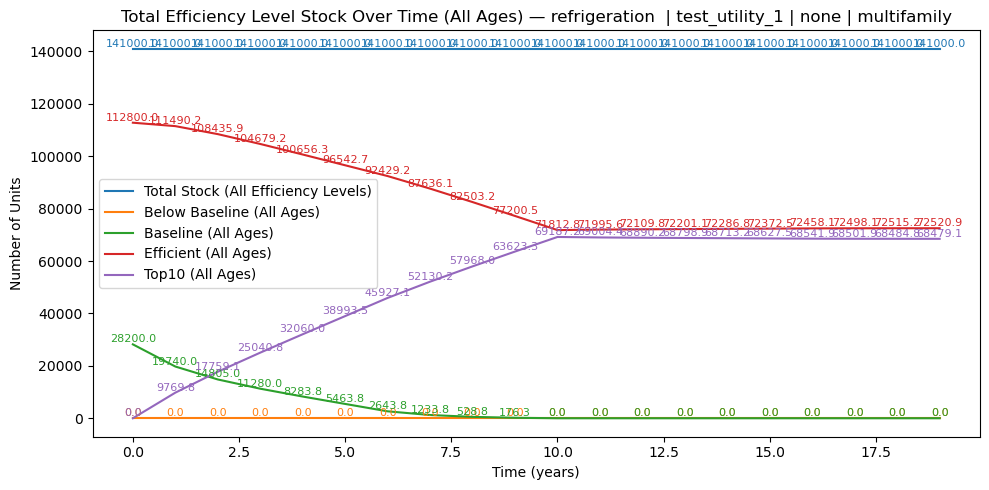

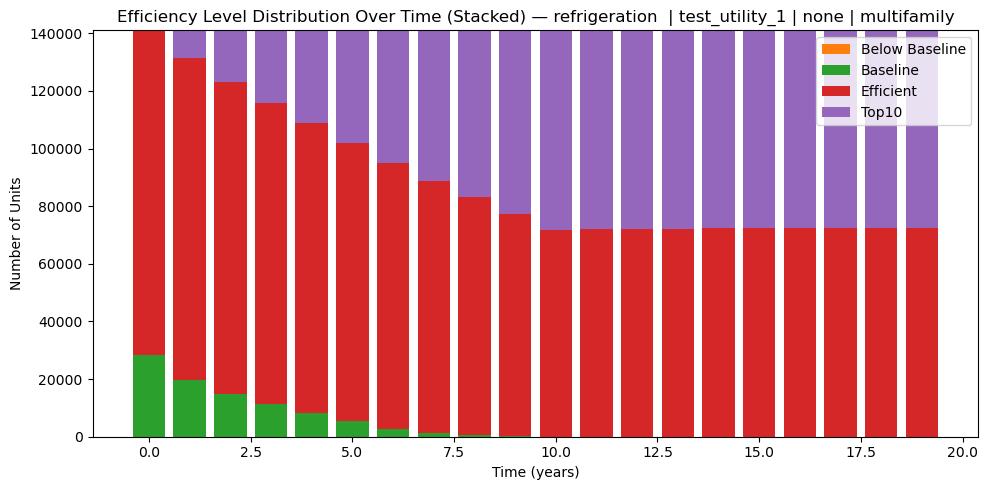

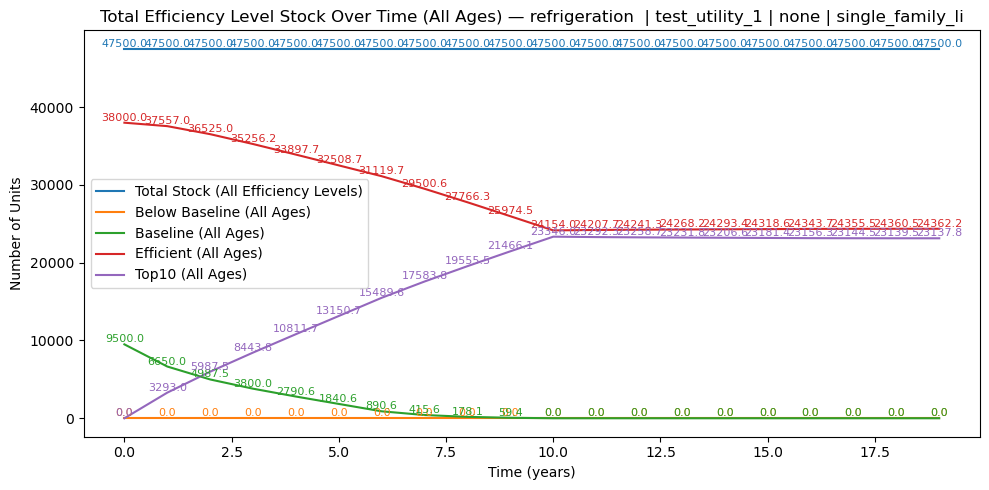

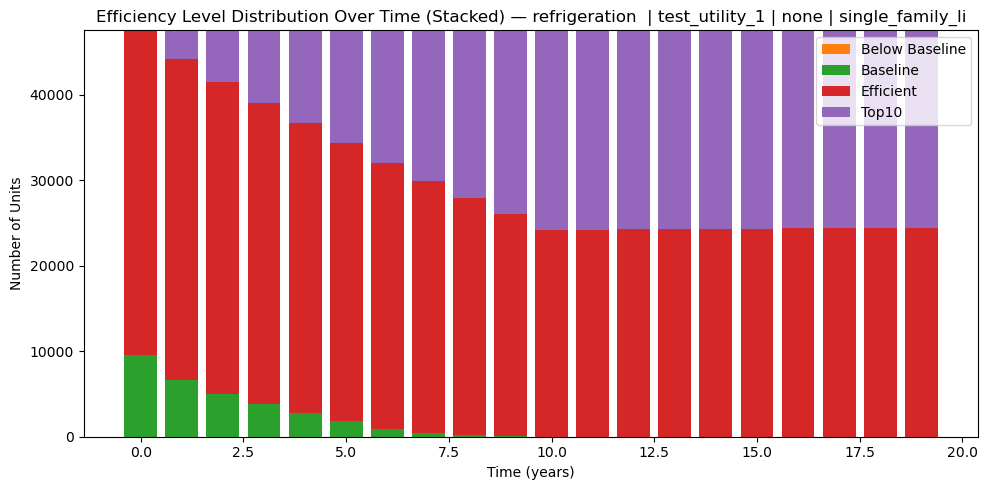

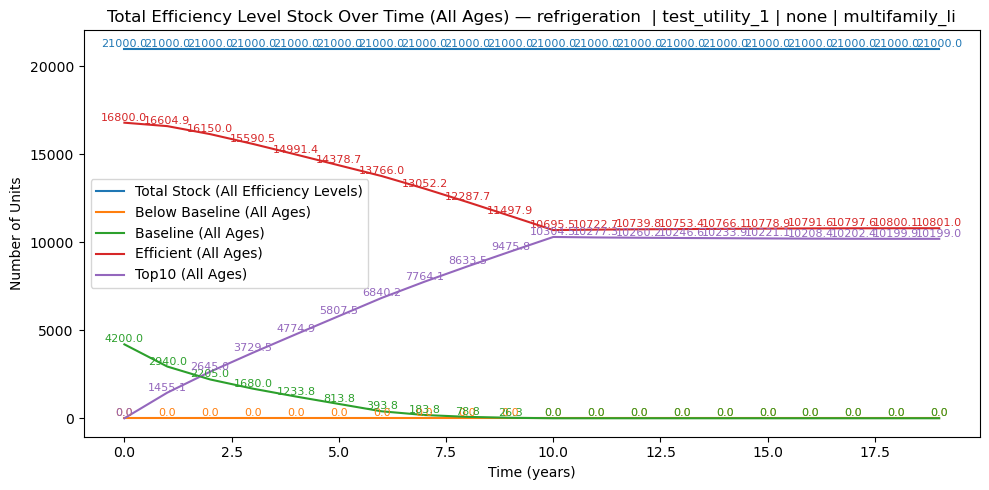

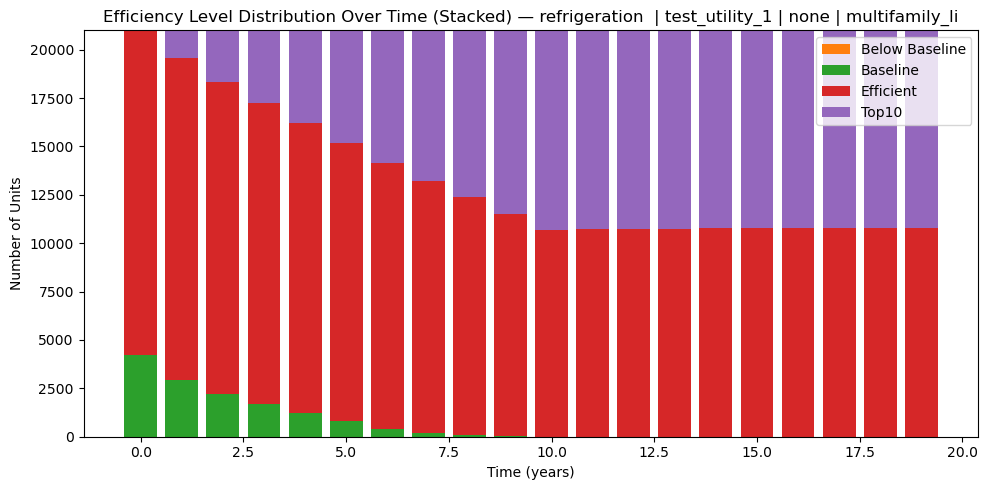

Plotted 12 group combinations.


In [15]:
# Plot results for each group combination
# import matplotlib.pyplot as plt

results_df = competition_results_df  # Change to tech_results_df to plot tech scenario

# Columns that define a group
group_cols = ['competition_group','electric_utility','gas_utility','building_type'] #'subgroup',
unique_groups = results_df[group_cols].drop_duplicates()

for _, g in unique_groups.iterrows():
    # Build mask for this group
    mask = (
        (results_df['competition_group'] == g['competition_group']) &
       # (results_df['subgroup'] == g['subgroup']) &
        (results_df['electric_utility'] == g['electric_utility']) &
        (results_df['gas_utility'] == g['gas_utility']) &
        (results_df['building_type'] == g['building_type'])
    )
    dfg = results_df[mask].sort_values('time')
    if dfg.empty:
        continue
    t = dfg['time'].values

    # Figure title suffix describing the group
    title_suffix = f"{g['competition_group']}  | {g['electric_utility']} | {g['gas_utility']} | {g['building_type']}" # | {g['subgroup']}

    # --- Plot: Total Efficiency Level breakdown (summed across all markets) ---
    plt.figure(figsize=(10, 5))
    total_below_baseline = dfg['total_below_baseline_stock'].values
    total_baseline = dfg['total_baseline_stock'].values
    total_efficient = dfg['total_efficient_stock'].values
    total_top10 = dfg['total_top10_stock'].values
    total_all_efficiency = total_below_baseline + total_baseline + total_efficient + total_top10

    plt.plot(t, total_all_efficiency, label="Total Stock (All Efficiency Levels)")
    plt.plot(t, total_below_baseline, label="Below Baseline (All Ages)")
    plt.plot(t, total_baseline, label="Baseline (All Ages)")
    plt.plot(t, total_efficient, label="Efficient (All Ages)")
    plt.plot(t, total_top10, label="Top10 (All Ages)")
    for i in range(0, len(t), 1):
        plt.text(t[i], total_all_efficiency[i], f"{total_all_efficiency[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:blue')
        plt.text(t[i], total_below_baseline[i], f"{total_below_baseline[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:orange')
        plt.text(t[i], total_baseline[i], f"{total_baseline[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:green')
        plt.text(t[i], total_efficient[i], f"{total_efficient[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:red')
        plt.text(t[i], total_top10[i], f"{total_top10[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:purple')
    plt.xlabel("Time (years)")
    plt.ylabel("Number of Units")
    plt.title("Total Efficiency Level Stock Over Time (All Ages) — " + title_suffix)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Stacked Bar Chart: Efficiency Level Distribution Over Time ---
    plt.figure(figsize=(10, 5))
    
    # Create stacked bar chart
    bar_width = 0.8
    plt.bar(t, total_below_baseline, bar_width, label='Below Baseline', color='tab:orange')
    plt.bar(t, total_baseline, bar_width, bottom=total_below_baseline, label='Baseline', color='tab:green')
    plt.bar(t, total_efficient, bar_width, bottom=total_below_baseline + total_baseline, label='Efficient', color='tab:red')
    plt.bar(t, total_top10, bar_width, bottom=total_below_baseline + total_baseline + total_efficient, label='Top10', color='tab:purple')
    
    plt.xlabel("Time (years)")
    plt.ylabel("Number of Units")
    plt.title("Efficiency Level Distribution Over Time (Stacked) — " + title_suffix)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Done plotting all groups
print(f"Plotted {len(unique_groups)} group combinations.")

Generating age cohort visualizations from stored data...


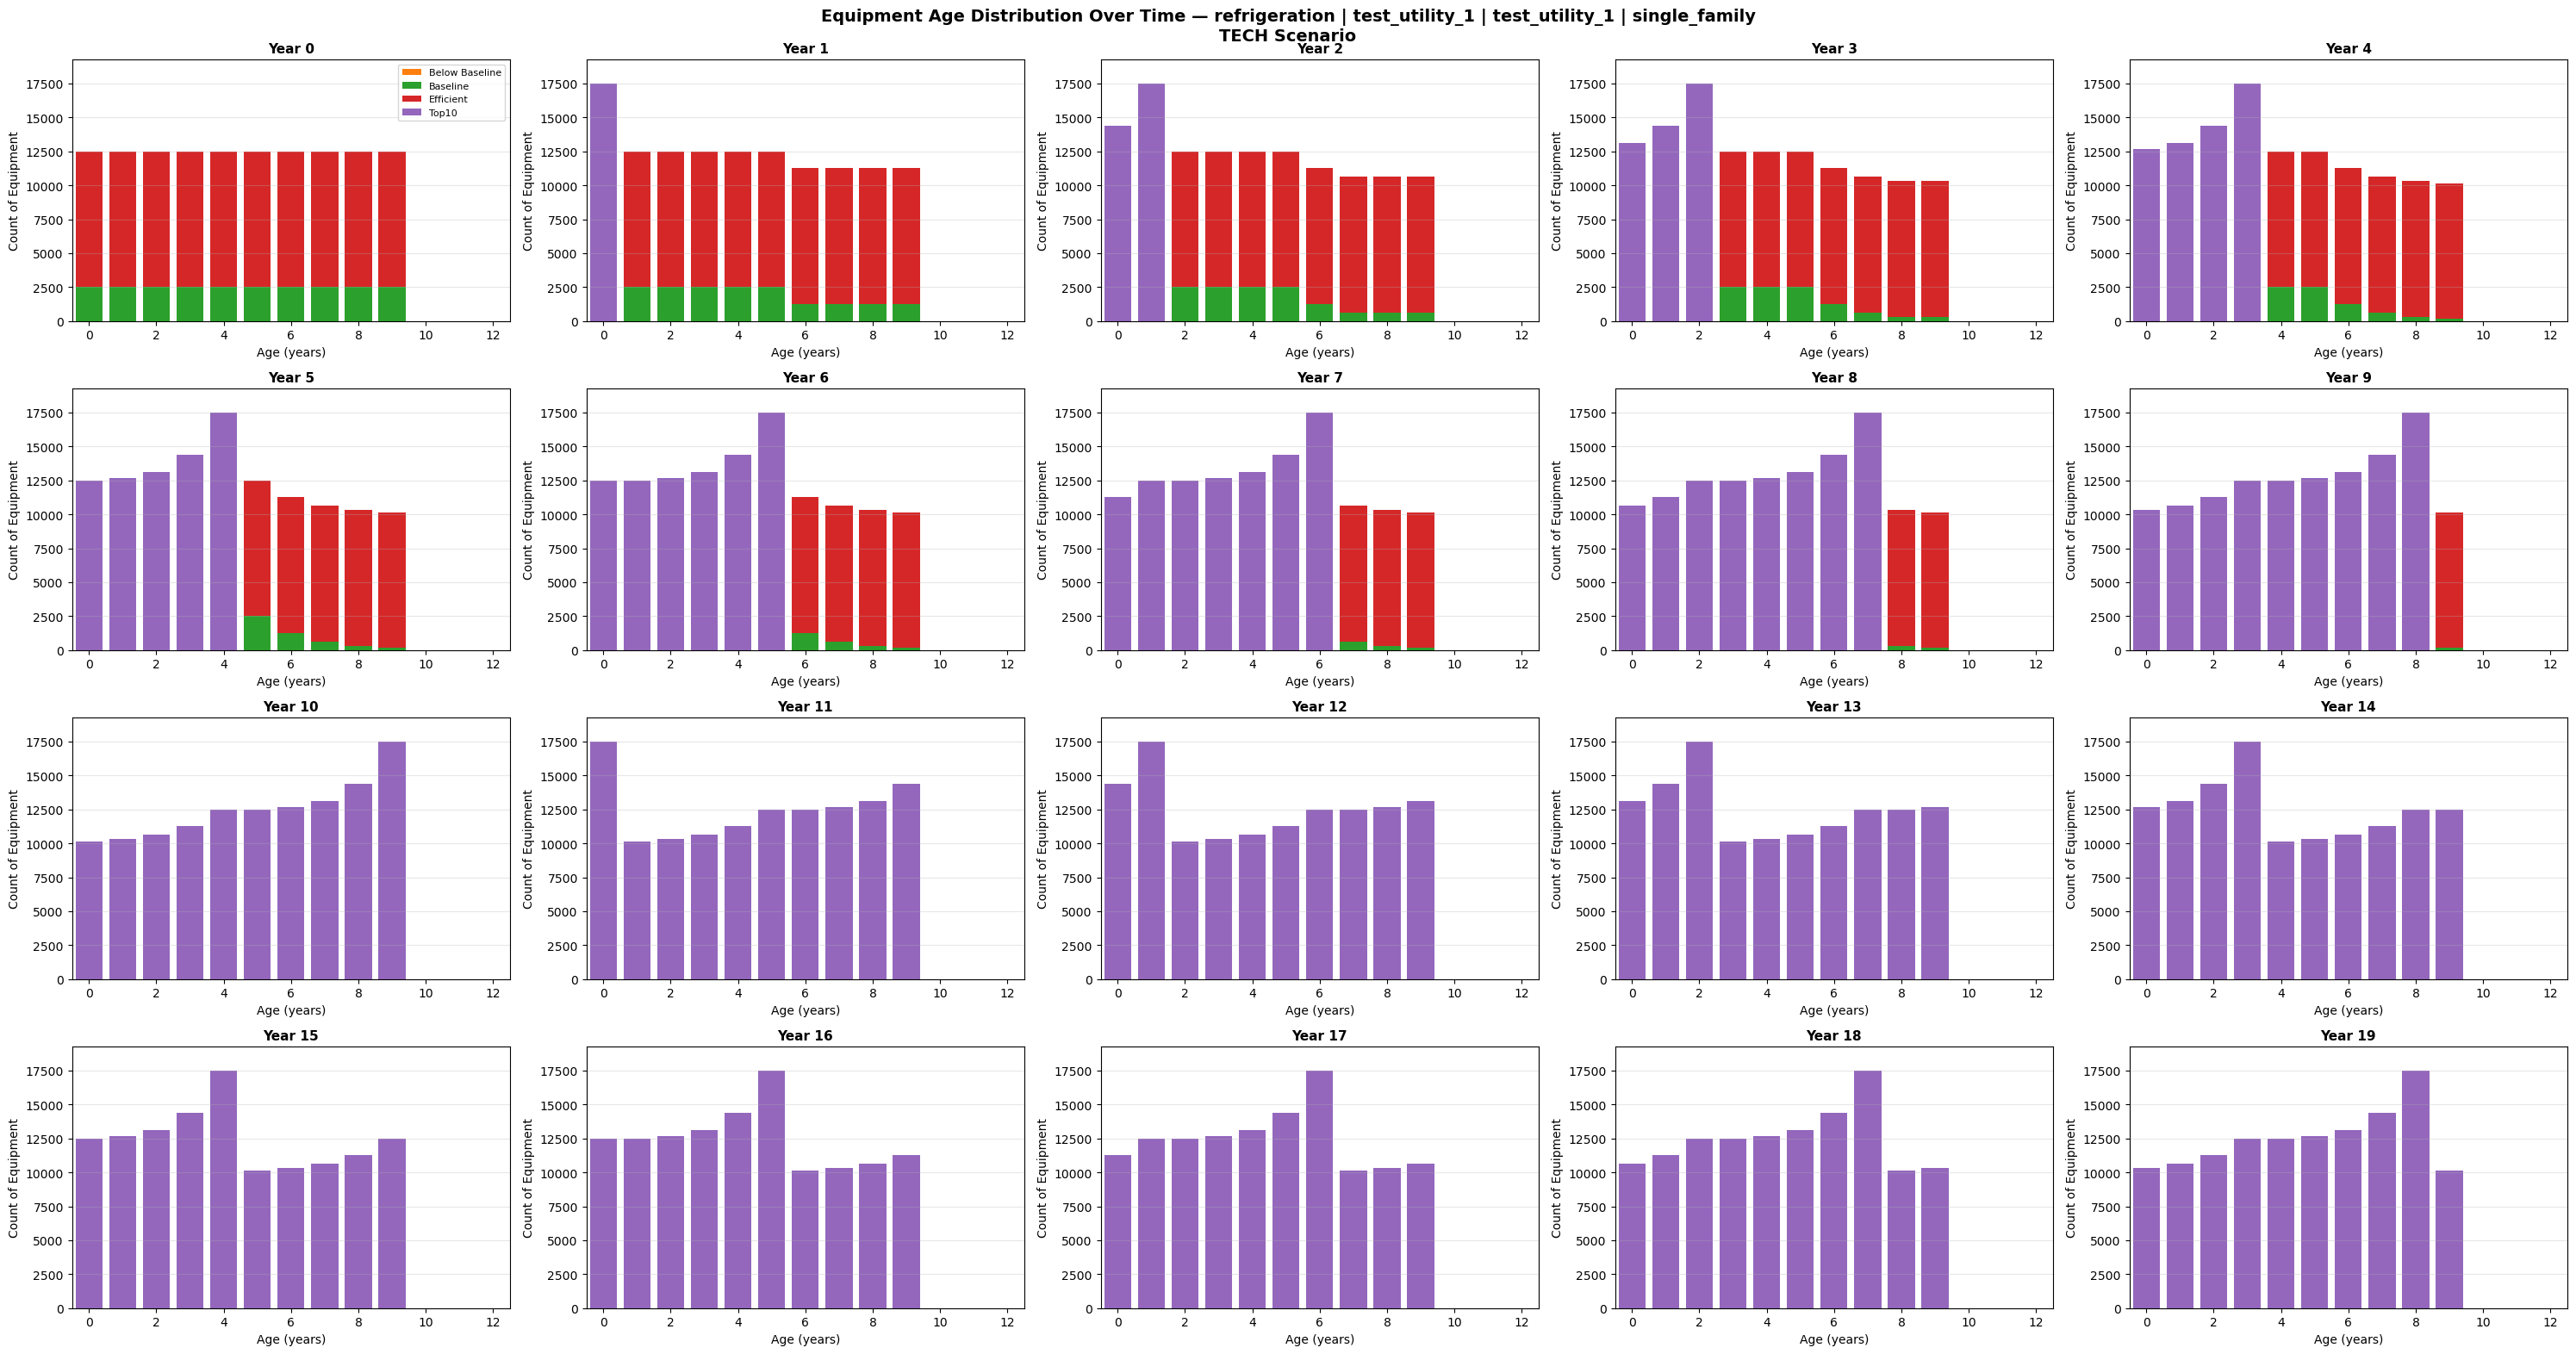

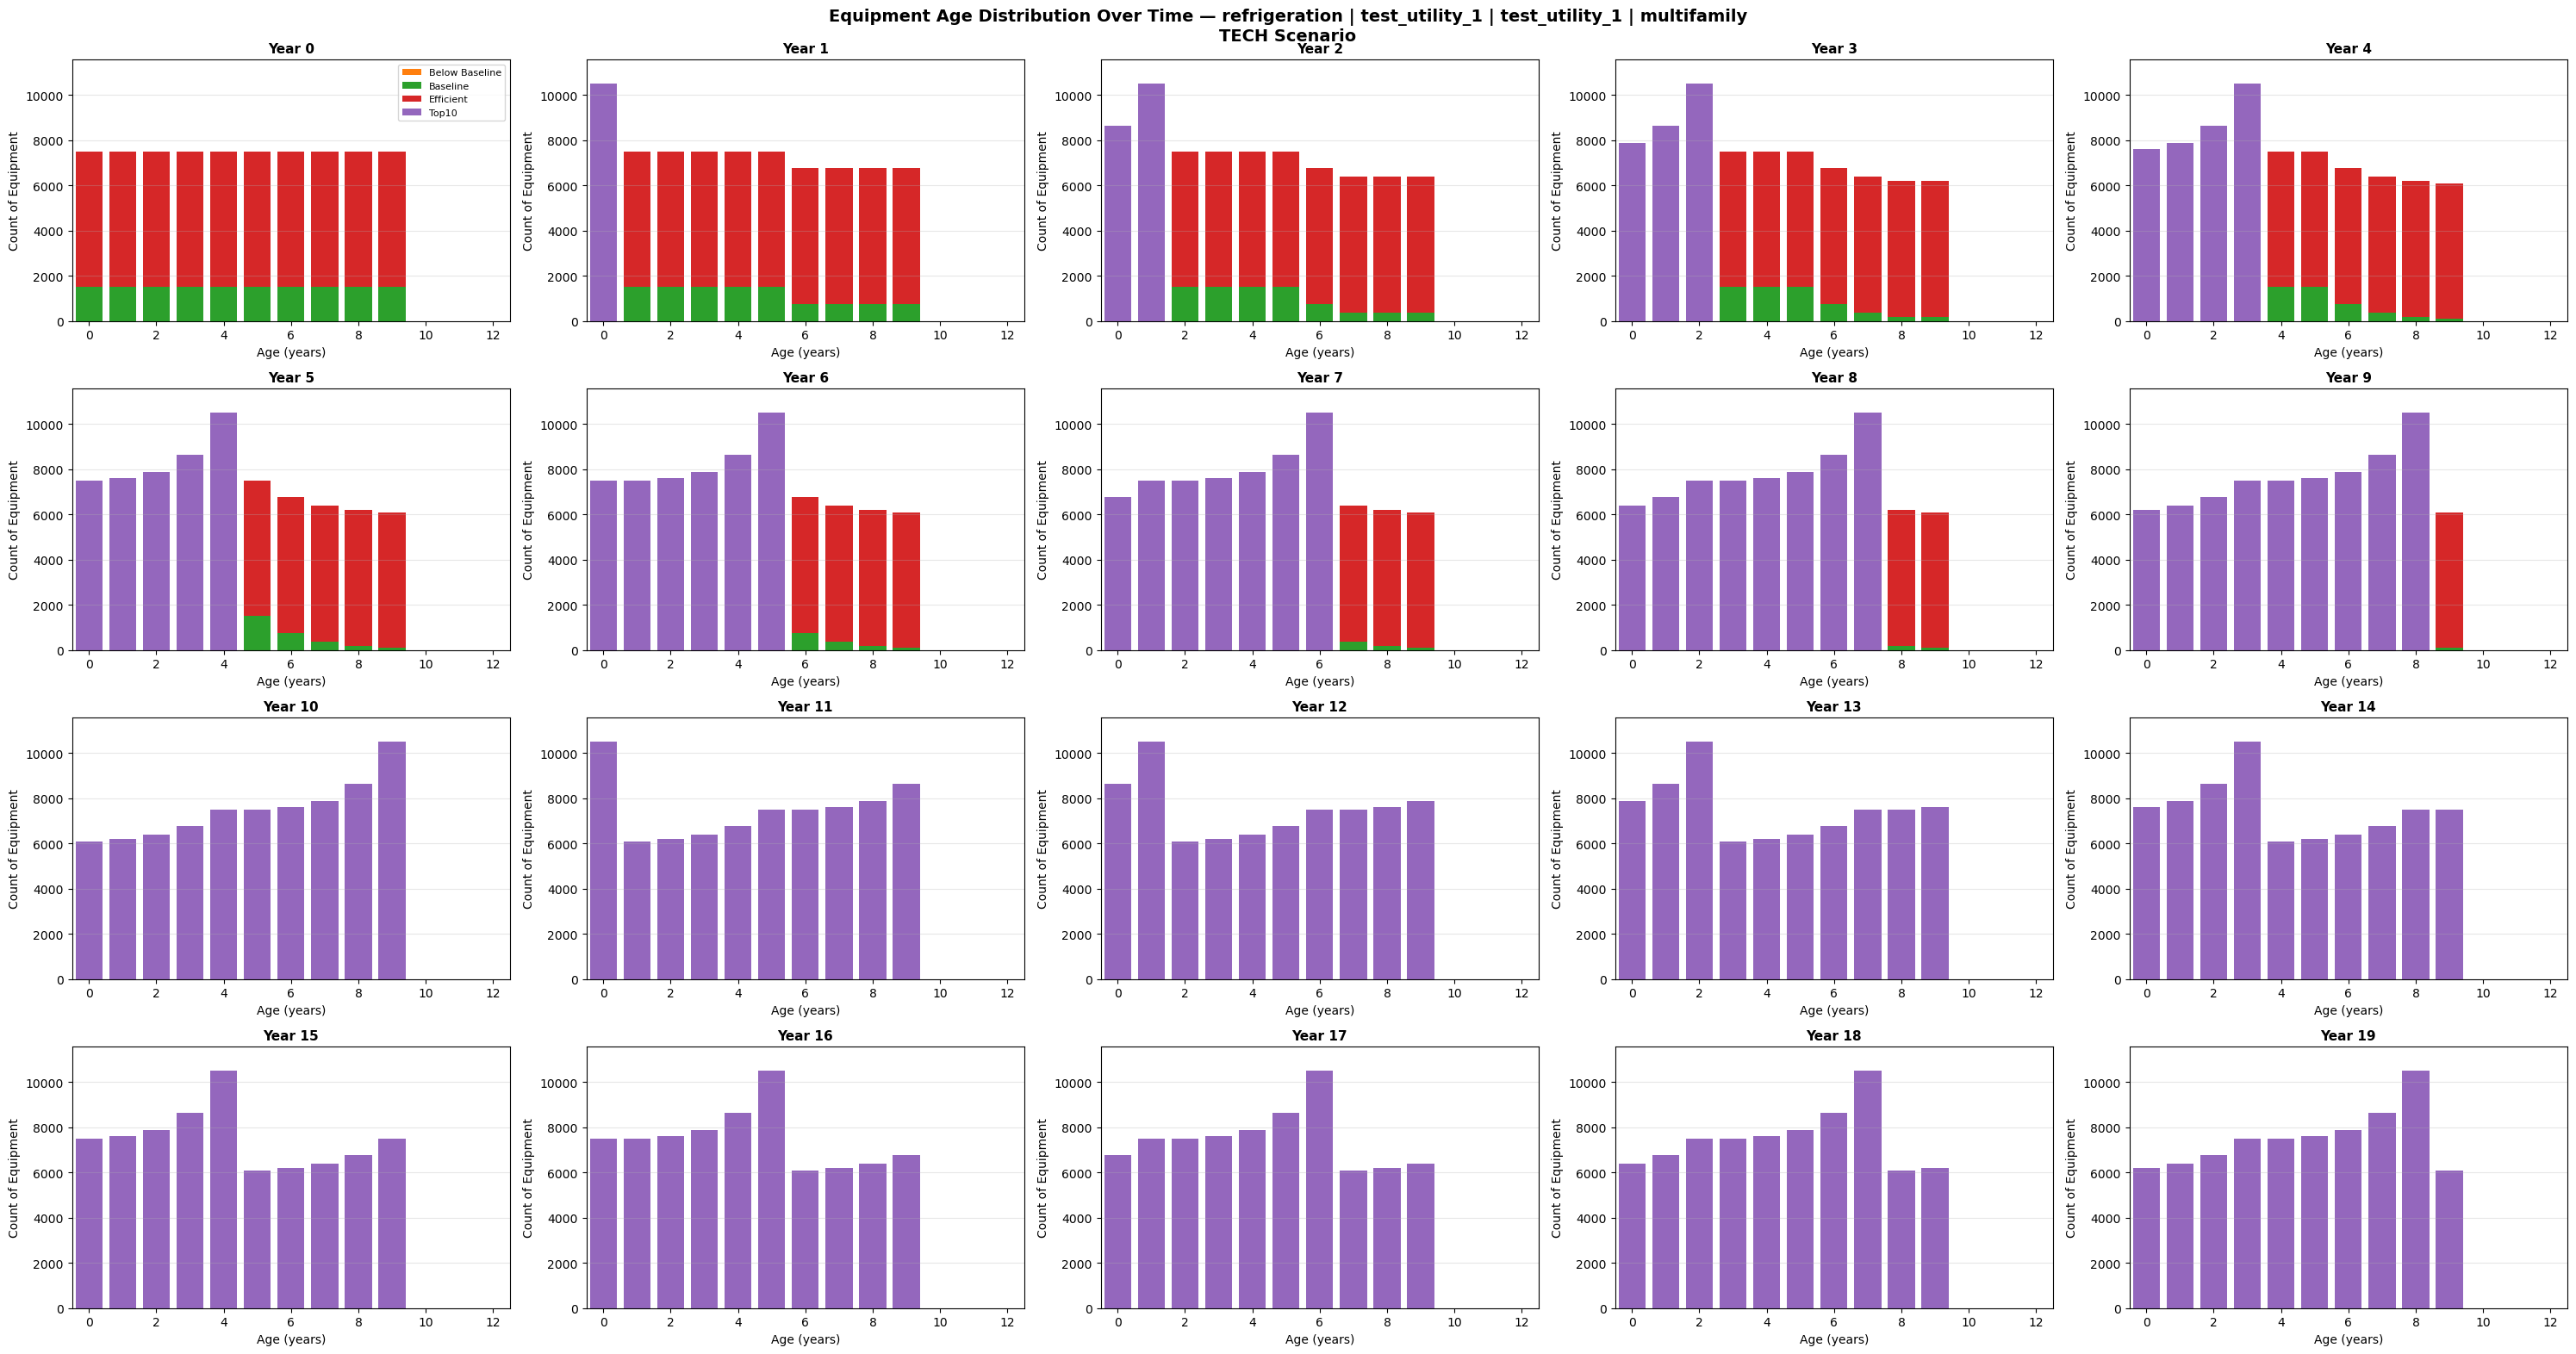

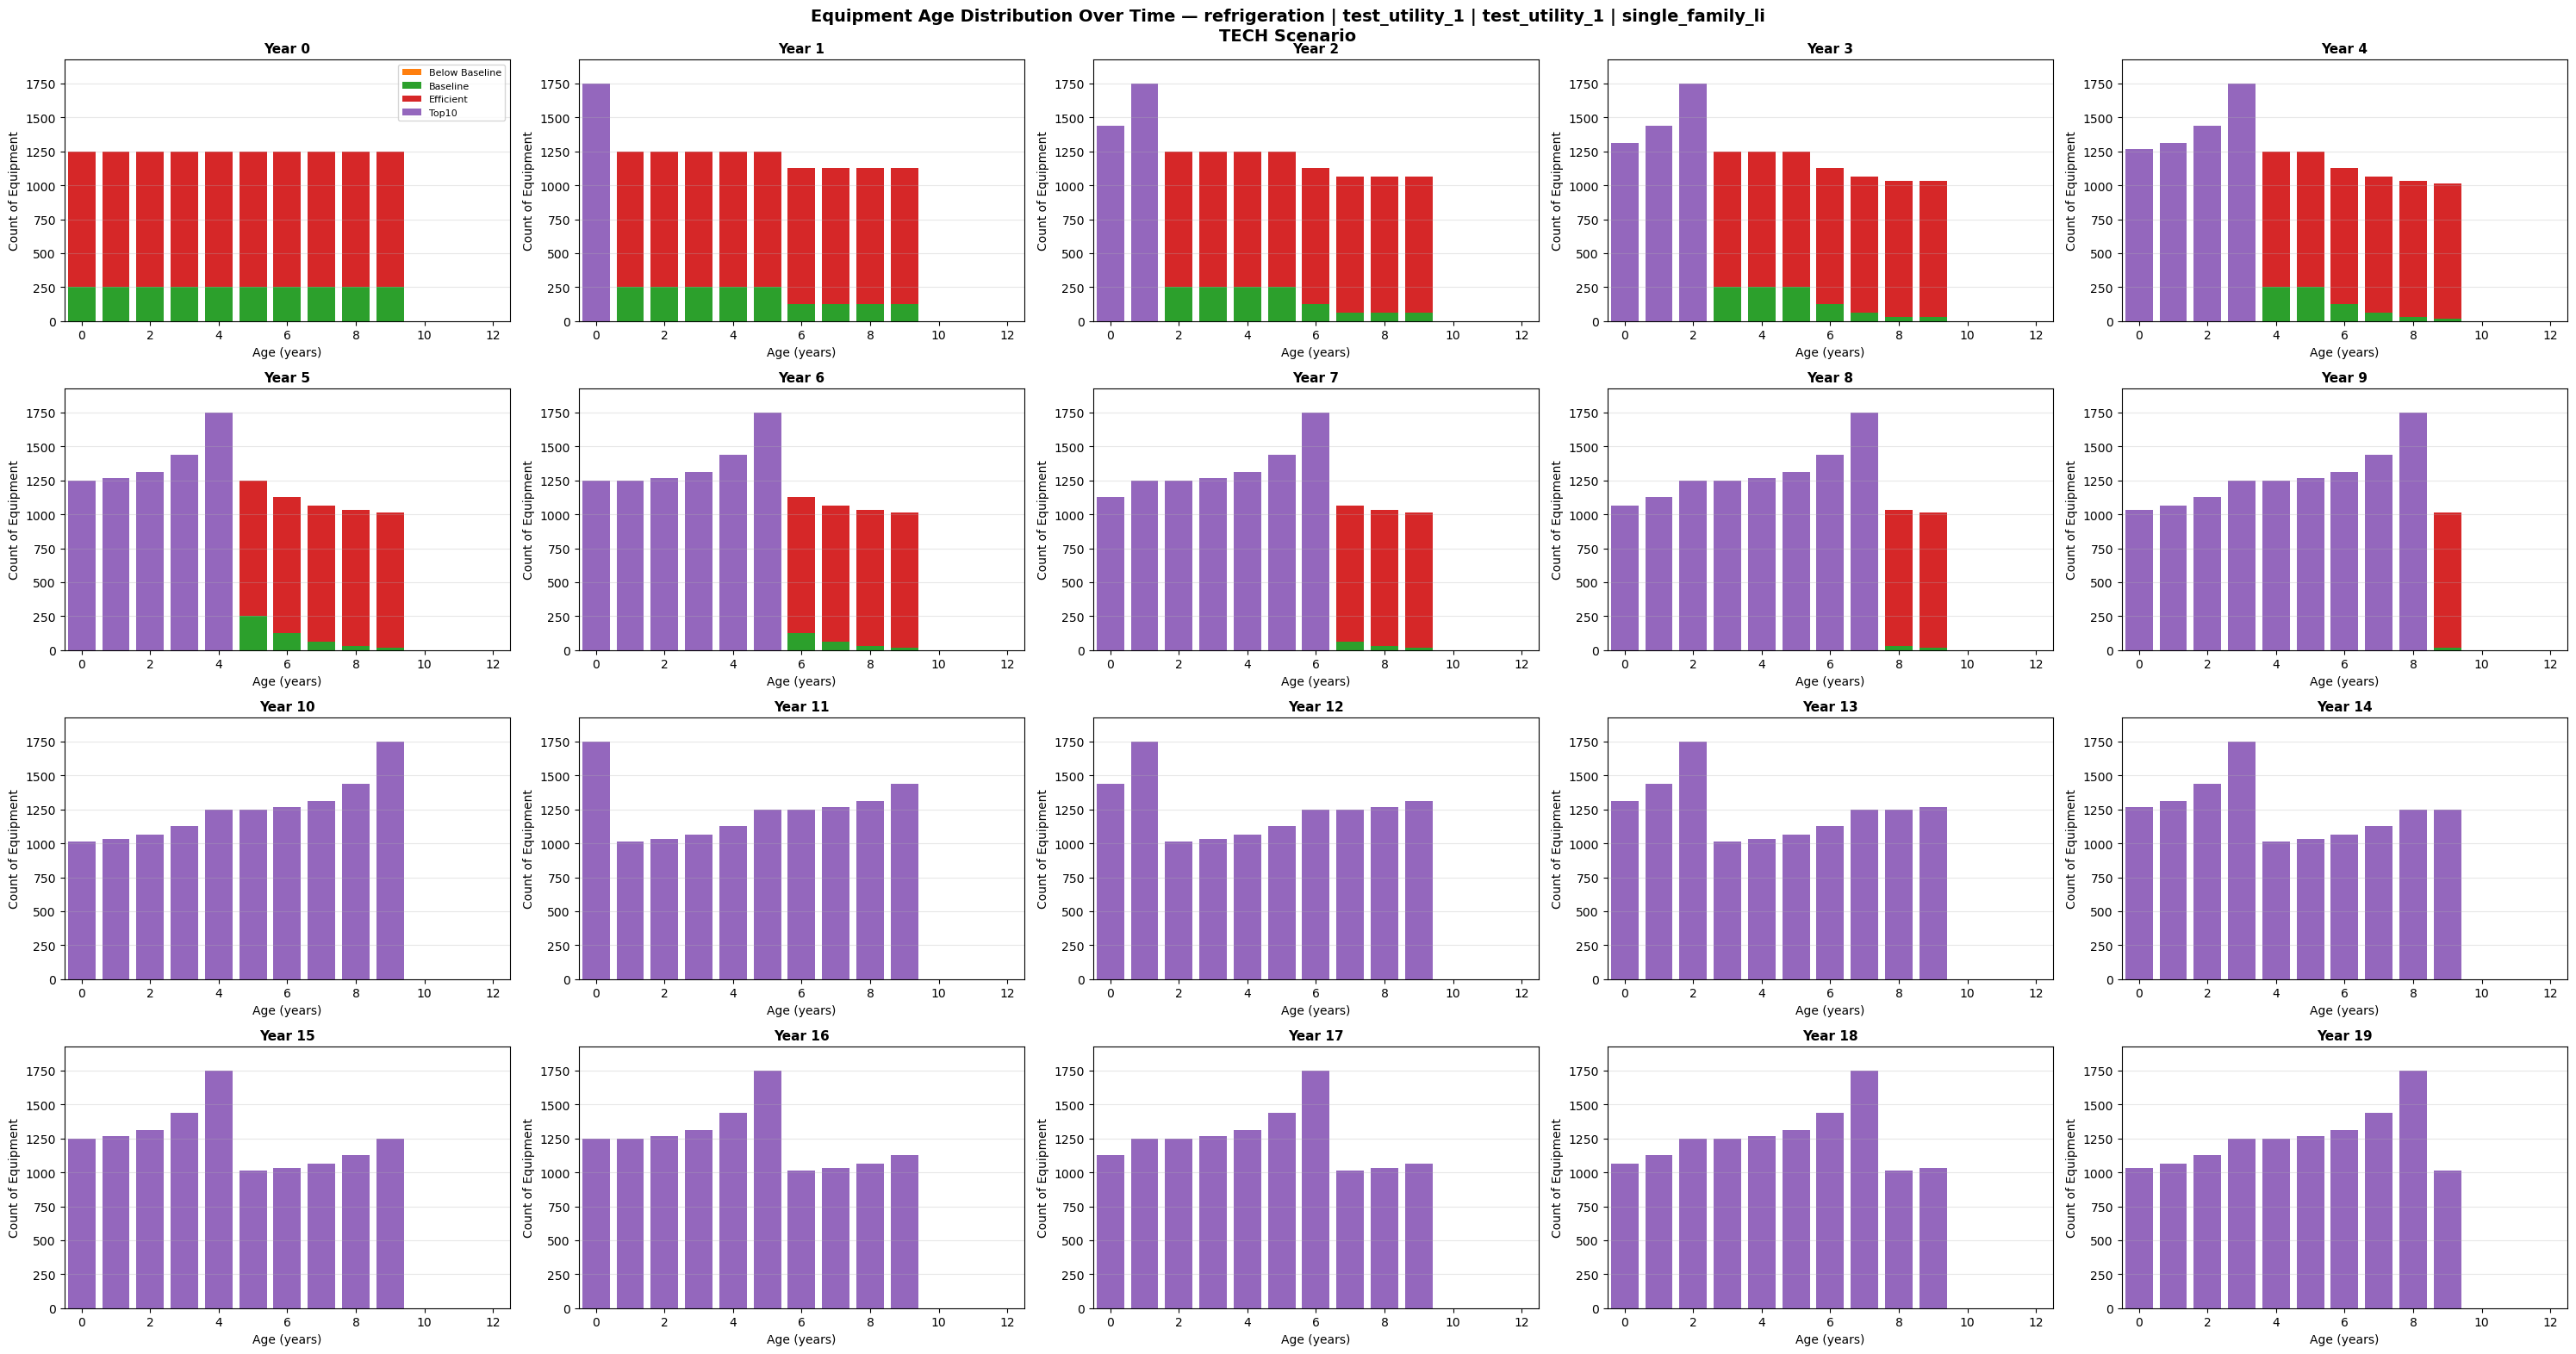

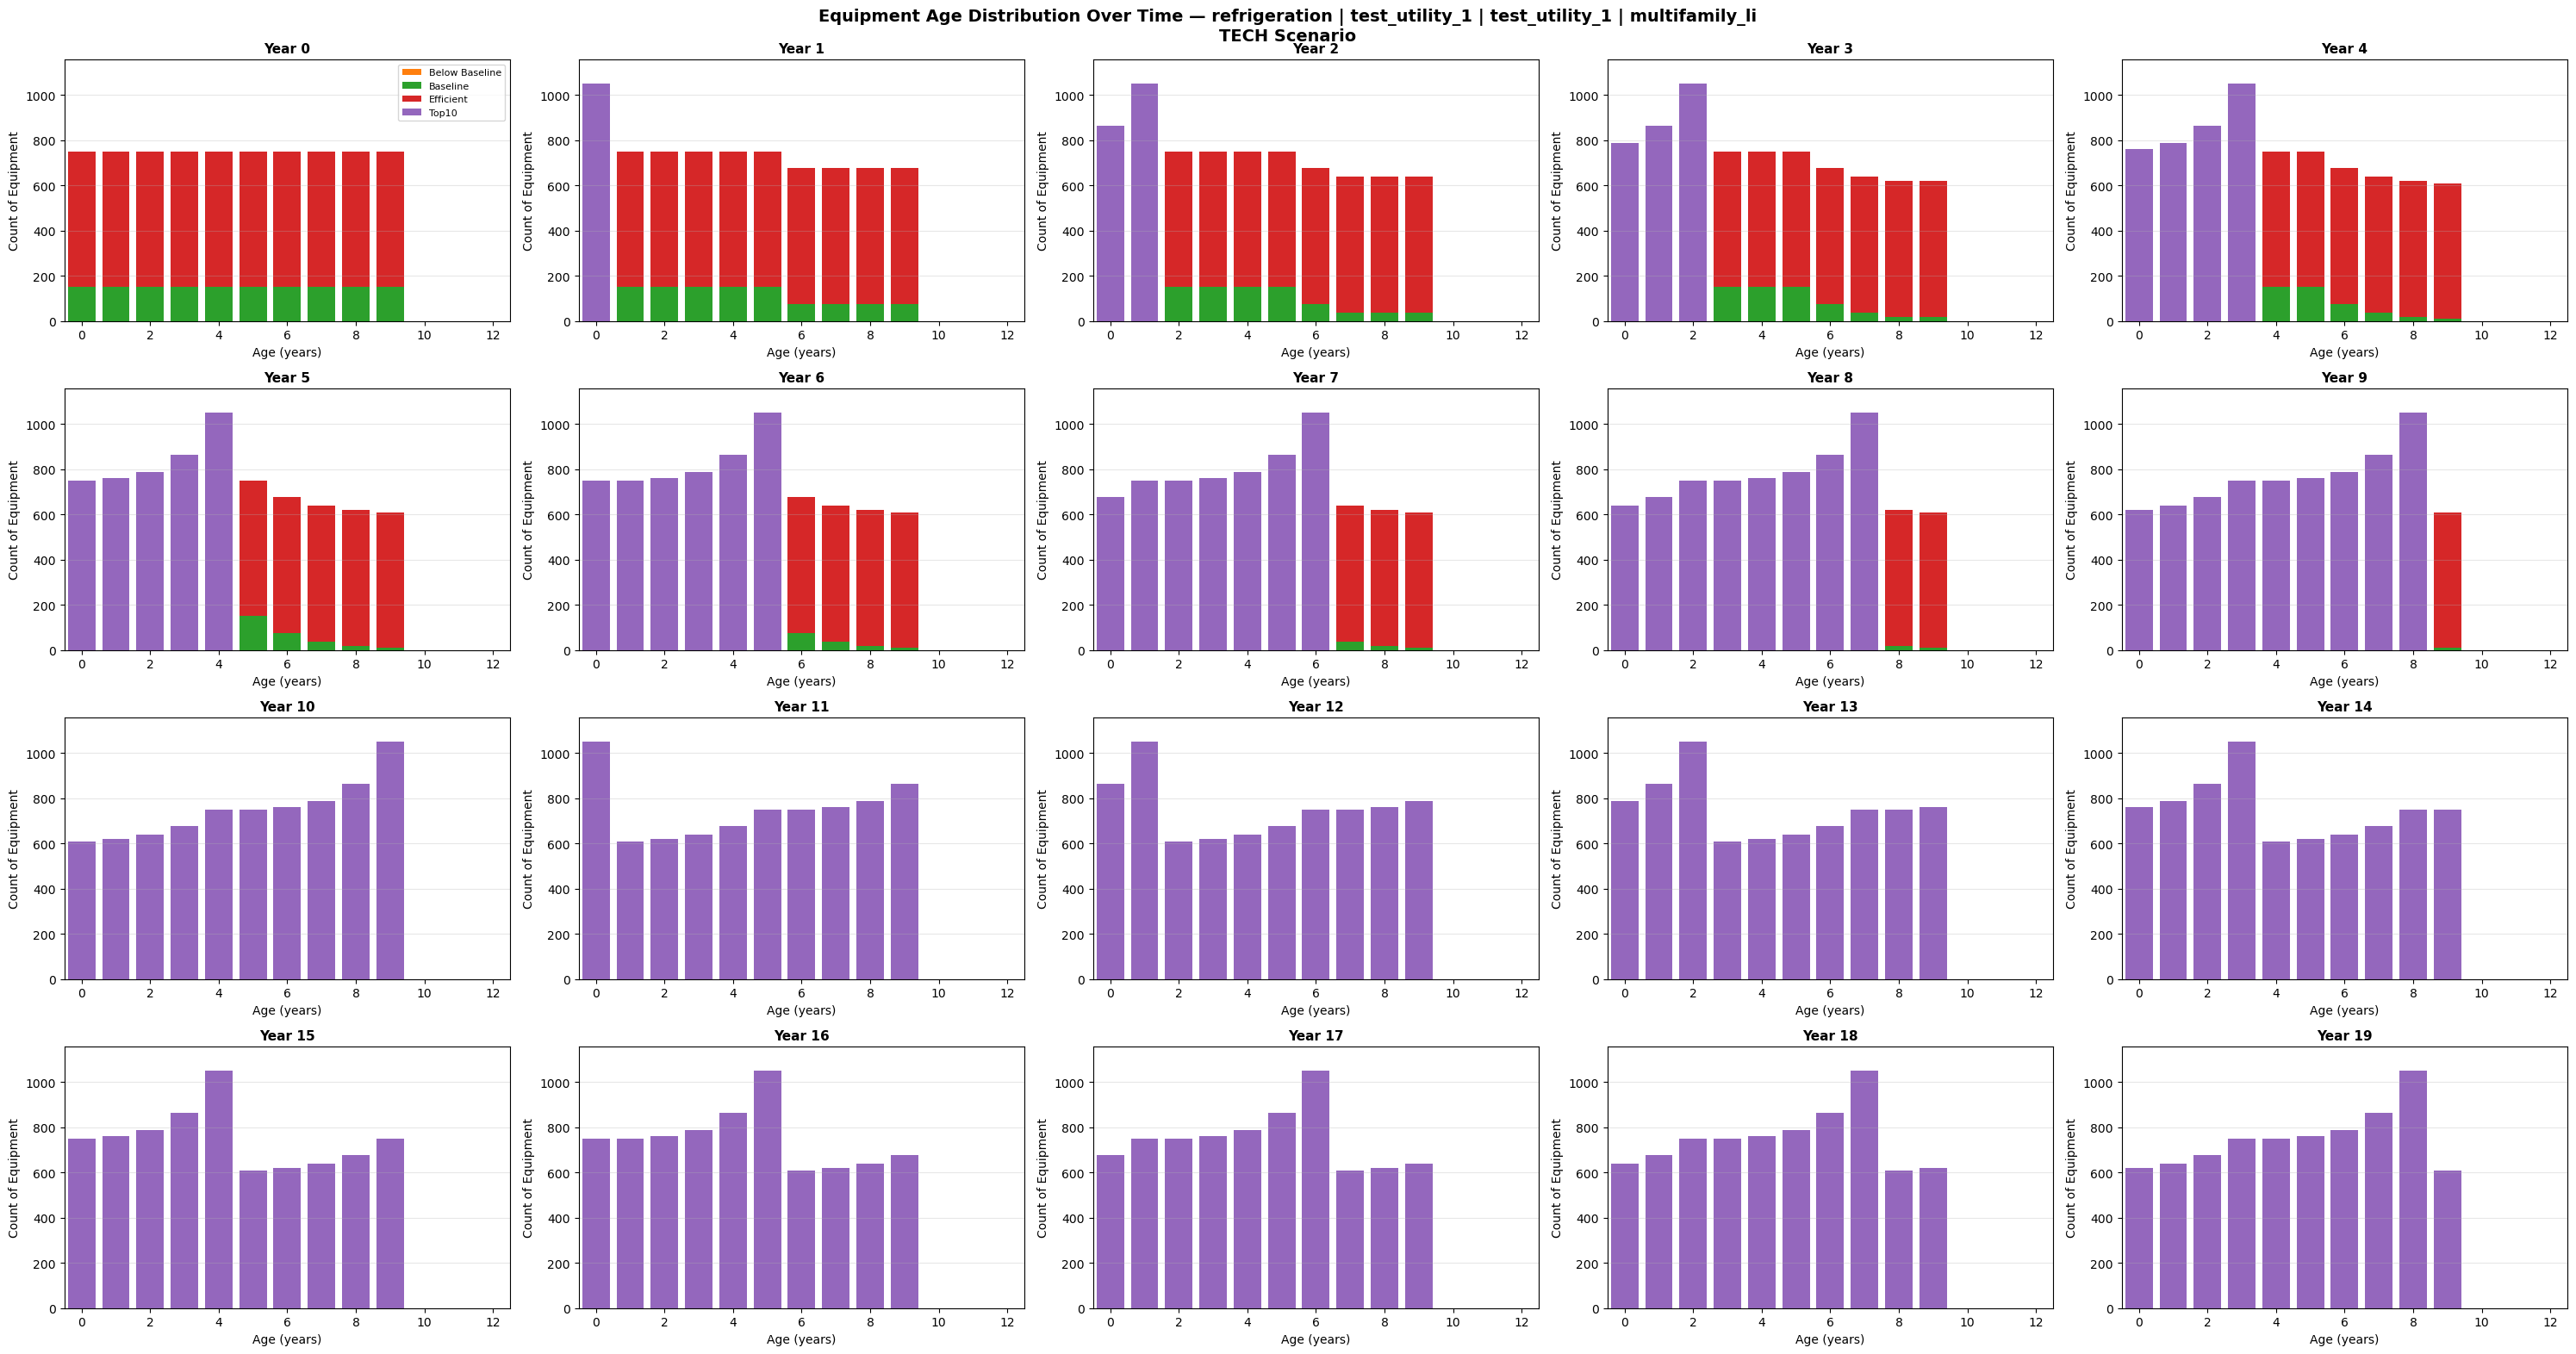

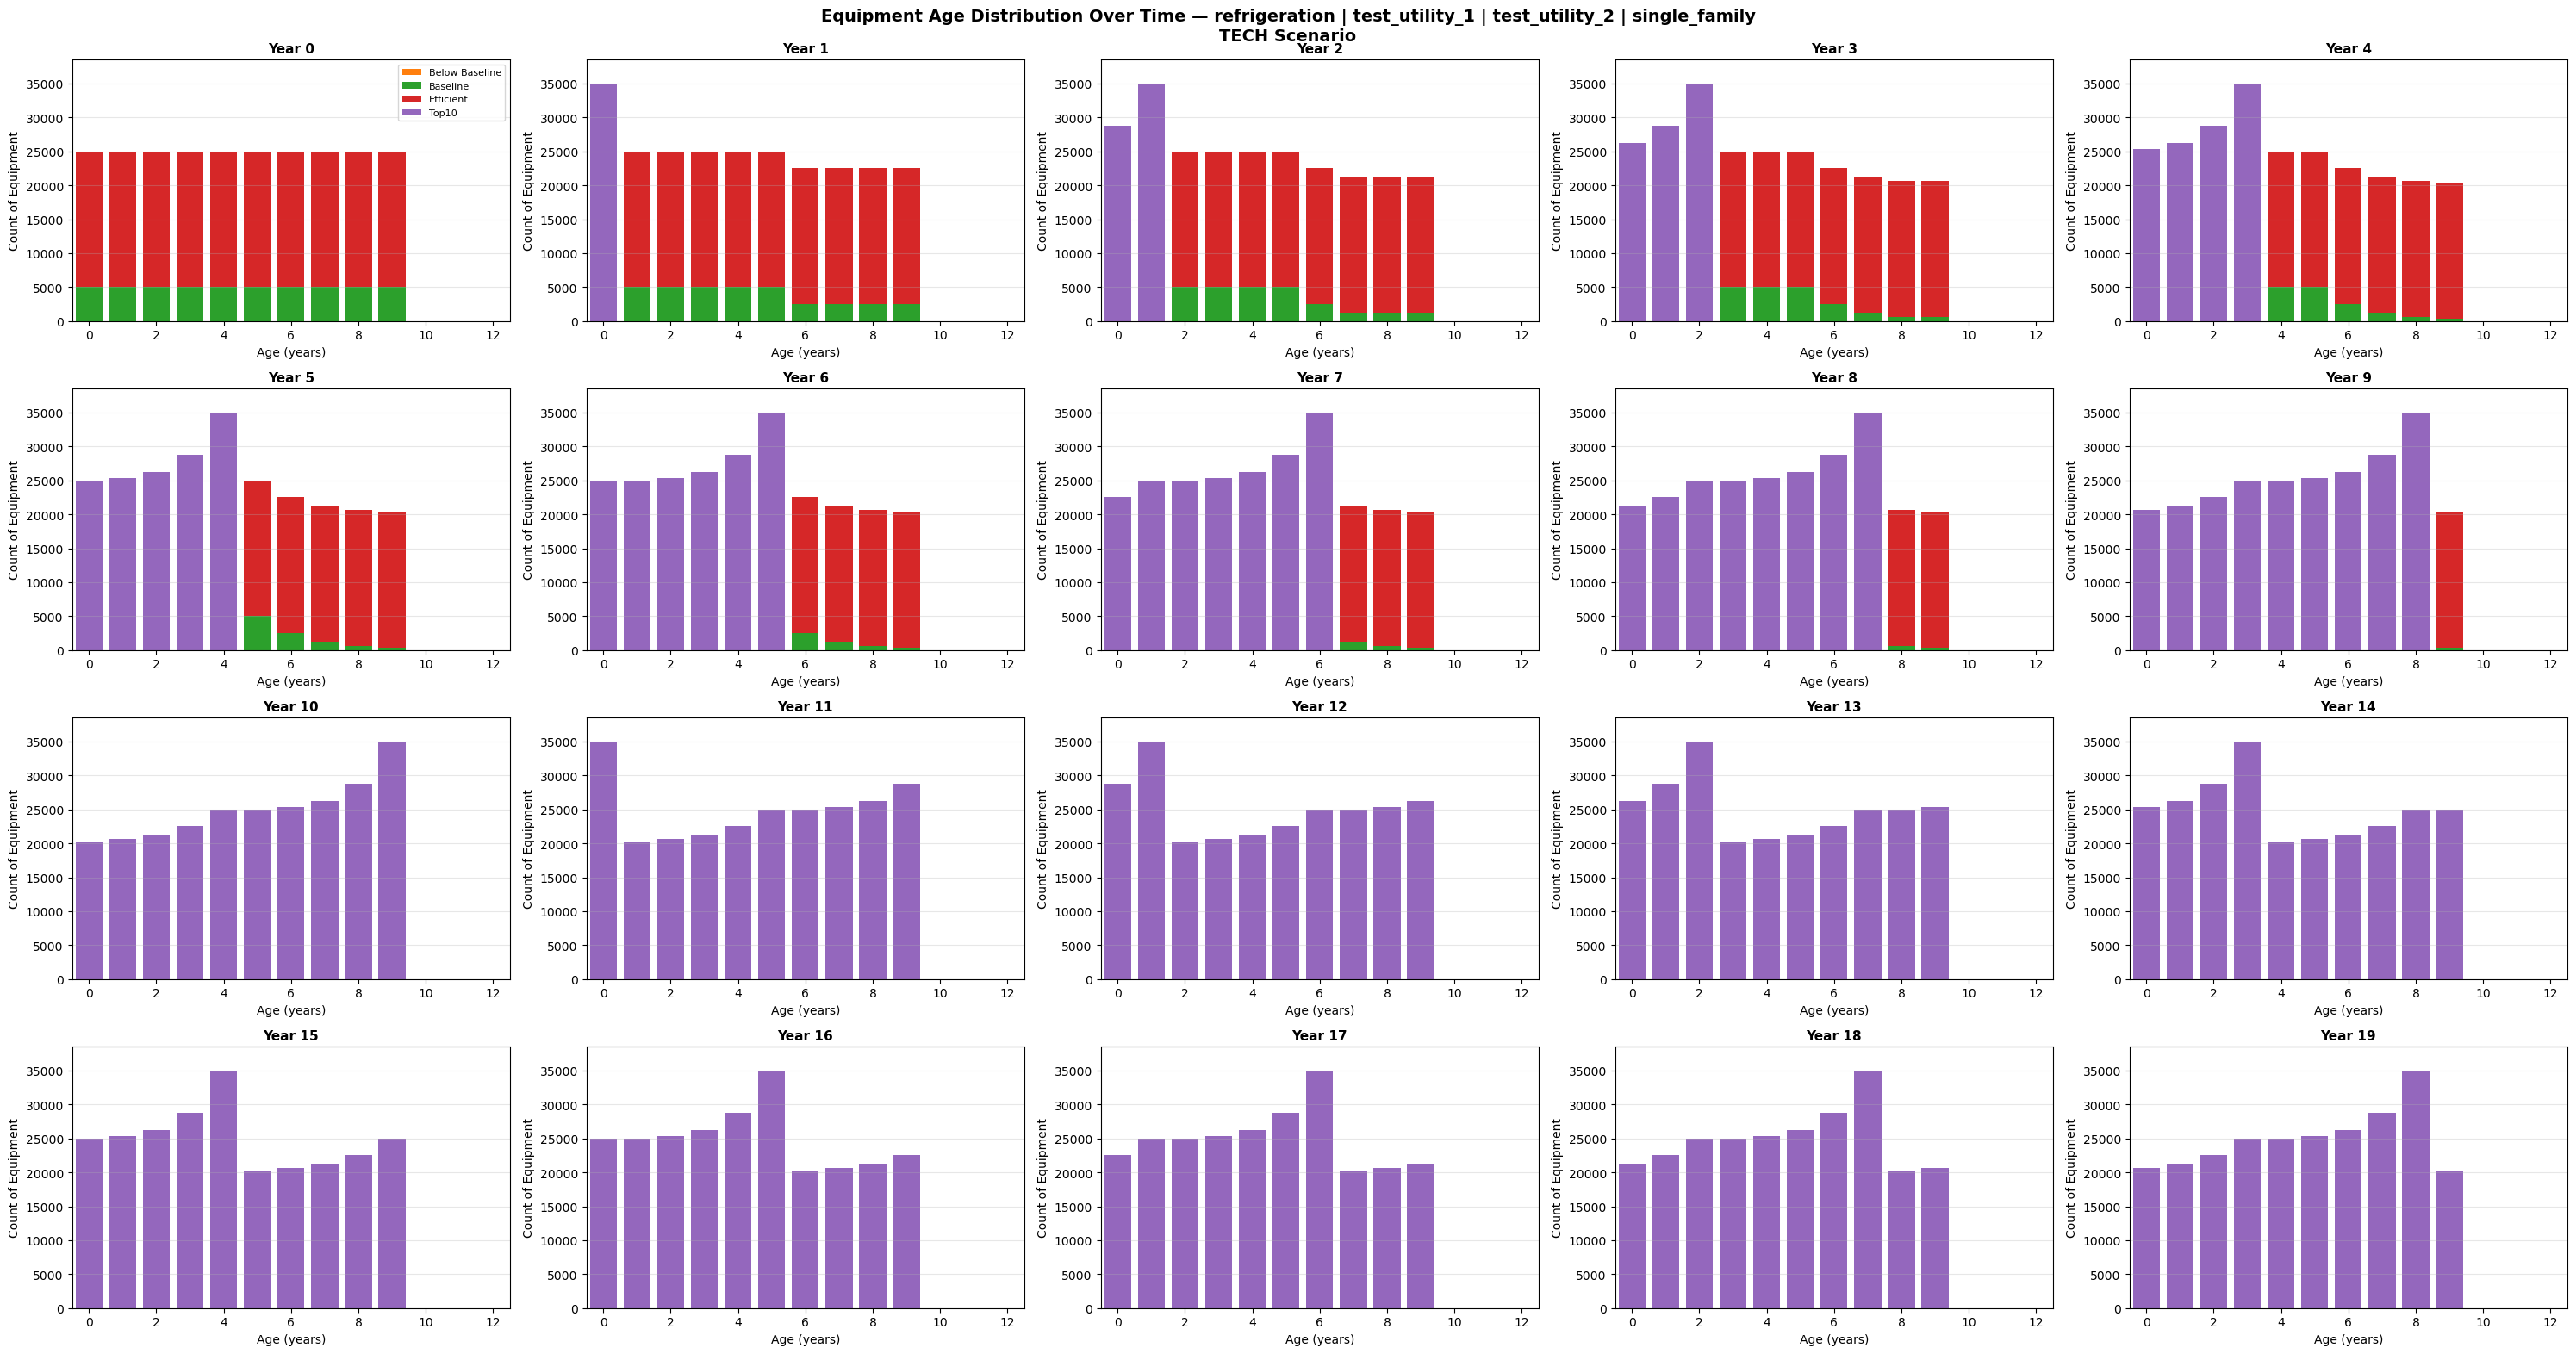

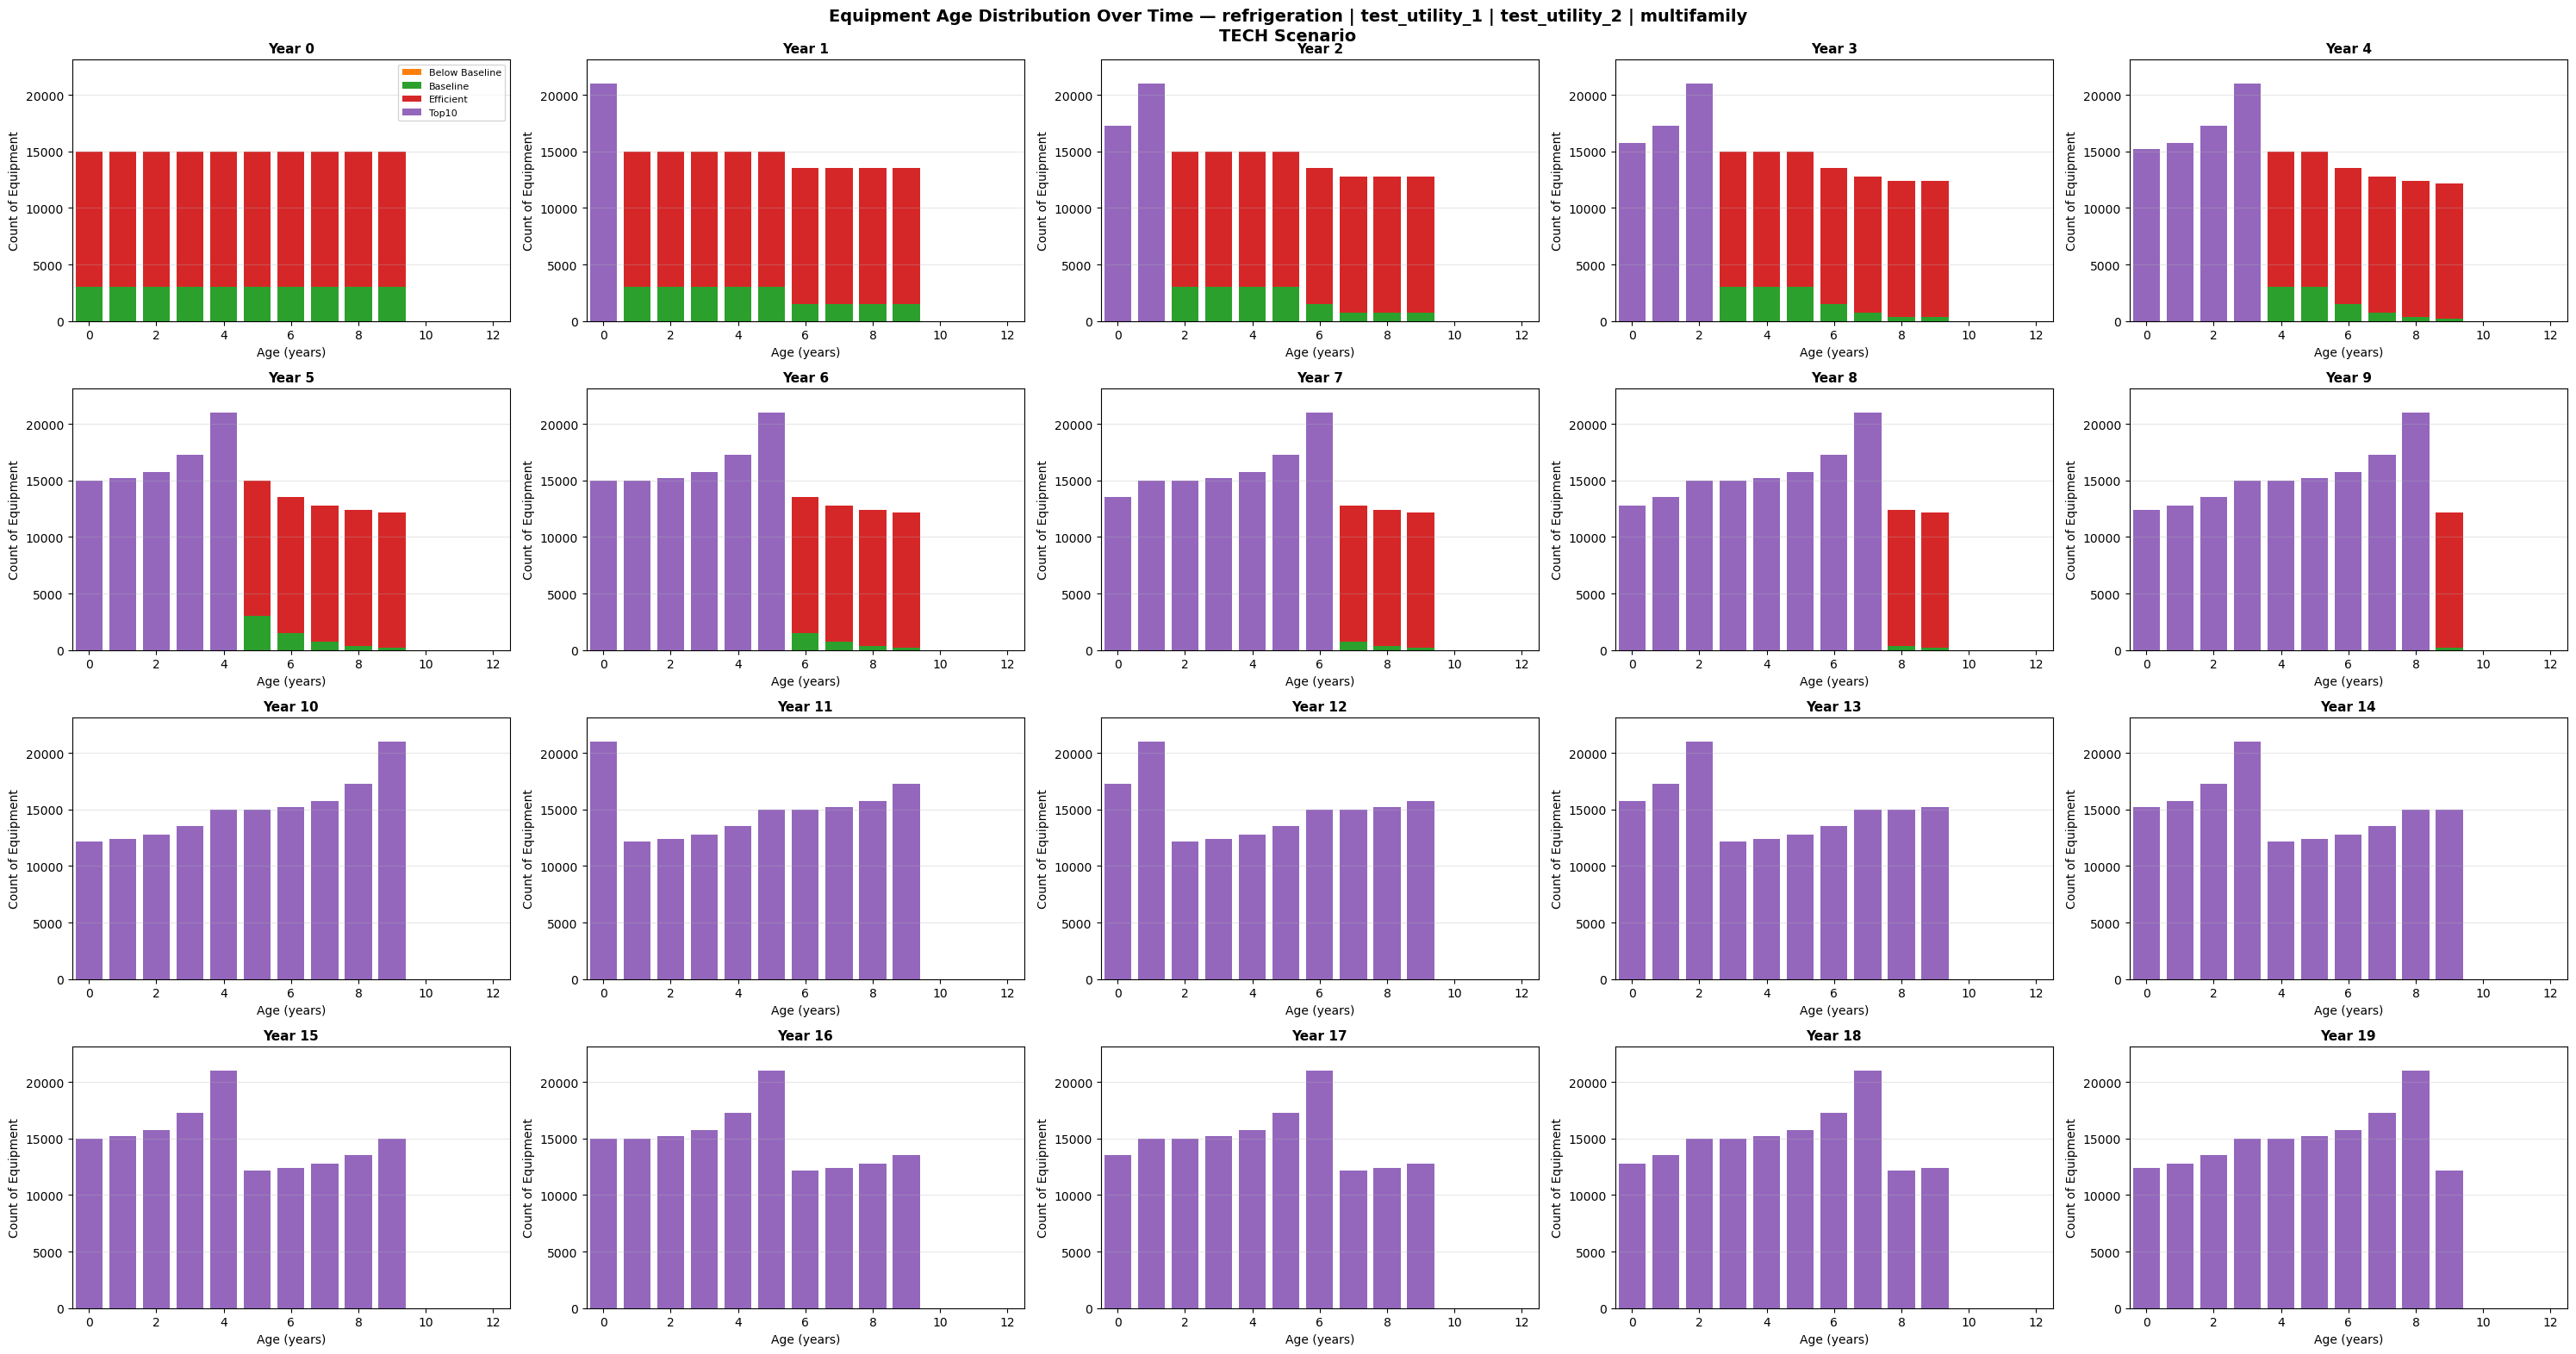

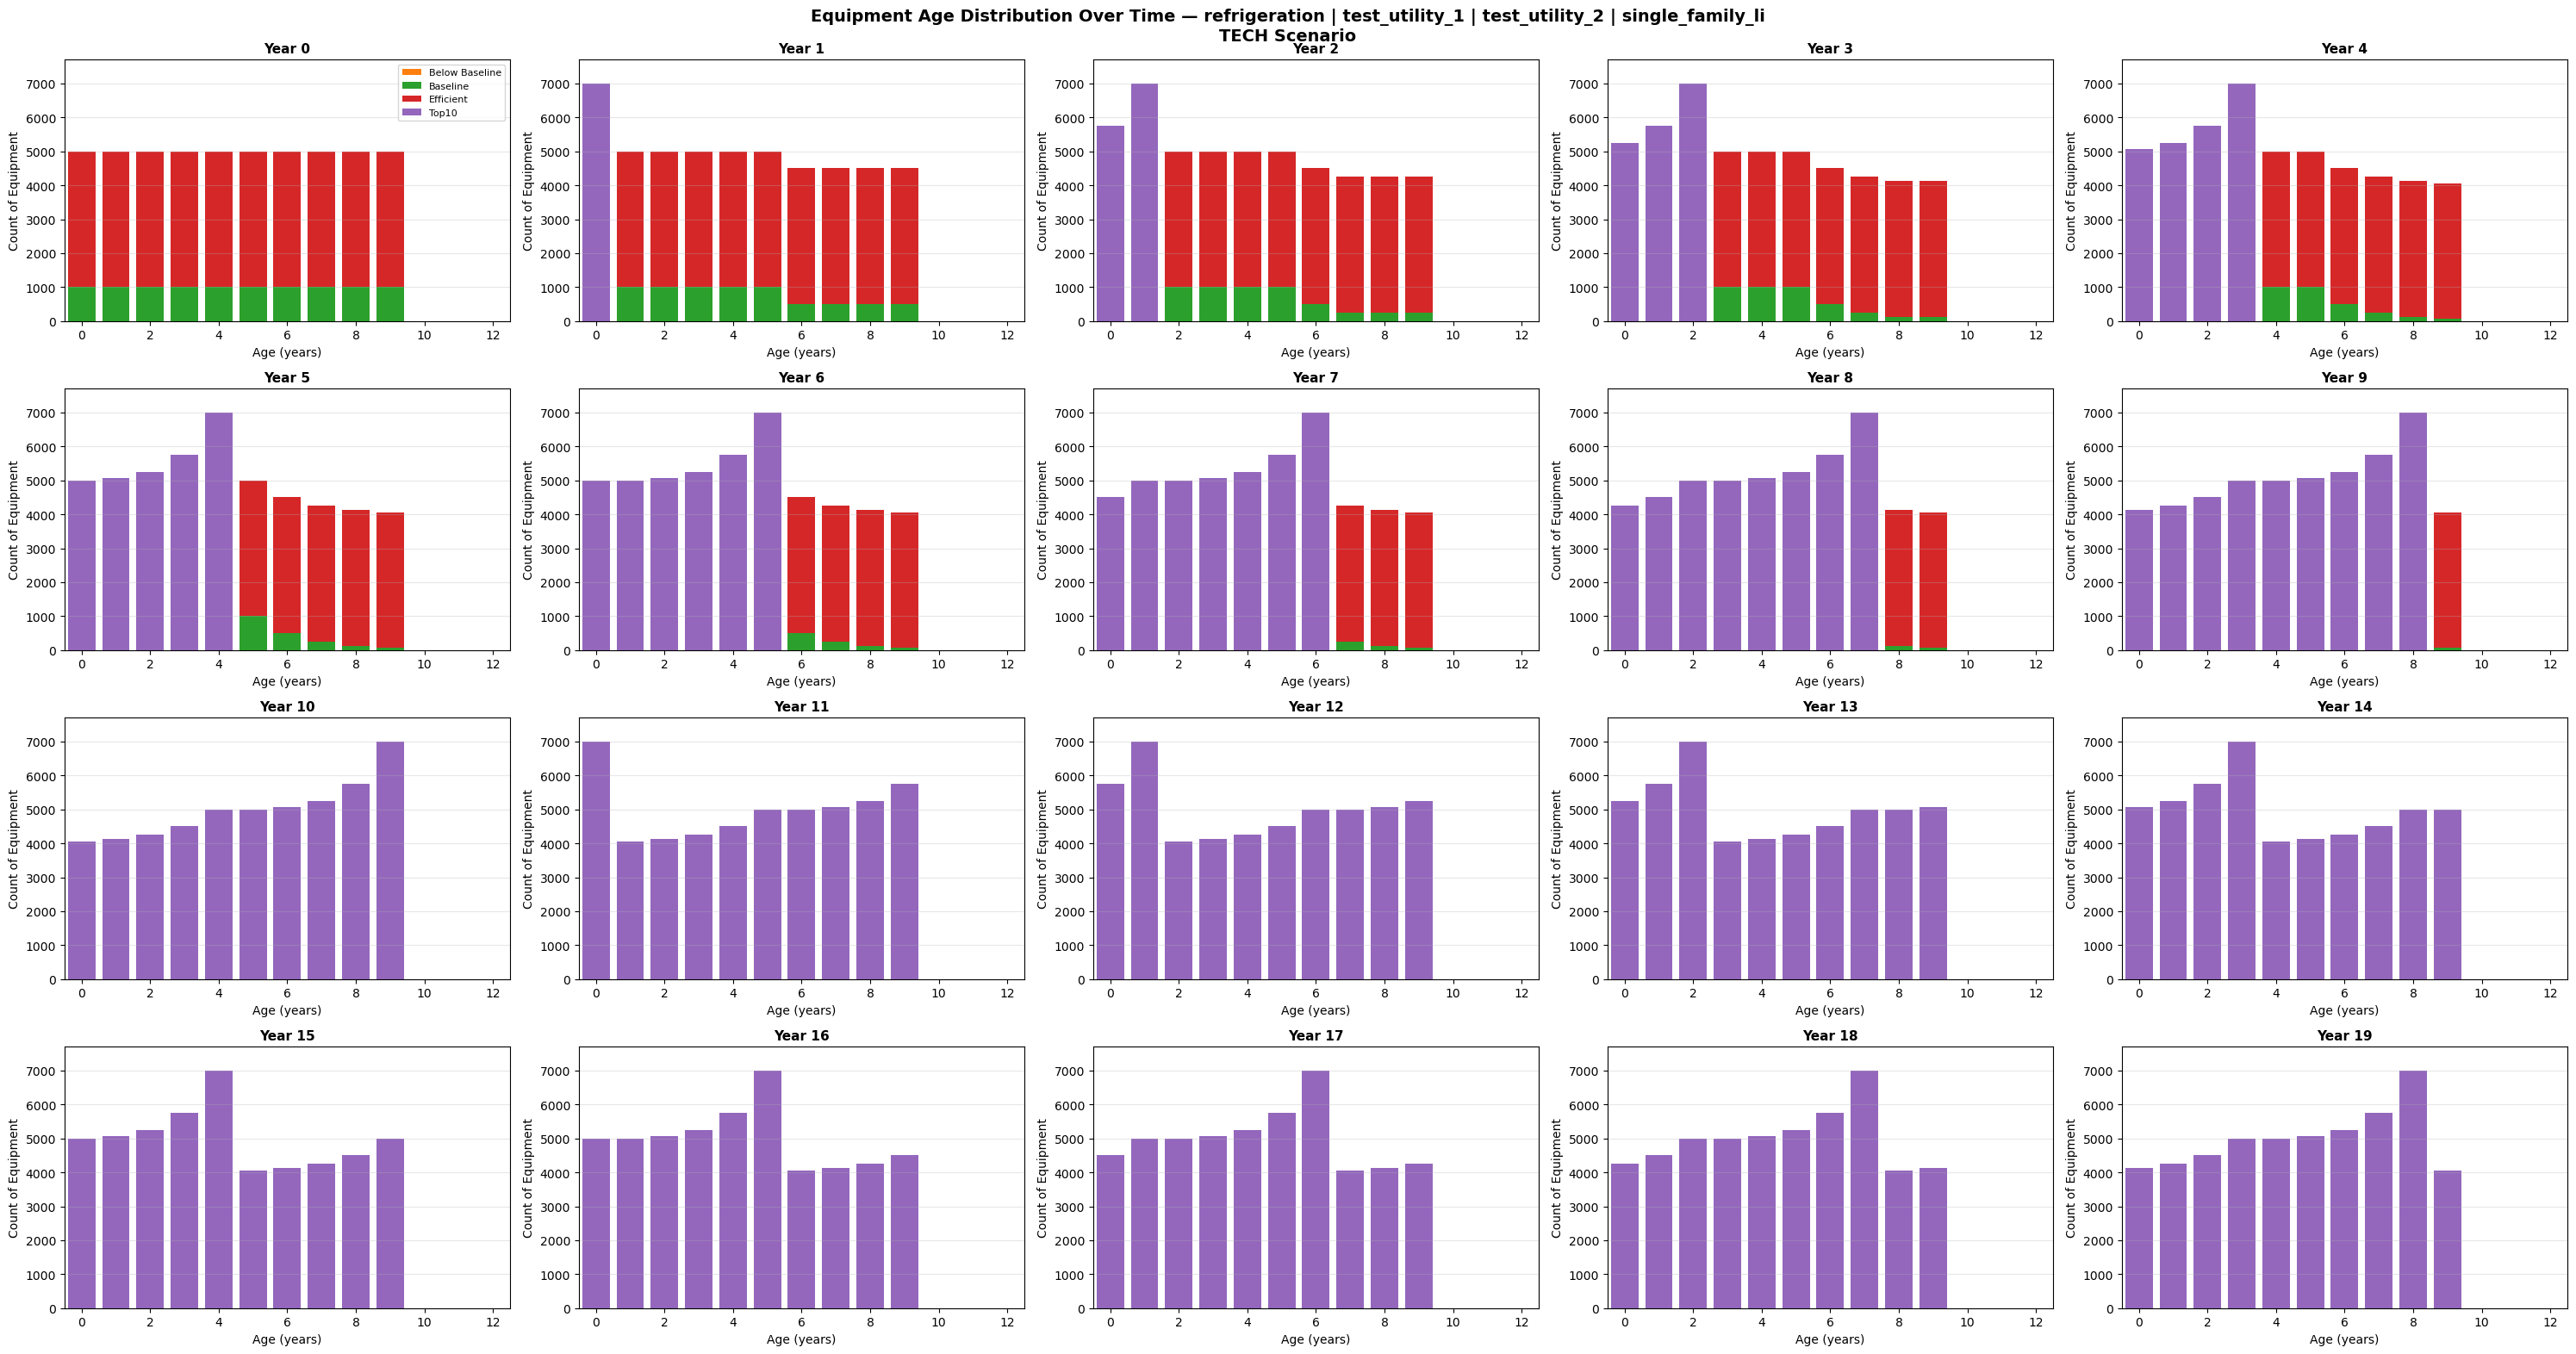

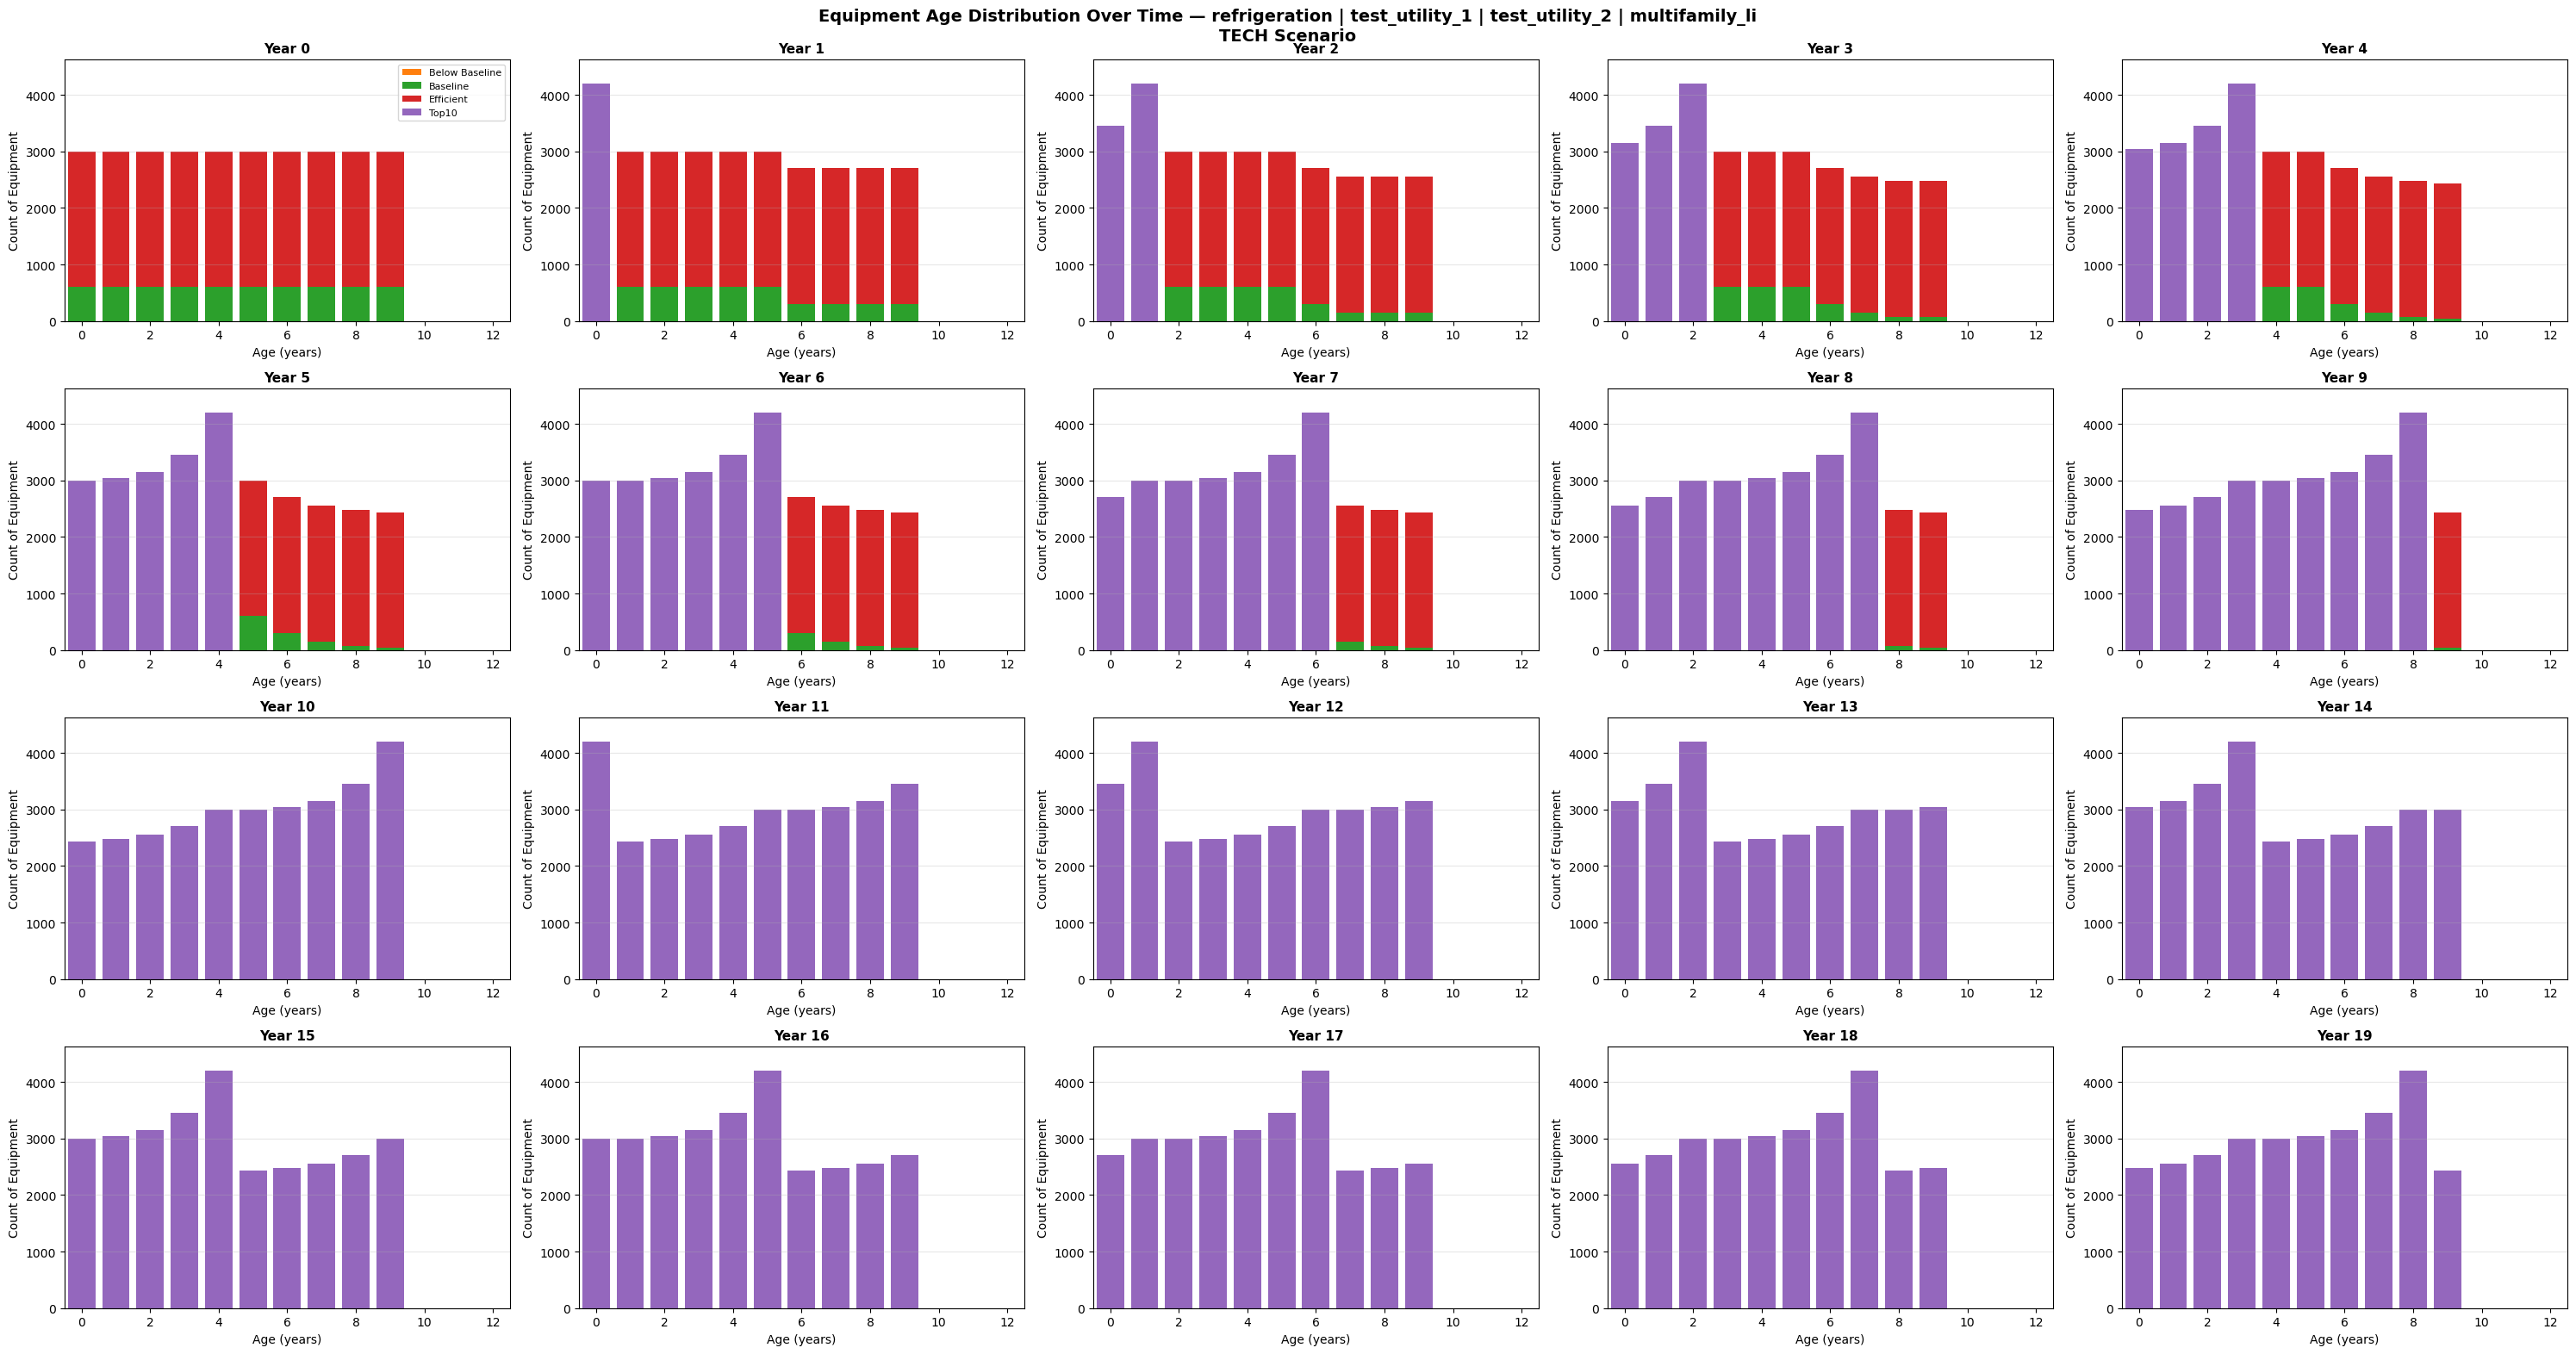

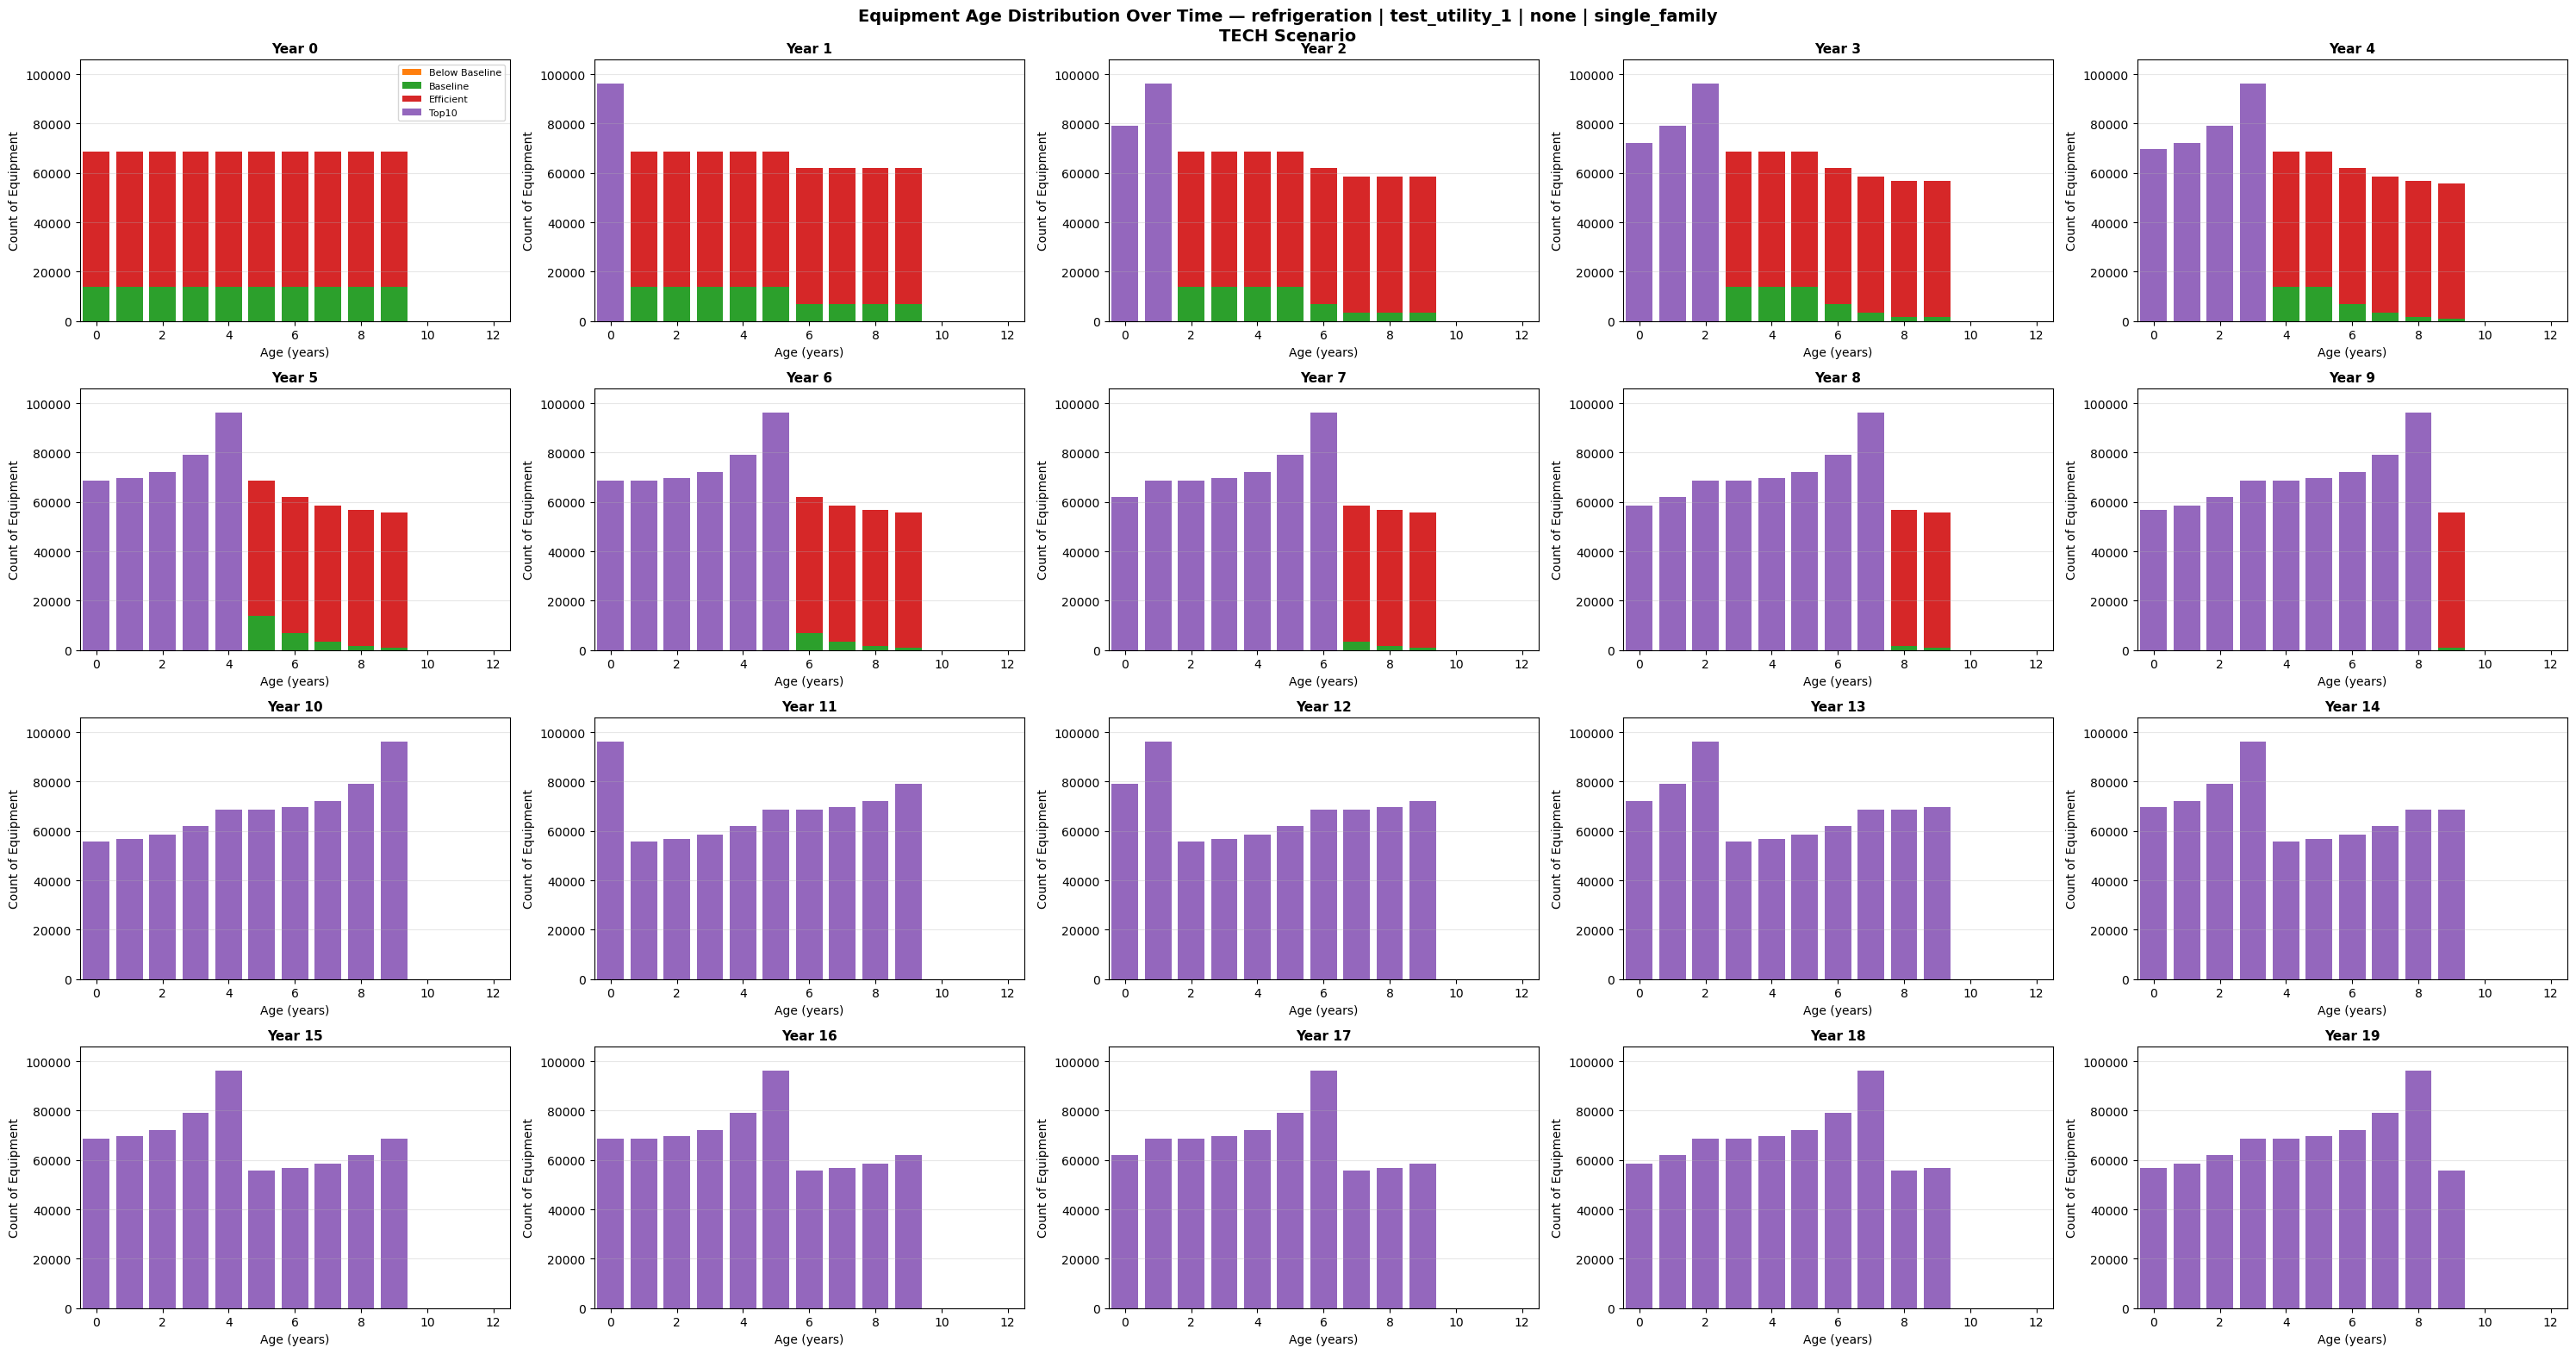

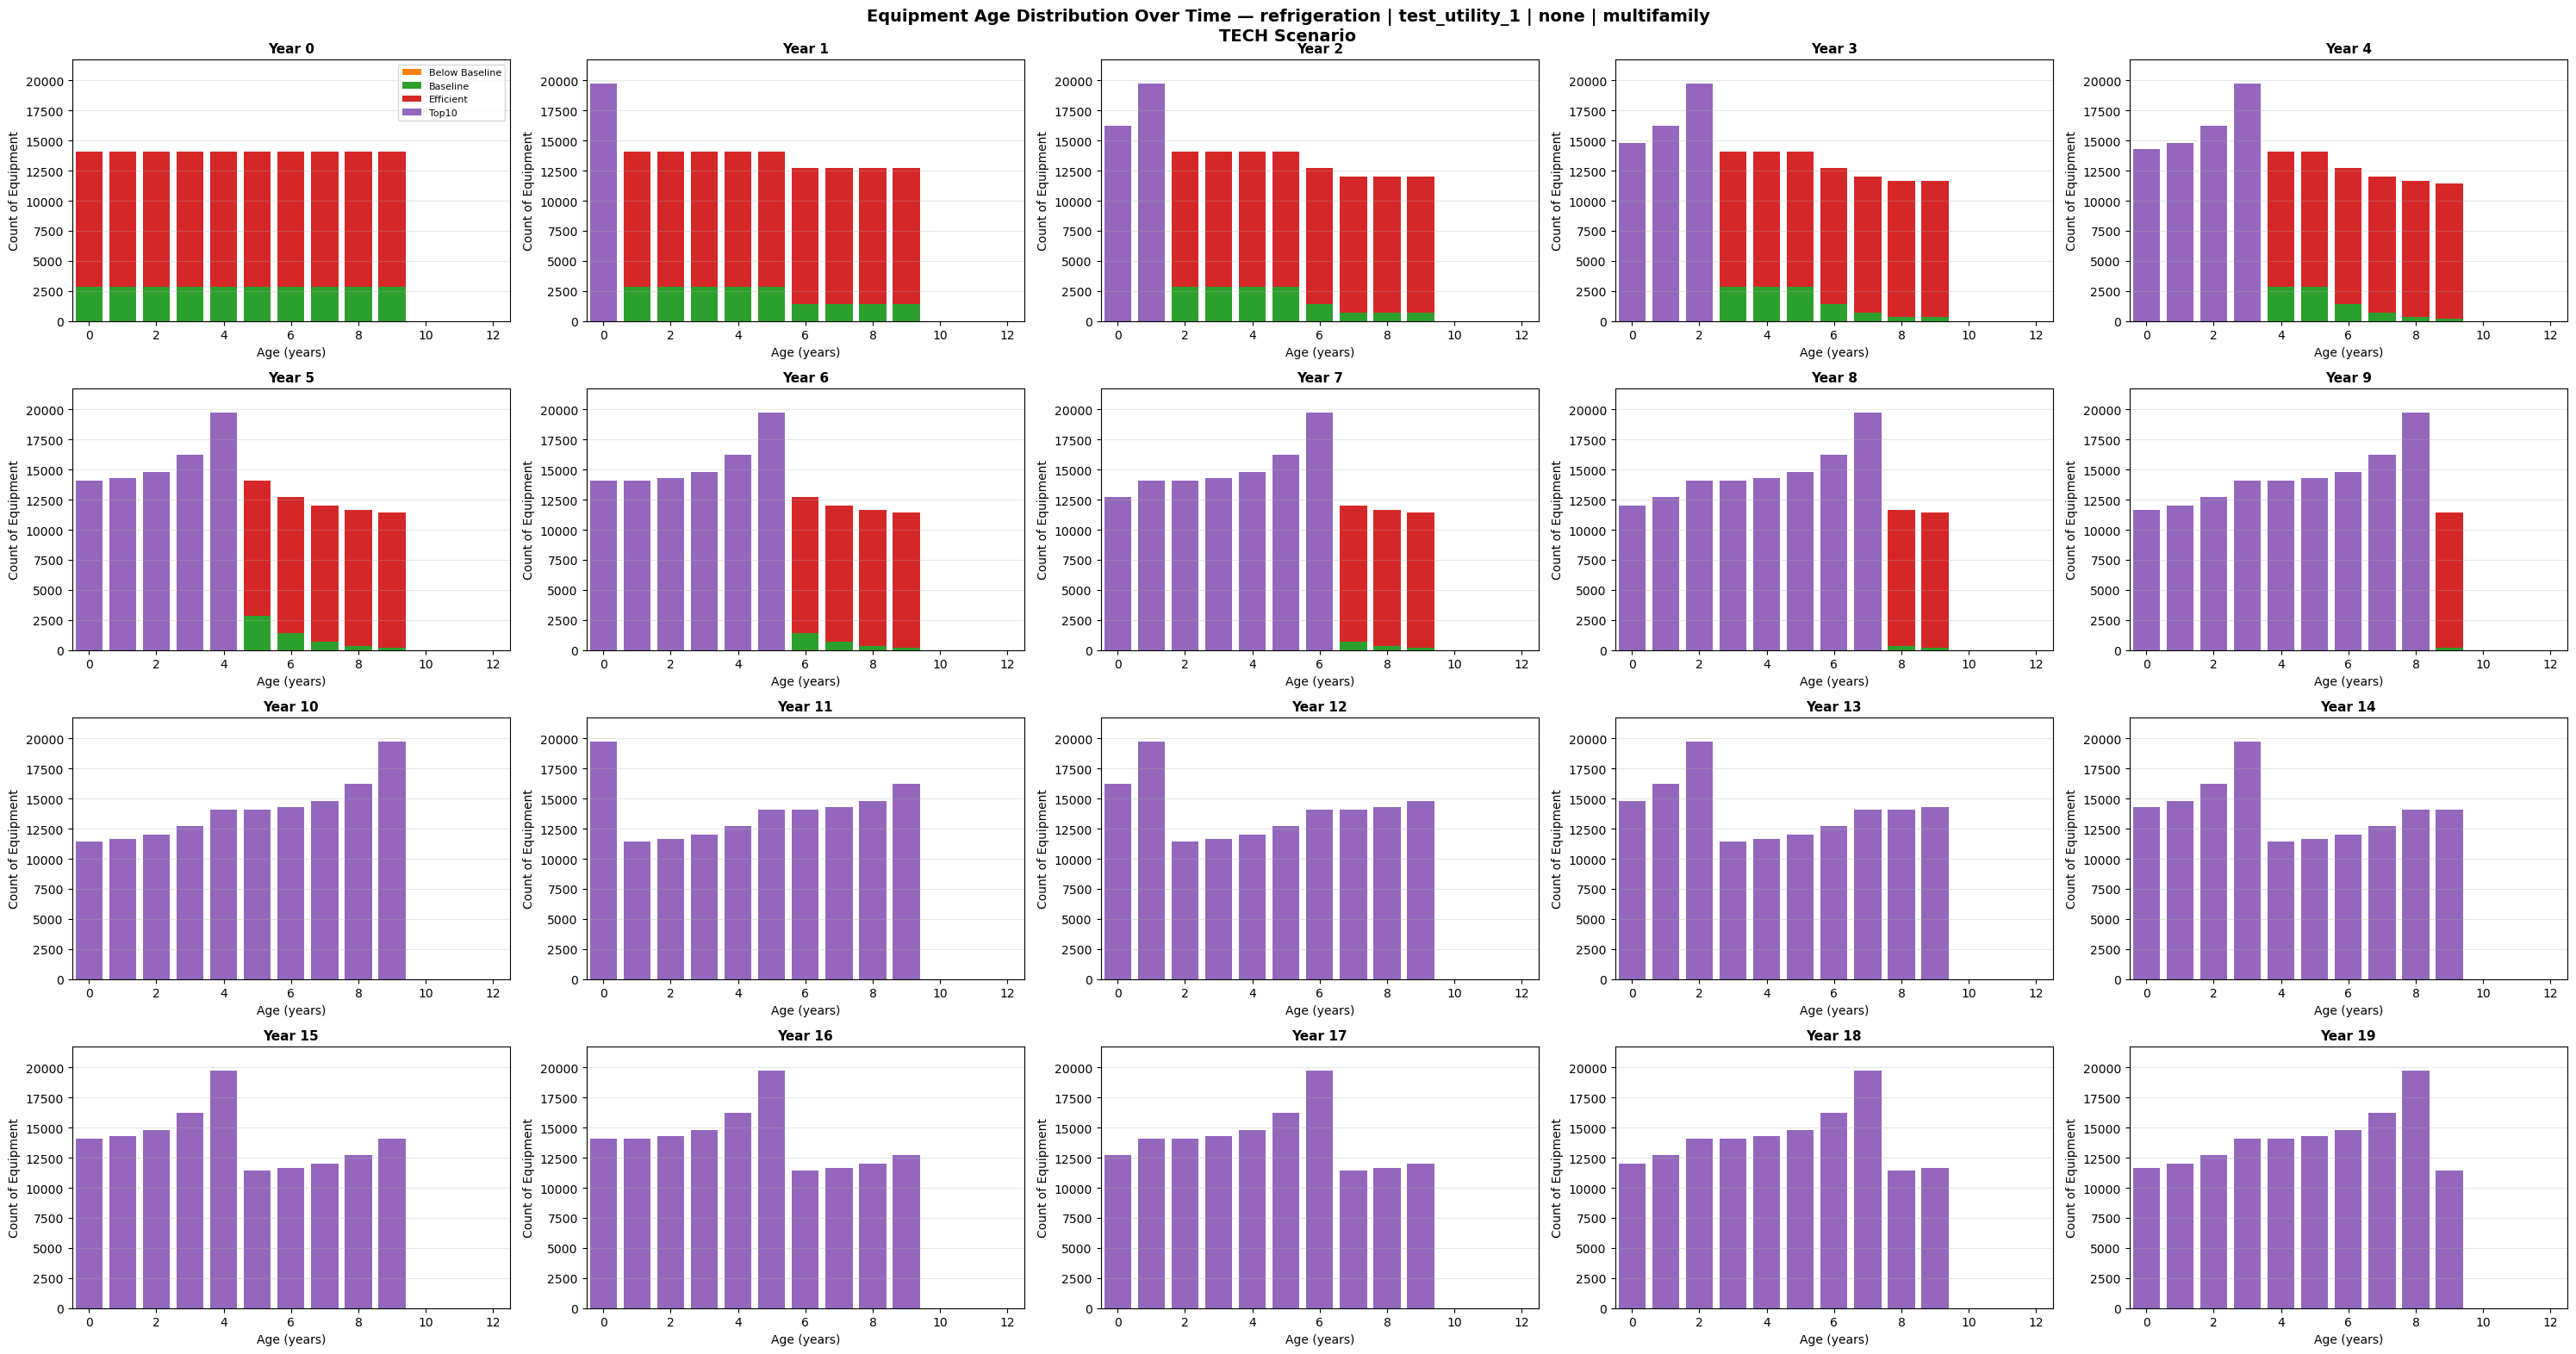

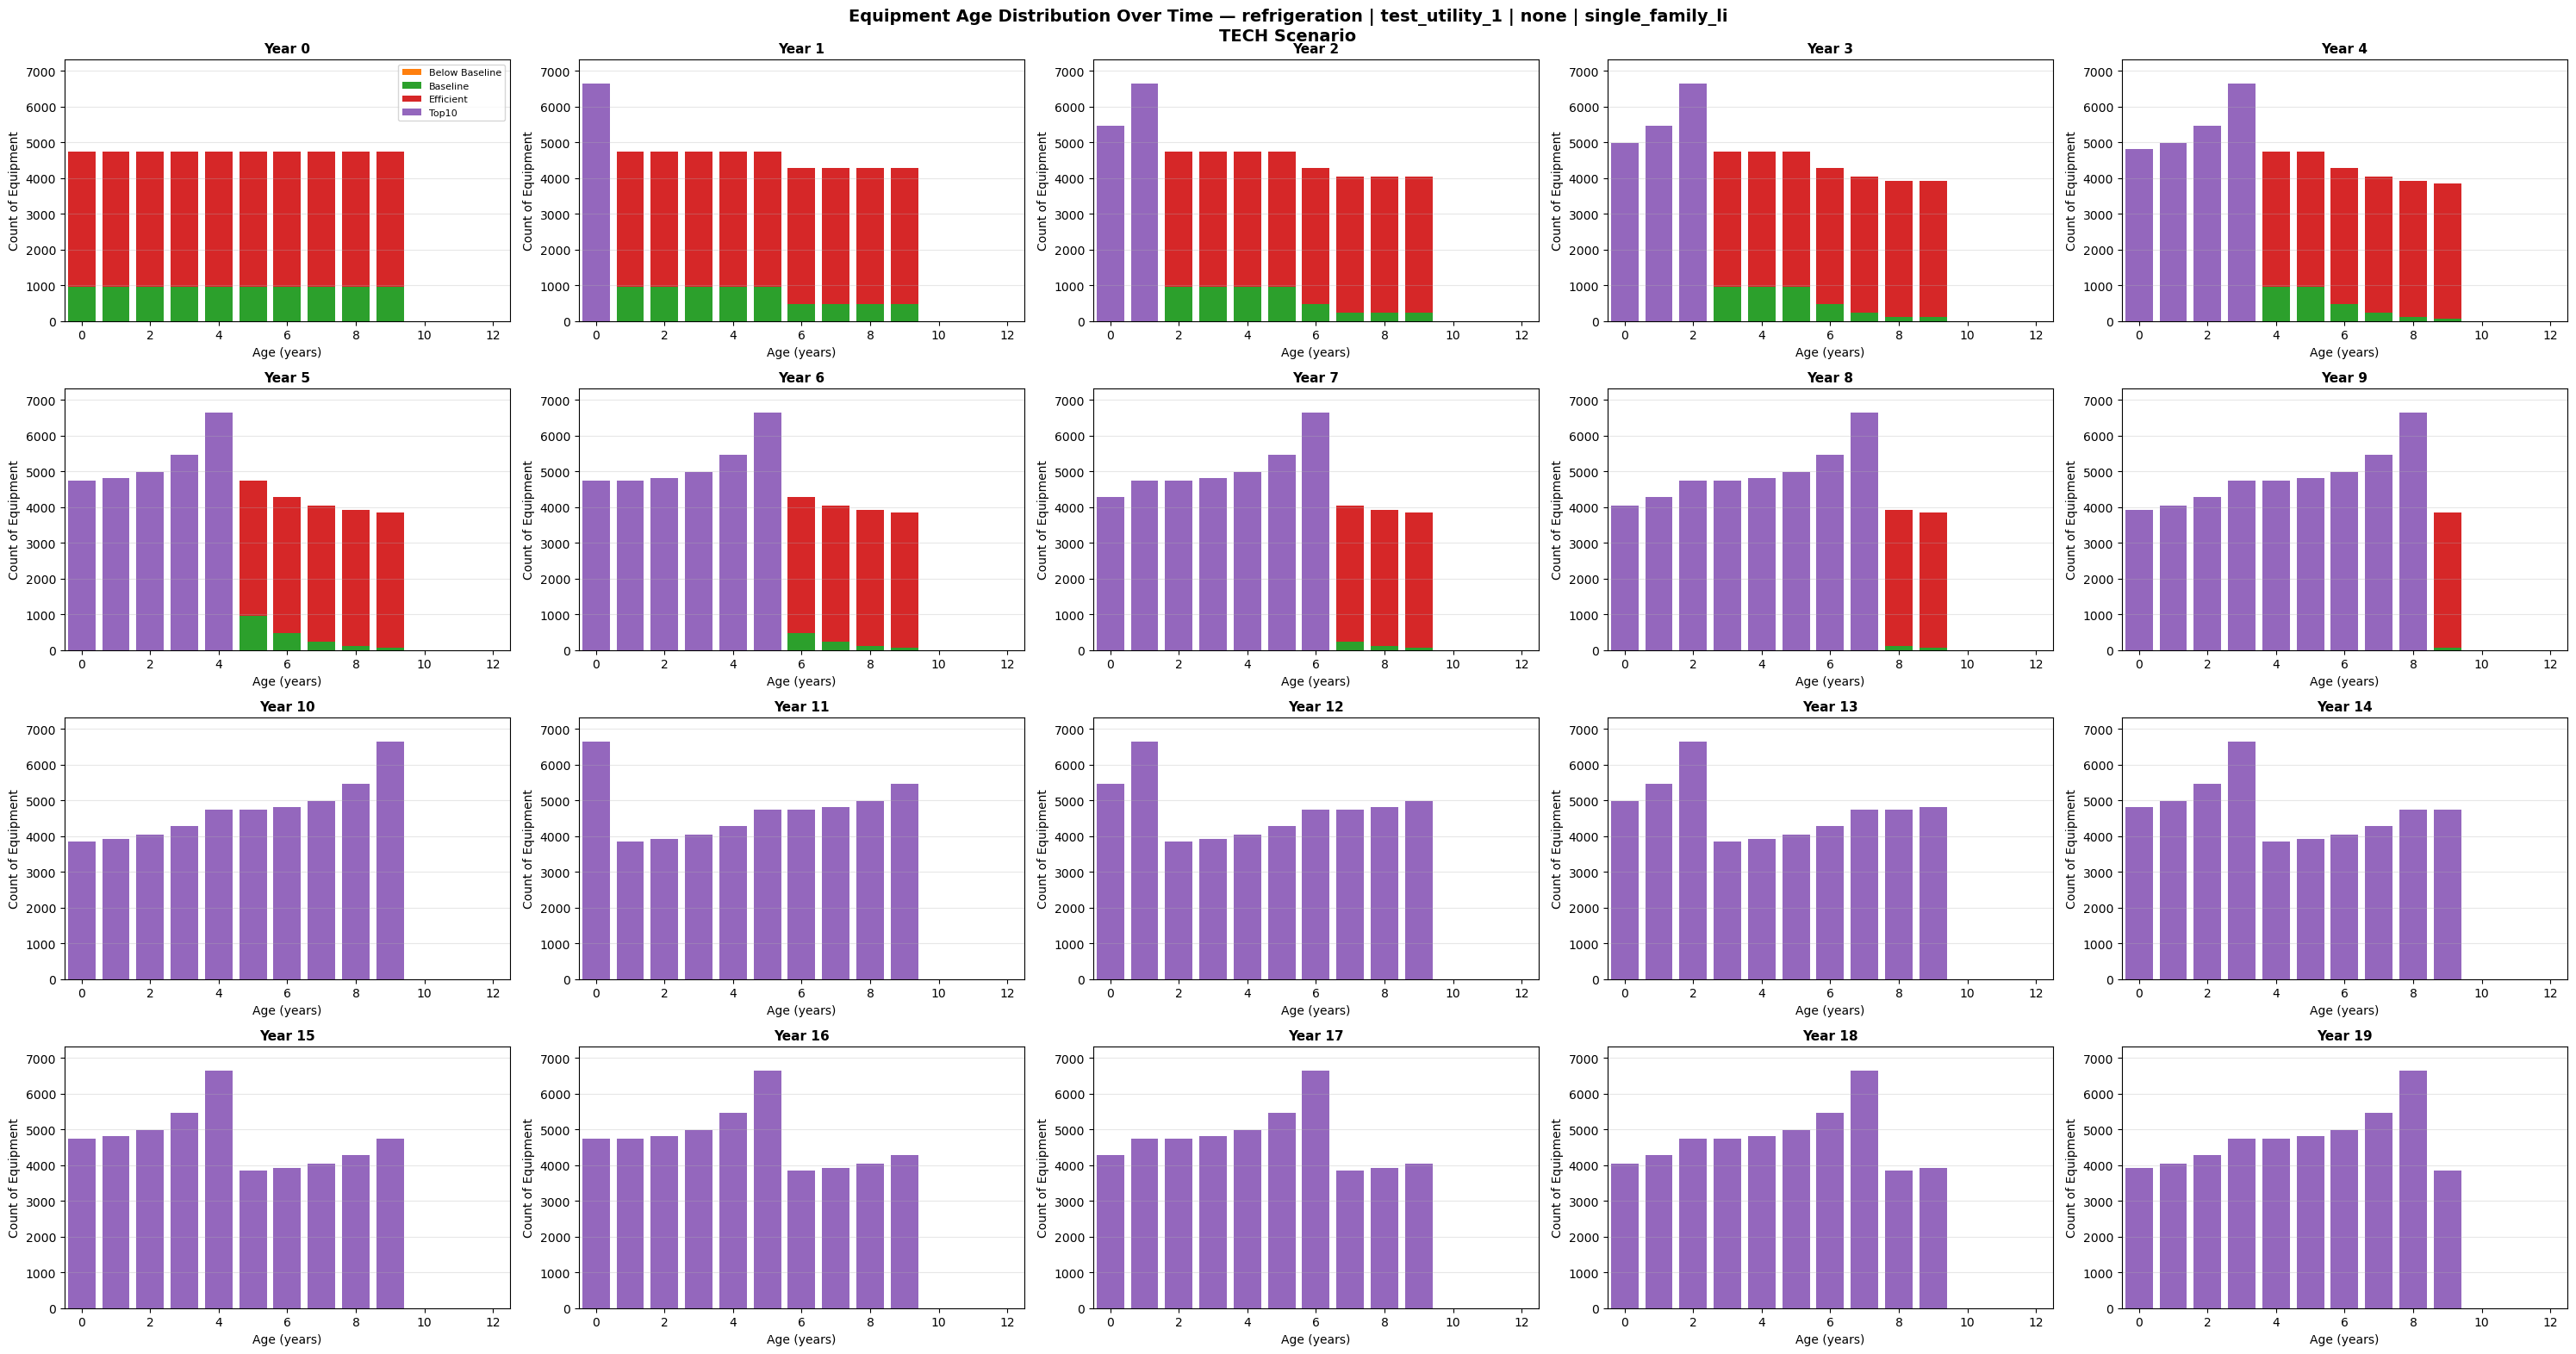

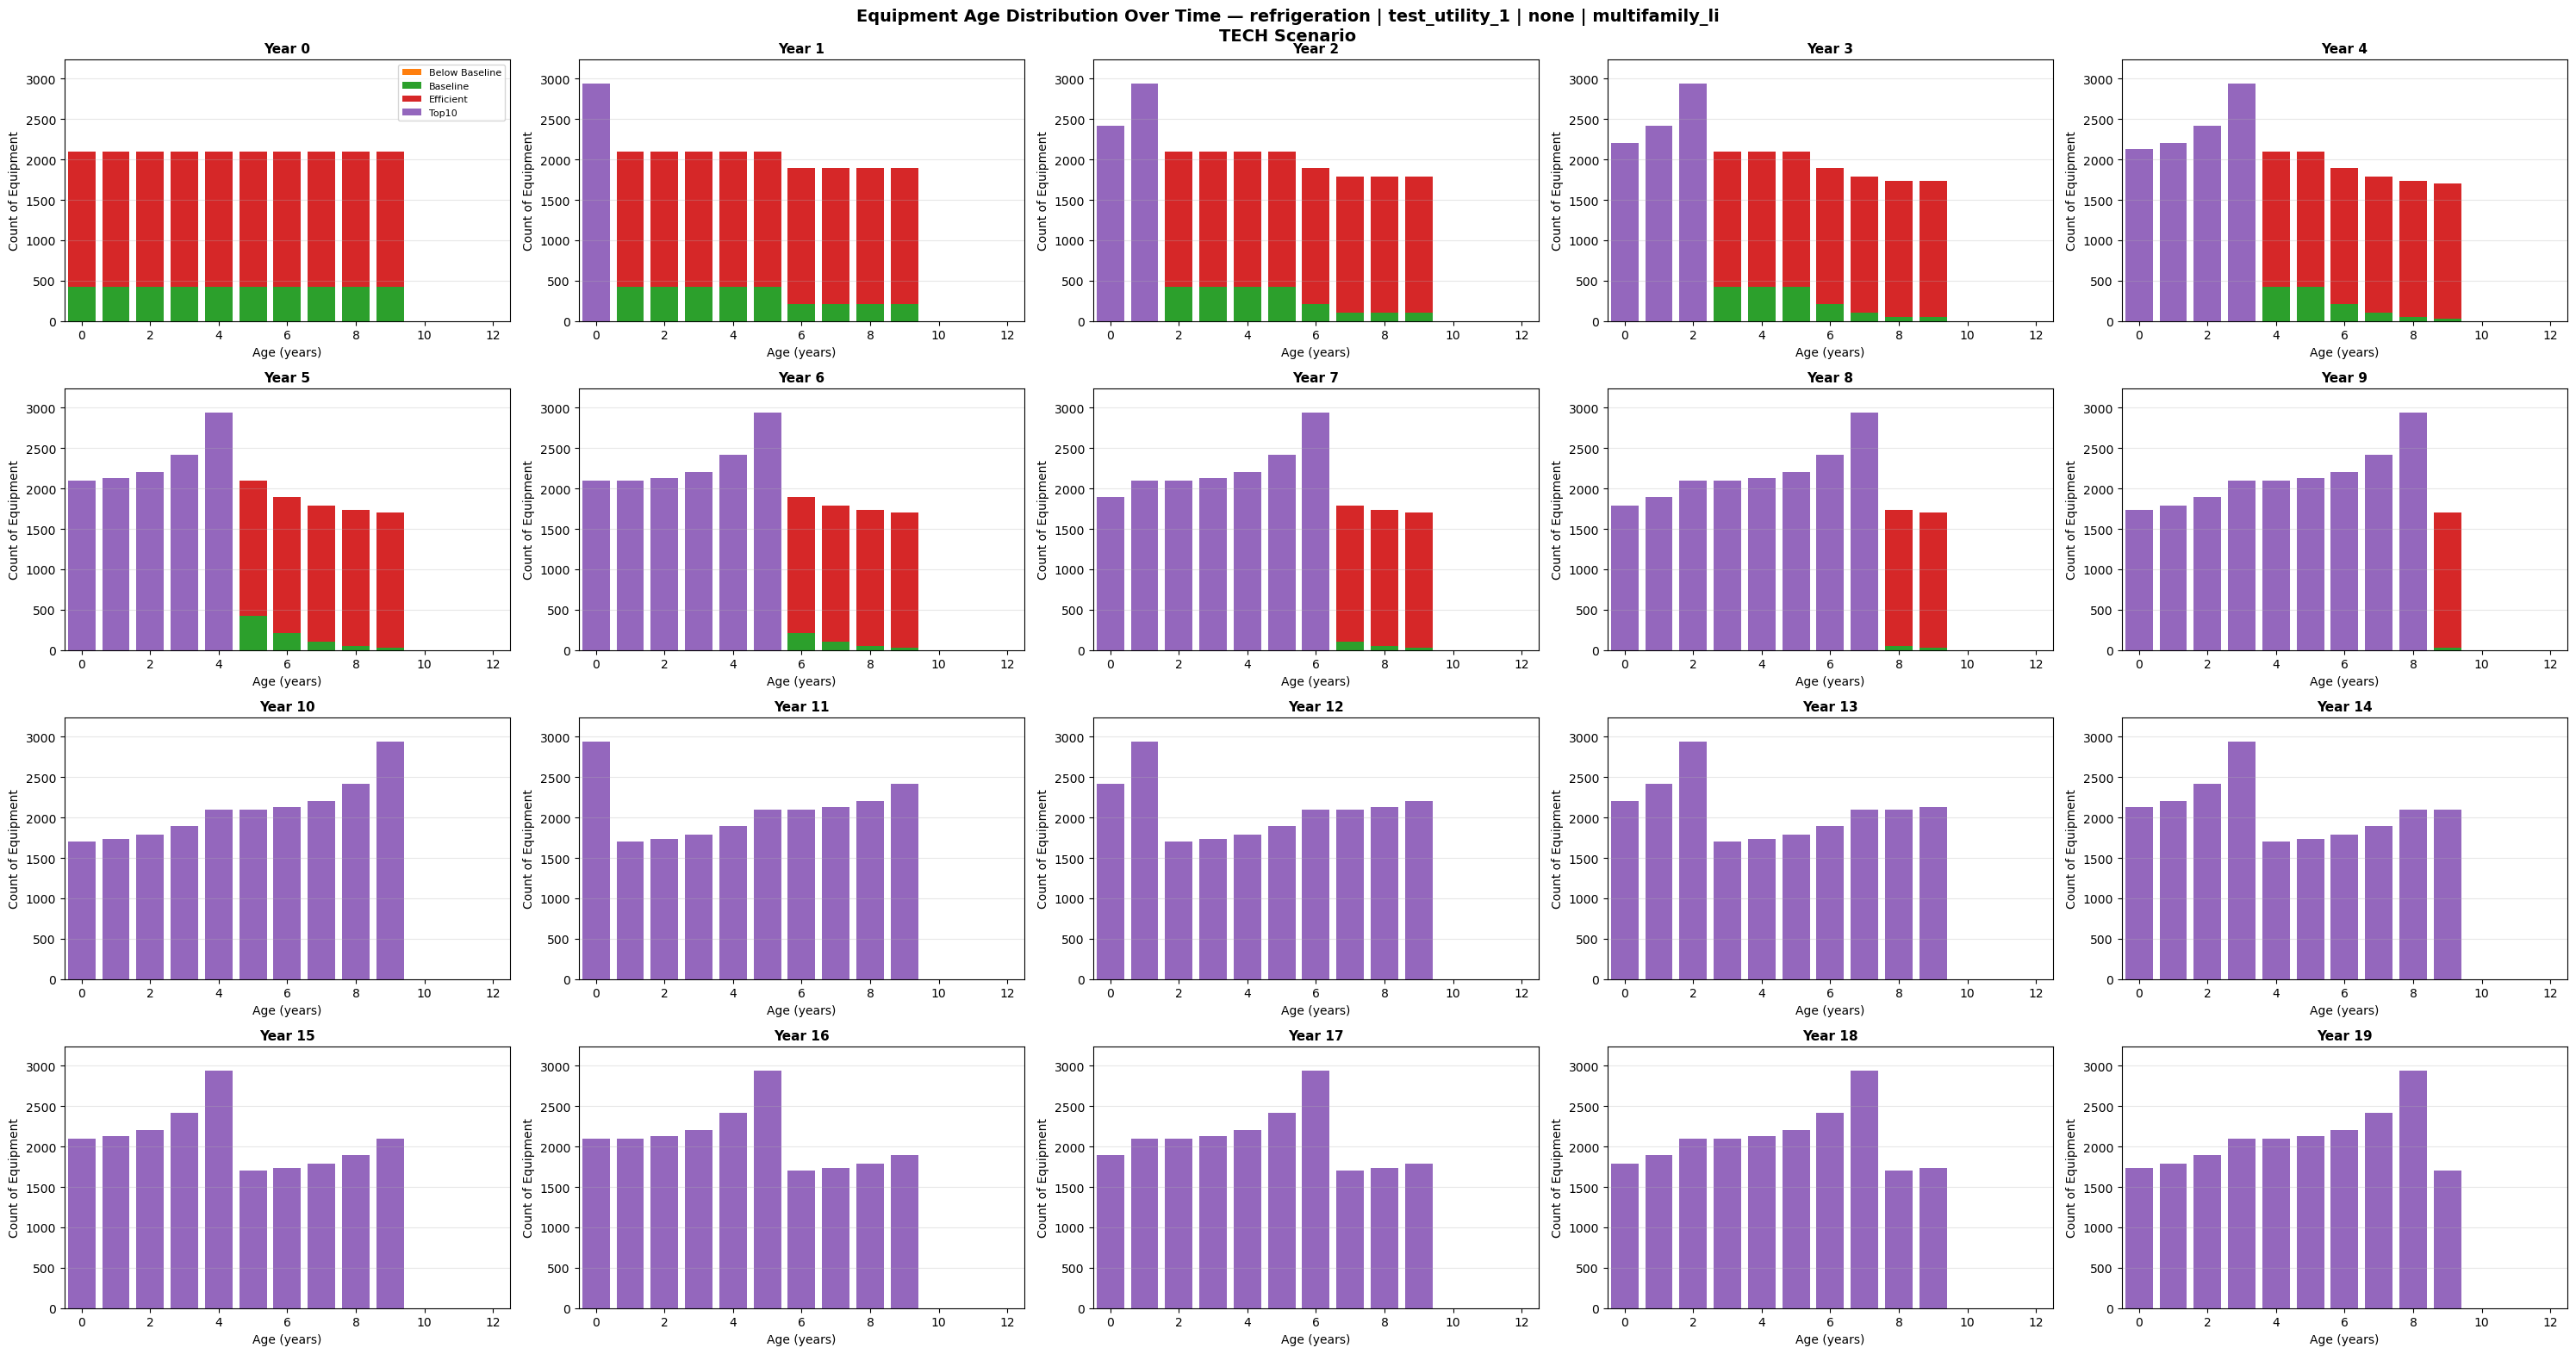

In [16]:
# Age Cohort Visualization by Time
# This function creates visualizations showing equipment distribution by age and efficiency level over time

def plot_age_cohorts_from_stored(scenario_name='tech', max_age_display=30, timesteps_to_plot=None):
    """
    Create stacked bar charts showing equipment age distribution over time using stored data.
    
    Parameters:
    -----------
    scenario_name : str
        Name for the scenario (for titles)
    max_age_display : int
        Maximum age to display on x-axis (default 30)
    timesteps_to_plot : list or None
        List of timesteps (years) to plot. If None, plots all available years (default None)
    """
    
    # Check if age distributions have been stored
    if 'age_distributions_storage' not in globals() or not age_distributions_storage:
        print("Error: No age distributions stored. Run run_adoption_model with store_age_distributions=True first.")
        return
    
    # Iterate through all stored groups
    for group_key, age_distributions in age_distributions_storage.items():
        cg, eu, gu, bt = group_key
        
        # Create visualization
        title_suffix = f"{cg} | {eu} | {gu} | {bt}"
        
        # If no timesteps specified, plot all available years
        if timesteps_to_plot is None:
            timesteps_to_plot = sorted(age_distributions.keys())
        
        num_plots = len(timesteps_to_plot)
        
        # Calculate grid dimensions (prefer roughly square layout)
        ncols = int(np.ceil(np.sqrt(num_plots)))
        nrows = int(np.ceil(num_plots / ncols))
        
        # First pass: calculate y-axis limit based on year 1 (timestep 1)
        max_y_limit = 0
        if 1 in age_distributions:
            year_1_snapshot = age_distributions[1]
            age_data_y1 = {}
            for age in range(max_age_display + 1):
                age_data_y1[age] = {
                    'existing': 0.0,
                    'baseline': 0.0,
                    'efficient': 0.0,
                    'top10': 0.0
                }
            
            for _, row in year_1_snapshot.iterrows():
                age = int(row['current_age'])
                if age <= max_age_display:
                    eff_level = row['efficiency_level']
                    age_data_y1[age][eff_level] += row['count']
            
            # Calculate maximum stacked height for year 1
            for age in range(max_age_display + 1):
                total_at_age = (age_data_y1[age]['existing'] + 
                               age_data_y1[age]['baseline'] + 
                               age_data_y1[age]['efficient'] + 
                               age_data_y1[age]['top10'])
                max_y_limit = max(max_y_limit, total_at_age)
            
            # Add 10% padding to the y-limit
            max_y_limit *= 1.1
        
        # Plot selected timesteps in a grid
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
        fig.suptitle(f"Equipment Age Distribution Over Time — {title_suffix}\n{scenario_name.upper()} Scenario", 
                     fontsize=14, fontweight='bold')
        
        # Flatten axes array for easier indexing
        if num_plots == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for plot_idx, year in enumerate(timesteps_to_plot):
            ax = axes[plot_idx]
            snapshot = age_distributions[year]
            
            # Prepare data: group by age and efficiency level
            age_data = {}
            for age in range(max_age_display + 1):
                age_data[age] = {
                    'existing': 0.0,
                    'baseline': 0.0,
                    'efficient': 0.0,
                    'top10': 0.0
                }
            
            for _, row in snapshot.iterrows():
                age = int(row['current_age'])
                if age <= max_age_display:
                    eff_level = row['efficiency_level']
                    age_data[age][eff_level] += row['count']
            
            # Convert to arrays for plotting
            ages = list(range(max_age_display + 1))
            existing_counts = [age_data[age]['existing'] for age in ages]
            baseline_counts = [age_data[age]['baseline'] for age in ages]
            efficient_counts = [age_data[age]['efficient'] for age in ages]
            top10_counts = [age_data[age]['top10'] for age in ages]
            
            # Create stacked bar chart
            bar_width = 0.8
            ax.bar(ages, existing_counts, bar_width, label='Below Baseline', color='tab:orange')
            ax.bar(ages, baseline_counts, bar_width, bottom=existing_counts, label='Baseline', color='tab:green')
            ax.bar(ages, efficient_counts, bar_width, 
                   bottom=[e+b for e, b in zip(existing_counts, baseline_counts)], 
                   label='Efficient', color='tab:red')
            ax.bar(ages, top10_counts, bar_width,
                   bottom=[e+b+ef for e, b, ef in zip(existing_counts, baseline_counts, efficient_counts)],
                   label='Top10', color='tab:purple')
            
            ax.set_xlabel("Age (years)", fontsize=10)
            ax.set_ylabel("Count of Equipment", fontsize=10)
            ax.set_title(f"Year {year}", fontsize=11, fontweight='bold')
            ax.set_xlim(-0.5, max_age_display + 0.5)
            
            # Set consistent y-axis limit based on year 1
            if max_y_limit > 0:
                ax.set_ylim(0, max_y_limit)
            
            if plot_idx == 0:
                ax.legend(loc='upper right', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
        
        # Hide unused subplots
        for idx in range(num_plots, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

# Run the age cohort visualization using stored data
# Plot all years with consistent y-axis based on year 1
print("Generating age cohort visualizations from stored data...")
plot_age_cohorts_from_stored('tech', max_age_display=12, timesteps_to_plot=None)

In [17]:
# #Archive
# def run_adoption_model(adoption_function, scenario_name='baseline'):
#     """
#     Run the adoption model with age-based tracking.
    
#     Each equipment type is tracked by its actual age. When it reaches its EUL (measure_life_yrs),
#     it goes through the adoption function to determine what replaces it.
    
#     Parameters:
#     -----------
#     adoption_function : callable
#         The function to use for adoption calculations (e.g., baseline_eq, tech_eq, competition_eq)
#     scenario_name : str
#         Name of the scenario for labeling results (default: 'baseline')
    
#     Returns:
#     --------
#     pd.DataFrame
#         Results dataframe with all stock calculations over time
#     """

#     ############## these need to be parameterized based on what is in the Provided Excel file
#     competition_groups = df['competition_group'].unique().tolist()
#     electric_utility = df['electric_utility'].unique().tolist()
#     gas_utility = df['gas_utility'].unique().tolist()
#     building_type = df['building_type'].unique().tolist()
#     #subgroup = df['subgroup'].unique().tolist()  # Uncomment if subgroup is needed

#     results = []

#     for cg in competition_groups:
#         #for sg in subgroup:
#             for eu in electric_utility:
#                 for gu in gas_utility:
#                     for bt in building_type:
#                         # Get dynamic nc, demo, and reno values based on competition group and building type
#                         nc_per_year = get_construction_value(new_construction_inputs_df, cg, bt)
#                         demo_per_year = get_construction_value(demolition_inputs_df, cg, bt)
#                         reno_per_year = get_construction_value(renovation_inputs_df, cg, bt)
                        
#                         # Calculate per-timestep values
#                         nc = nc_per_year * dt
#                         demo = demo_per_year * dt
#                         reno = reno_per_year * dt
                        
#                         df_filtered = df[
#                             (df['competition_group'] == cg) &
#                             #df['subgroup'] == sg) &
#                             (df['electric_utility'] == eu) &
#                             (df['gas_utility'] == gu) &
#                             (df['building_type'] == bt)
#                         ]
                        
#                         if df_filtered.empty:
#                             continue
                        
#                         # --- AGE-BASED TRACKING INITIALIZATION ---
#                         # Create age cohorts for each condition (measure)
#                         # Each row in df_filtered represents a unique measure/condition
#                         # We split the initial count evenly across all years of its EUL
                        
#                         age_cohorts = []
                        
#                         for idx, row in df_filtered.iterrows():
#                             measure_eul = int(row['measure_life_(yrs)'])
#                             initial_count = row['count']
#                             efficiency_level = row['efficiency_level']
#                             condition_name = row['condition_name']
                            
#                             ######## Change here if want different split ############
#                             # Split initial count evenly across all age years (0 to EUL-1)
#                             count_per_age_year = initial_count / measure_eul
                            
#                             # Create a cohort for each age
#                             for age in range(measure_eul):
#                                 age_cohorts.append({
#                                     'condition_name': condition_name,
#                                     'efficiency_level': efficiency_level,
#                                     'eul': measure_eul,
#                                     'current_age': age,
#                                     'count': count_per_age_year,
#                                     'idx_in_df': idx  # Track original row for BCR lookup
#                                 })
                        
#                         # Convert to DataFrame for easier manipulation
#                         age_df = pd.DataFrame(age_cohorts)
                        
#                         # Initialize tracking arrays for aggregated results
#                         total_stock = np.zeros(n)
#                         total_below_baseline_stock = np.zeros(n)
#                         total_baseline_stock = np.zeros(n)
#                         total_efficient_stock = np.zeros(n)
#                         total_top10_stock = np.zeros(n)
                        
#                         # Track flows (adoptions at EUL)
#                         adoption_flow_below_baseline = np.zeros(n)
#                         adoption_flow_baseline = np.zeros(n)
#                         adoption_flow_efficient = np.zeros(n)
#                         adoption_flow_top10 = np.zeros(n)
                        
#                         # Set initial conditions for t=0
#                         total_below_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
#                         total_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
#                         total_efficient_stock[0] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
#                         total_top10_stock[0] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
#                         total_stock[0] = total_below_baseline_stock[0] + total_baseline_stock[0] + total_efficient_stock[0] + total_top10_stock[0]
                        
#                         # --- TIME LOOP: AGE-BASED EVOLUTION ---
#                         for t in range(1, n):
#                             # Step 1: Age all existing cohorts by dt (1 year)
#                             age_df['current_age'] = age_df['current_age'] + dt
                            
#                             # Step 2: Identify cohorts that have reached or exceeded their EUL
#                             retired_cohorts = age_df[age_df['current_age'] >= age_df['eul']].copy()
#                             active_cohorts = age_df[age_df['current_age'] < age_df['eul']].copy()
                            
#                             # Step 3: Apply adoption function to retired cohorts
#                             # Group retired cohorts by efficiency level to calculate total retiring stock
#                             retiring_below_baseline = retired_cohorts[retired_cohorts['efficiency_level'] == 'existing']['count'].sum()
#                             retiring_baseline = retired_cohorts[retired_cohorts['efficiency_level'] == 'baseline']['count'].sum()
#                             retiring_efficient = retired_cohorts[retired_cohorts['efficiency_level'] == 'efficient']['count'].sum()
#                             retiring_top10 = retired_cohorts[retired_cohorts['efficiency_level'] == 'top10']['count'].sum()
#                             total_retiring = retiring_below_baseline + retiring_baseline + retiring_efficient + retiring_top10
                            
#                             # Apply adoption function to determine replacement distribution
#                             if total_retiring > 0:
#                                 # Note: Using retirement_rate = 1.0 since equipment at EUL fully retires
#                                 dBB, dB, dE, dT = adoption_function(
#                                     retiring_below_baseline,
#                                     retiring_baseline,
#                                     retiring_efficient,
#                                     retiring_top10,
#                                     total_retiring,
#                                     1.0,  # Full retirement at EUL
#                                     df_filtered
#                                 )
                                
#                                 # Calculate new equipment distribution after adoption
#                                 # The adoption function returns rates of change, so we integrate over dt
#                                 new_below_baseline = max(retiring_below_baseline + dBB * dt, 0.0)
#                                 new_baseline = max(retiring_baseline + dB * dt, 0.0)
#                                 new_efficient = max(retiring_efficient + dE * dt, 0.0)
#                                 new_top10 = max(retiring_top10 + dT * dt, 0.0)
                                
#                                 # Track adoption flows
#                                 adoption_flow_below_baseline[t] = new_below_baseline
#                                 adoption_flow_baseline[t] = new_baseline
#                                 adoption_flow_efficient[t] = new_efficient
#                                 adoption_flow_top10[t] = new_top10
                                
#                                 # Create new cohorts for each efficiency level with age = 0
#                                 new_cohorts = []
                                
#                                 # For each efficiency level, create new cohorts based on df_filtered measures
#                                 for eff_level, new_count in [('existing', new_below_baseline), 
#                                                                ('baseline', new_baseline), 
#                                                                ('efficient', new_efficient), 
#                                                                ('top10', new_top10)]:
#                                     if new_count > 0:
#                                         # Get measures of this efficiency level from df_filtered
#                                         eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
#                                         if not eff_measures.empty:
#                                             # Distribute new count proportionally to existing measures
#                                             # (or evenly if no proportional data available)
#                                             num_measures = len(eff_measures)
#                                             count_per_measure = new_count / num_measures
                                            
#                                             for idx, row in eff_measures.iterrows():
#                                                 new_cohorts.append({
#                                                     'condition_name': row['condition_name'],
#                                                     'efficiency_level': eff_level,
#                                                     'eul': int(row['measure_life_(yrs)']),
#                                                     'current_age': 0,
#                                                     'count': count_per_measure,
#                                                     'idx_in_df': idx
#                                                 })
                                
#                                 # Add new cohorts to active cohorts
#                                 if new_cohorts:
#                                     new_cohorts_df = pd.DataFrame(new_cohorts)
#                                     active_cohorts = pd.concat([active_cohorts, new_cohorts_df], ignore_index=True)
                            
#                             # Step 4: Handle new construction, demolition, and renovation
#                             if nc > 0:
#                                 # Distribute new construction across efficiency levels
#                                 # Assume 1/3 baseline, 1/3 efficient, 1/3 top10 for new construction
#                                 nc_cohorts = []
#                                 for eff_level, proportion in [('baseline', 1/3), ('efficient', 1/3), ('top10', 1/3)]:
#                                     eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
#                                     if not eff_measures.empty:
#                                         num_measures = len(eff_measures)
#                                         count_per_measure = (nc * proportion) / num_measures
#                                         for idx, row in eff_measures.iterrows():
#                                             nc_cohorts.append({
#                                                 'condition_name': row['condition_name'],
#                                                 'efficiency_level': eff_level,
#                                                 'eul': int(row['measure_life_(yrs)']),
#                                                 'current_age': 0,
#                                                 'count': count_per_measure,
#                                                 'idx_in_df': idx
#                                             })
#                                 if nc_cohorts:
#                                     nc_df = pd.DataFrame(nc_cohorts)
#                                     active_cohorts = pd.concat([active_cohorts, nc_df], ignore_index=True)
                            
#                             # Handle demolition (remove proportionally from all cohorts)
#                             if demo > 0 and not active_cohorts.empty:
#                                 total_active = active_cohorts['count'].sum()
#                                 if total_active > 0:
#                                     demo_fraction = min(demo / total_active, 1.0)
#                                     active_cohorts['count'] = active_cohorts['count'] * (1 - demo_fraction)
                            
#                             # Handle renovation (upgrade equipment to top10, reset age)
#                             if reno > 0 and not active_cohorts.empty:
#                                 total_active = active_cohorts['count'].sum()
#                                 if total_active > 0:
#                                     reno_fraction = min(reno / total_active, 1.0)
#                                     # Remove reno_fraction from all cohorts and add to top10
#                                     reno_count = active_cohorts['count'].sum() * reno_fraction
#                                     active_cohorts['count'] = active_cohorts['count'] * (1 - reno_fraction)
                                    
#                                     # Add renovated equipment as new top10 cohorts
#                                     top10_measures = df_filtered[df_filtered['efficiency_level'] == 'top10']
#                                     if not top10_measures.empty:
#                                         num_measures = len(top10_measures)
#                                         count_per_measure = reno_count / num_measures
#                                         reno_cohorts = []
#                                         for idx, row in top10_measures.iterrows():
#                                             reno_cohorts.append({
#                                                 'condition_name': row['condition_name'],
#                                                 'efficiency_level': 'top10',
#                                                 'eul': int(row['measure_life_(yrs)']),
#                                                 'current_age': 0,
#                                                 'count': count_per_measure,
#                                                 'idx_in_df': idx
#                                             })
#                                         if reno_cohorts:
#                                             reno_df = pd.DataFrame(reno_cohorts)
#                                             active_cohorts = pd.concat([active_cohorts, reno_df], ignore_index=True)
                            
#                             # Step 5: Update age_df for next iteration
#                             age_df = active_cohorts.copy()
                            
#                             # Step 6: Calculate aggregate stocks for this timestep
#                             total_below_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
#                             total_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
#                             total_efficient_stock[t] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
#                             total_top10_stock[t] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
#                             total_stock[t] = total_below_baseline_stock[t] + total_baseline_stock[t] + total_efficient_stock[t] + total_top10_stock[t]
                        
#                         # Append results for each time step
#                         for t in range(n):
#                             results.append({
#                                 'competition_group': cg,
#                                 #'subgroup': sg,
#                                 'electric_utility': eu,
#                                 'gas_utility': gu,
#                                 'building_type': bt,
#                                 'time': t * dt,
#                                 'total_stock': total_stock[t],
#                                 'total_below_baseline_stock': total_below_baseline_stock[t],
#                                 'total_baseline_stock': total_baseline_stock[t],
#                                 'total_efficient_stock': total_efficient_stock[t],
#                                 'total_top10_stock': total_top10_stock[t],
#                                 'adoption_flow_below_baseline': adoption_flow_below_baseline[t],
#                                 'adoption_flow_baseline': adoption_flow_baseline[t],
#                                 'adoption_flow_efficient': adoption_flow_efficient[t],
#                                 'adoption_flow_top10': adoption_flow_top10[t]
#                             })

#     return pd.DataFrame(results)